# Pozyskanie danych

## Instalacja i import niezbędnych bibliotek

In [ ]:
!pip install cdsapi

In [ ]:
pip install xarray netcdf4 zarr dask matplotlib cartopy pandas numpy scipy xclim pymannkendall statsmodels scikit-learn xgboost shap seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.0/379.0 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 126.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.8/306.8 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 5.4 MB/s eta 0:00:00


In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.lines as mlines

## Tworzenie requestów do pobrania danych

In [ ]:
import cdsapi

dataset = "reanalysis-era5-single-levels"
c = cdsapi.Client(url="https://cds.climate.copernicus.eu/api",
                        key="f85a23bc-7b23-4cea-92fa-ec62fa5810fc")

variables = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_dewpoint_temperature",
    "2m_temperature",
    "mean_sea_level_pressure",
    "total_precipitation",
    "snow_depth",
    "total_column_water_vapour"
]

hours = ["00:00", "06:00", "12:00", "18:00"]

for year in range(2000, 2025 + 1):
    print(f"Pobieranie roku {year}...")

    request = {
        "product_type": ["reanalysis"],
        "variable": variables,
        "year": str(year),
        "month": ["{:02d}".format(m) for m in range(1, 13)],
        "day": ["{:02d}".format(d) for d in range(1, 32)],
        "time": hours,
        "data_format": "netcdf",
        "download_format": "unarchived",
        "area": [49.7, 20.7, 49.6, 20.8],  # Nowy Sącz (box 0.1°x0.1°)
    }

    c.retrieve(
        dataset,
        request).download()


ModuleNotFoundError: No module named 'cdsapi'

## Scalenie wszystkich pobranych plików


Z uwagi na ograniczenia dane pobrano dla jednego oczka gridu, dla każdego dnia, miesiąca i godziny. Zakres roczny pobranych danych to 2000-2025. Dla każdego roku dane pobierano osobno, dlatego trzeba było je scalić w jeden plik. Dodatkowo dla każdego roku pobrano po cztery pliki, każdy zawierający dane dla innych zakresów godzinowych.

Scalenie wykonano lokalnie w folderze, w kórym zgromadzono pobrane dane, wykonując skrypt merge.py


In [ ]:
# import xarray as xr
# from pathlib import Path

# base_dir = Path(r"C:/IiAD/uczenie_maszynowe/klimat_projekt/all_data")

# datasets = []

# for folder in sorted(base_dir.iterdir()):
#     if not folder.is_dir():
#         continue

#     # Wyszukiwanie plików
#     instant_files = list(folder.glob("data_stream-oper_stepType-instant.nc"))
#     accum_files   = list(folder.glob("data_stream-oper_stepType-accum.nc"))

#     # Jeśli brakuje któregoś pliku → pomijamy folder
#     if not instant_files or not accum_files:
#         print(f"⚠️ W folderze {folder.name} nie znaleziono wymaganych plików — pomijam.")
#         continue

#     instant_file = instant_files[0]
#     accum_file   = accum_files[0]

#     # Wczytanie
#     ds_instant = xr.open_dataset(instant_file, chunks={"valid_time": 365})
#     ds_accum   = xr.open_dataset(accum_file,   chunks={"valid_time": 365})

#     # Ujednolicenie nazw czasu (czasem w accum może być 'time')
#     if "time" in ds_instant:
#         ds_instant = ds_instant.rename({"time": "valid_time"})
#     if "time" in ds_accum:
#         ds_accum = ds_accum.rename({"time": "valid_time"})

#     # Usuwamy expver
#     if "expver" in ds_instant.variables:
#         ds_instant = ds_instant.drop_vars("expver")
#     if "expver" in ds_accum.variables:
#         ds_accum = ds_accum.drop_vars("expver")

#     # Łączenie zmiennych z tego samego roku
#     ds_year = xr.merge([ds_instant, ds_accum], compat="override")
#     datasets.append(ds_year)


# # Sklejenie datasetów po czasie
# ds_all = xr.concat(datasets, dim="valid_time")

# # Posortowanie dat (ważne)
# ds_all = ds_all.sortby("valid_time")

# # Zapis do jednego pliku
# output_file = base_dir / "era5_nowy_sacz_all_years.nc"
# ds_all.to_netcdf(output_file)

# print(f"\nGOTOWE! Dane zapisane do pliku:\n   {output_file}")


# Wczytanie i przygotowanie danych

## Otwarcie połączonego pliku

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path

# wczytanie danych
dataset = "era5_nowy_sacz_all_years.nc"
ds = xr.open_dataset(dataset)
print(ds)

print("Dims:", ds.dims)
print("Coords:", list(ds.coords))
print("Vars:", list(ds.data_vars))

# sprawdzenie braków danych we wszystkich zmiennych
ds.isnull().sum()




<xarray.Dataset> Size: 9MB
Dimensions:     (valid_time: 227398, latitude: 1, longitude: 1)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2MB 2000-01-01 ... 2025-12-11T11:...
  * latitude    (latitude) float64 8B 49.6
  * longitude   (longitude) float64 8B 20.7
    number      int64 8B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 910kB ...
    v10         (valid_time, latitude, longitude) float32 910kB ...
    d2m         (valid_time, latitude, longitude) float32 910kB ...
    t2m         (valid_time, latitude, longitude) float32 910kB ...
    msl         (valid_time, latitude, longitude) float32 910kB ...
    sd          (valid_time, latitude, longitude) float32 910kB ...
    tcwv        (valid_time, latitude, longitude) float32 910kB ...
    tp          (valid_time, latitude, longitude) float32 910kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subC

<xarray.Dataset> Size: 72B
Dimensions:  ()
Coordinates:
    number   int64 8B ...
Data variables:
    u10      int64 8B 0
    v10      int64 8B 0
    d2m      int64 8B 189518
    t2m      int64 8B 0
    msl      int64 8B 0
    sd       int64 8B 0
    tcwv     int64 8B 0
    tp       int64 8B 0
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-12-09T13:28 GRIB to CDM+CF via cfgrib-0.9.1...

## Wstępna analiza pobranych danych


Pobrano dane meteorologiczne z reanalizy ERA5 (Copernicus Climate Data Store), dotyczące jednego punktu siatki odpowiadającego lokalizacji Nowego Sącza (szer. 49.6°N, dł. 20.7°E). Dane obejmują okres od 1 stycznia 2000 do 31 grudnia 2024, pobrane w interwale co godzinę.

Dane są zapisane w formacie NetCDF, w postaci obiektu:  
<xarray.Dataset>  
Dimensions: (valid_time: 227398, latitude: 1, longitude: 1)
co oznacza:
227398 obserwacji czasowych,
1 punkt siatki (jedna szerokość i długość geograficzna).
Dane są czasowe, punktowe (tzw. time series).

### Opis zmiennych meteorologicznych
- u10 - 10-metrowa składowa pozioma (zachód–wschód) prędkości wiatru (m/s)  
- v10 - 10-metrowa składowa pionowa (południe–północ) prędkości wiatru (m/s)  
Razem z u10 można policzyć:  
prędkość wiatru: sqrt(u10² + v10²),   
kierunek wiatru  
- t2m - Temperatura powietrza na wysokości 2 m (Kelviny)   
- d2m - Temperatura punktu rosy na 2 m (Kelviny), można policzyć wilgotność względną RH  
- tp - Total precipitation — suma opadu w ciągu ostatnich 6 h (metry wody, np. 0.001 = 1 mm); Pochodzi z pliku accum (bo jest zmienną akumulowaną).  
- msl - Mean Sea Level Pressure — ciśnienie zredukowane do poziomu morza (Pa); można zamienić na hPa dzieląc przez 100  
- sd - Snow depth — głębokość pokrywy śnieżnej (metry)  
- tcwv - Total Column Water Vapour — ilość pary wodnej w całej kolumnie atmosfery (kg/m²)  
- valid_time - zmienna czasu, określająca dokładny termin wykonania pomiaru

## Preprocessing

In [2]:
import pandas as pd
import numpy as np

# ujednolicenie nazwy czasu
if "valid_time" in ds.dims and "time" not in ds.dims:
    ds = ds.rename({"valid_time":"time"})

# zrzucenie zbędnych wymiarów (lat, lon = 1 wartość)
ds = ds.squeeze(drop=True)

# usunięcie zbędnych zmiennych/metadanych
for v in ["expver", "number", "lat", "lon"]:
    if v in ds.variables:
        ds = ds.drop_vars(v)

# usunięcie niepełnych lat (2025)
hours_per_year = ds['time'].dt.year.groupby(
    ds['time'].dt.year
).count()
# zostaw tylko pełne lata
full_years = hours_per_year.where(hours_per_year >= 8760, drop=True).year
ds = ds.sel(time=ds['time'].dt.year.isin(full_years))


# konwersja jednostek
ds["t2m"]  = ds["t2m"]  - 273.15   # K → °C
ds["d2m"]  = ds["d2m"]  - 273.15   # K → °C
ds["msl"]  = ds["msl"]  / 100.0    # Pa → hPa
ds["tp"]   = ds["tp"]   * 1000.0   # m → mm
ds["sd"]   = ds["sd"]   * 1000.0   # m → mm

# wyliczenie dodatkowych zmiennych
# prędkość i kierunek wiatru
wind_speed = np.sqrt(ds["u10"]**2 + ds["v10"]**2)
wind_dir = (180/np.pi) * np.arctan2(ds["u10"], ds["v10"]) + 180

ds["wind_speed"] = wind_speed
ds["wind_direction_deg"] = wind_dir

# nadanie zmiennym czytelnych nazw
ds = ds.rename({
    "t2m": "temp",            #temperatura
    "d2m": "dewpoint",        #temperatura punktu rosy
    "msl": "pressure",        #ciśnienie
    "u10": "wind_u",
    "v10": "wind_v",
    "tp": "precip",            #opady
    "sd": "snow_depth",        #pokrywa śnieżna
    "tcwv": "water_vapour",    #ilość pary wodnej
})

# czas UTC
ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
ds = ds.sortby("time")

# # konwersja czasu UTC -> Europe/Warsaw
# time_local = (
#     pd.to_datetime(ds.time.values)
#       .tz_localize("UTC")
#       .tz_convert("Europe/Warsaw")
# )
# ds_local = ds.assign_coords(time=time_local)


# konwersja do DataFrame
df = ds.to_dataframe()
#df_local = ds_local.to_dataframe()

# usunięcie zbędnych zmiennych
df = df.drop(columns=["wind_u", "wind_v", "wind_direction_deg"])
#df_local = df_local.drop(columns=["wind_u", "wind_v", "wind_direction_deg"])

#__________________________________
# zapis ostatecznego DataFrame (.parquet)
df.to_parquet("era5_cleaned.parquet")  # dużo szybsze do wczytywania
print(df.head())

# zapis ostatecznego dataset (.nc)
ds.to_netcdf("era5_cleaned.nc")

#df_local.to_parquet("era5_cleaned_local_time.parquet")  # dużo szybsze do wczytywania
#print(df_local.head())

                     dewpoint      temp     pressure  snow_depth  \
time                                                               
2000-01-01 00:00:00 -8.565521 -7.919281  1025.883179   27.741709   
2000-01-01 01:00:00       NaN -8.452972  1026.258789   27.744379   
2000-01-01 02:00:00       NaN -8.282562  1026.253174   27.753342   
2000-01-01 03:00:00       NaN -8.581146  1026.443115   31.469755   
2000-01-01 04:00:00       NaN -8.493011  1026.517456   32.829399   

                     water_vapour    precip  wind_speed  
time                                                     
2000-01-01 00:00:00      5.065501  0.002481    1.483591  
2000-01-01 01:00:00      4.981991  0.003721    1.814365  
2000-01-01 02:00:00      4.907898  0.006200    1.887616  
2000-01-01 03:00:00      4.856005  0.012497    1.964938  
2000-01-01 04:00:00      4.765753  0.028038    1.790603  


Usunięto ze bioru danych zmienne wind_u i wind_v, ponieważ do analiz wystarczy zmienna pochodna wind_speed. Usunięto również zmienną wind_direction_deg, ponieważ była to zmienna kołowa (0° ≡ 360°), VIF i korelacja Pearsona byłyby dla niej niepoprawne oraz wymagałaby transformacji sin/cos.  

Analizy statystyczne i agregacje czasowe wykonano na danych w czasie UTC bez informacji o strefie czasowej.

Dane ERA5 zostały wstępnie przetworzone i zapisane do plików NetCDF oraz .parquet.

# Wstępna Analiza Danych i Agregacje

## Charakterystyka danych

Dane obejmują okres 2000–2024 i mają rozdzielczość godzinową (Dataset ERA5). Na potrzeby analizy statystycznej wykorzystano agregacje dzienne, miesięczne, roczne i sezonowe.

### Wczytanie przetworzonych danych

In [3]:
import xarray as xr
import pandas as pd

# wczytanie ostatecznego dataset'u
ds = xr.open_dataset("era5_cleaned.nc")

# wczytanie ostatecznego DataFrame'u
df = pd.read_parquet("era5_cleaned.parquet")
print(df.head())

                     dewpoint      temp     pressure  snow_depth  \
time                                                               
2000-01-01 00:00:00 -8.565521 -7.919281  1025.883179   27.741709   
2000-01-01 01:00:00       NaN -8.452972  1026.258789   27.744379   
2000-01-01 02:00:00       NaN -8.282562  1026.253174   27.753342   
2000-01-01 03:00:00       NaN -8.581146  1026.443115   31.469755   
2000-01-01 04:00:00       NaN -8.493011  1026.517456   32.829399   

                     water_vapour    precip  wind_speed  
time                                                     
2000-01-01 00:00:00      5.065501  0.002481    1.483591  
2000-01-01 01:00:00      4.981991  0.003721    1.814365  
2000-01-01 02:00:00      4.907898  0.006200    1.887616  
2000-01-01 03:00:00      4.856005  0.012497    1.964938  
2000-01-01 04:00:00      4.765753  0.028038    1.790603  


### Statystyki opisowe

In [4]:
# podstawowe statystyki
print(df.describe())

# liczba braków danych na zmienną
print(df.isna().sum())

# zakres czasowy
print(df.index.min(), df.index.max())


           dewpoint           temp       pressure     snow_depth  \
count  36528.000000  219168.000000  219168.000000  219168.000000   
mean       4.459767       8.441644    1016.740662       2.563043   
std        7.792400       8.863461       8.254066       7.522627   
min      -29.612610     -27.185776     974.448730       0.000000   
25%       -1.178009       1.722076    1011.641235       0.000000   
50%        4.766510       8.418121    1016.709351       0.000000   
75%       10.779999      15.042450    1021.732483       0.274165   
max       21.622955      34.378815    1050.399414      65.320251   

        water_vapour         precip     wind_speed  
count  219168.000000  219168.000000  219168.000000  
mean       14.931193       0.110958       2.613395  
std         7.953482       0.327823       1.352298  
min         0.948472       0.000000       0.002390  
25%         8.507829       0.000000       1.635799  
50%        13.665520       0.001906       2.331684  
75%        20.27

Patrząc na podane statystyki, można wyciągnąć kilka wniosków o potencjalnych wartościach odstających (outliers) i nietypowych danych:  
Temperatury (temp)  
min: -27°C, max: 34°C  
Ekstremalnie niska temperatura (-27°C) może być poprawna zimą, a najwyższa (34°C) latem. W Polsce taki zakres temperatur jest realny, więc raczej nie są to błędy, ale ekstremalne dni.  

Punkt rosy (dewpoint)  
min: -29.6°C, max: 21.6°C  
Wartości minimalne odpowiadają ujemnym temperaturom w zimie, maksymalne w lecie.

Ciśnienie (pressure)  
min: 975 hPa, max: 1050 hPa  
Typowy zakres w Polsce (ok. 980–1050 hPa).

Wiatr (wind_speed)  
wind_speed: min 0.002, max 10.1 m/s  
Ekstremalne prędkości wiatru ok. 10 m/s (36 km/h) są możliwe.

Opady (precip) i śnieg (snow_depth)  
precip: min 0, max 9.23 mm (na godzinę)  
snow_depth: min 0, max 65 mm   
Wartości powyżej 5 mm/godzina są intensywne, ale w Polsce możliwe.

W zbiorze danych mamy do czynienia wyłącznie z danymi numerycznymi. Nie występują żadne brakujące wartości, z wyjątkiem zmiennej dewpoint. Wynika to z faktu, że pierwotnie pobrano dane tylko dla 4 wybranych godzin i zrobiono dla nich wstępną analizę VIF, która pokazała że zmienną tą należy usunąć z dalszych analiz. Dlatego też przy pobieraniu pozostałych danych od razu pominięto tą zmienną.

## Analiza zależności między zmiennymi

### Macierz współczynników korelacji liniowej Pearsona


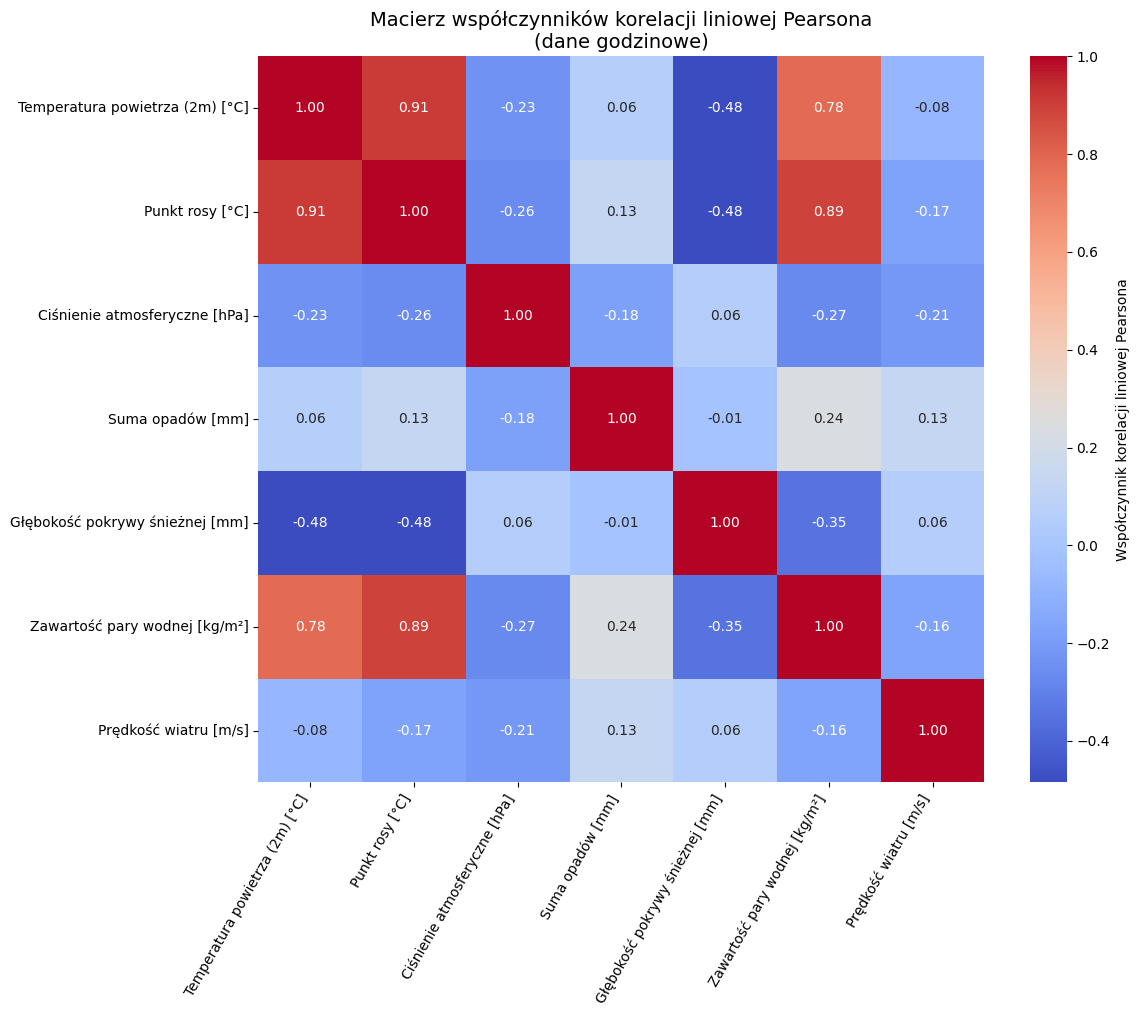

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapowanie nazw i jednostek dla lepszej czytelności
labels = {
    'temp': 'Temperatura powietrza (2m) [°C]',
    'dewpoint': 'Punkt rosy [°C]',
    'pressure': 'Ciśnienie atmosferyczne [hPa]',
    'precip': 'Suma opadów [mm]',
    'snow_depth': 'Głębokość pokrywy śnieżnej [mm]',
    'water_vapour': 'Zawartość pary wodnej [kg/m²]',
    'wind_speed': 'Prędkość wiatru [m/s]'
}

plt.figure(figsize=(12, 10))
corr = df[list(labels.keys())].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    xticklabels=[labels[c] for c in corr.columns],
    yticklabels=[labels[c] for c in corr.columns],
    cbar_kws={"label": "Współczynnik korelacji liniowej Pearsona"}
)
plt.xticks(rotation=60, ha="right")
plt.title("Macierz współczynników korelacji liniowej Pearsona\n(dane godzinowe)", fontsize=14)
plt.tight_layout()
plt.show()


### Analiza VIF

In [6]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# VIF
# Wybór zmiennych
features = [
    "temp",
    "dewpoint",
    "pressure",
    "wind_speed",
    "precip",
    "snow_depth",
    "water_vapour"
]

X = df[features].dropna()

# Standaryzacja
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Iteracyjny VIF
threshold_vif = 5
variables = X_scaled.columns.tolist()

while True:
    X_const = sm.add_constant(X_scaled[variables])

    vif_df = pd.DataFrame({
        "Zmienna": variables,
        "VIF": [
            variance_inflation_factor(X_const.values, i+1)
            for i in range(len(variables))
        ]
    })

    max_vif = vif_df["VIF"].max()
    max_var = vif_df.loc[vif_df["VIF"].idxmax(), "Zmienna"]

    print("\nAktualny VIF:")
    print(vif_df.sort_values("VIF", ascending=False))

    if max_vif > threshold_vif:
        print(f"Usuwam zmienną: {max_var} (VIF = {max_vif:.2f})")
        variables.remove(max_var)
    else:
        print("\nWszystkie VIF poniżej progu – koniec.")
        break

# Ostateczny zbiór zmiennych
X_reduced = X_scaled[variables]

print("\nOstateczny zestaw zmiennych:")
print(variables)


Aktualny VIF:
        Zmienna        VIF
1      dewpoint  12.066458
0          temp   6.408919
6  water_vapour   5.406913
5    snow_depth   1.383883
2      pressure   1.182322
3    wind_speed   1.179694
4        precip   1.161599
Usuwam zmienną: dewpoint (VIF = 12.07)

Aktualny VIF:
        Zmienna       VIF
0          temp  3.179054
5  water_vapour  3.085584
4    snow_depth  1.309945
1      pressure  1.174470
3        precip  1.159636
2    wind_speed  1.149414

Wszystkie VIF poniżej progu – koniec.

Ostateczny zestaw zmiennych:
['temp', 'pressure', 'wind_speed', 'precip', 'snow_depth', 'water_vapour']


W celu ograniczenia współliniowości pomiędzy zmiennymi objaśniającymi obliczono współczynnik Variance Inflation Factor (VIF). Analizę przeprowadzono na standaryzowanych zmiennych ciągłych. Zmienne o wartościach VIF przekraczających 5 usuwano iteracyjnie, rozpoczynając od zmiennej o najwyższym VIF. Ostatecznie uzyskano zestaw predyktorów charakteryzujących się niską współliniowością i jednoznaczną interpretacją fizyczną.

### Usunięcie zmiennych o wysokiej korelacji

                         temp     pressure  snow_depth    precip  wind_speed
time                                                                        
2000-01-01 00:00:00 -7.919281  1025.883179   27.741709  0.002481    1.483591
2000-01-01 01:00:00 -8.452972  1026.258789   27.744379  0.003721    1.814365
2000-01-01 02:00:00 -8.282562  1026.253174   27.753342  0.006200    1.887616
2000-01-01 03:00:00 -8.581146  1026.443115   31.469755  0.012497    1.964938
2000-01-01 04:00:00 -8.493011  1026.517456   32.829399  0.028038    1.790603


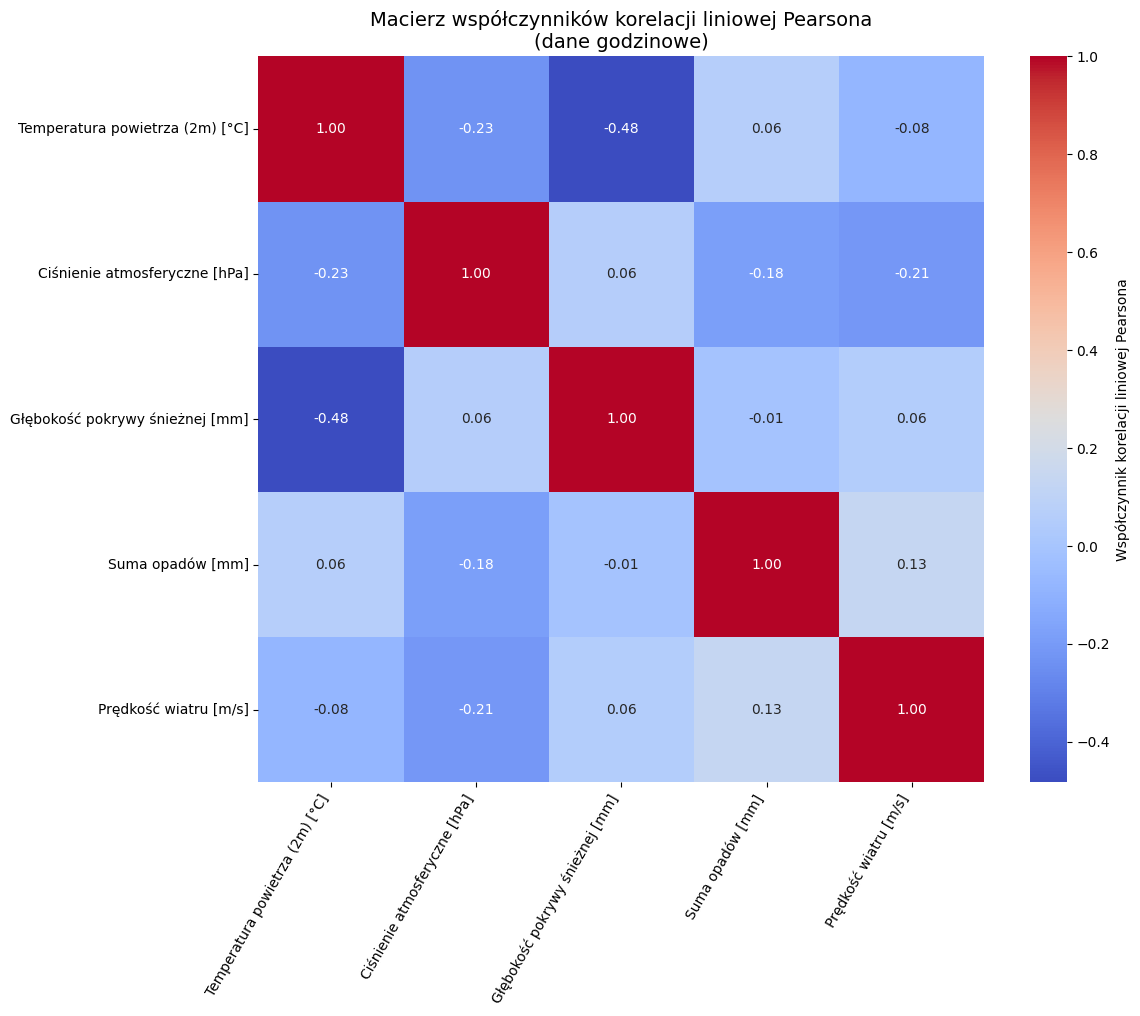

In [7]:
# usunięcie zbędnych zmiennych
df = df.drop(columns=["dewpoint", "water_vapour"])
print(df.head())

# ponowna weryfikacja korelacji
plt.figure(figsize=(12, 10))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    xticklabels=[labels[c] for c in corr.columns],
    yticklabels=[labels[c] for c in corr.columns],
    cbar_kws={"label": "Współczynnik korelacji liniowej Pearsona"}
)
plt.xticks(rotation=60, ha="right")
plt.title("Macierz współczynników korelacji liniowej Pearsona\n(dane godzinowe)", fontsize=14)
plt.tight_layout()
plt.show()

## Agregacje dobowe

In [8]:
# agregacje dzienne
daily = xr.Dataset()

daily["temp_min"]  = ds["temp"].resample(time="1D").min()
daily["temp_max"]  = ds["temp"].resample(time="1D").max()
daily["temp_mean"] = ds["temp"].resample(time="1D").mean()

daily["precip_sum"] = ds["precip"].resample(time="1D").sum()

daily["wind_speed_mean"] = ds["wind_speed"].resample(time="1D").mean()
daily["pressure_mean"]   = ds["pressure"].resample(time="1D").mean()

daily["snow_depth_max"] = ds["snow_depth"].resample(time="1D").max()
daily["snow_depth_mean"] = ds["snow_depth"].resample(time="1D").mean()
# dzień ze śniegiem to taki, gdzie średnia grubość > 0
daily["is_snow_day"] = (daily["snow_depth_mean"] > 0).astype(int)

# konwersja do dataframe
df_daily = (
    daily
    .to_dataframe()
    .reset_index()
    .set_index("time")
    .sort_index()
)

df_daily.index = df_daily.index.date
df_daily.index.name = "date"

print(df_daily.head())

             temp_min  temp_max  temp_mean  precip_sum  wind_speed_mean  \
date                                                                      
2000-01-01  -9.830170 -3.395111  -6.974589    0.254664         1.435306   
2000-01-02 -14.864105 -5.423187  -9.670787    0.054554         1.753786   
2000-01-03  -4.912933  0.725983  -1.511230    1.306296         2.332896   
2000-01-04  -1.664398  2.024567  -0.268066    0.675195         2.120340   
2000-01-05  -1.239349  2.773834   0.904643    2.724191         3.640270   

            pressure_mean  snow_depth_max  snow_depth_mean  is_snow_day  
date                                                                     
2000-01-01    1026.398926       33.845665        32.844368            1  
2000-01-02    1028.789429       33.807556        30.192986            1  
2000-01-03    1025.120972       29.686413        27.244814            1  
2000-01-04    1021.329163       26.798353        24.770548            1  
2000-01-05    1019.680847     

Dane godzinowe zagregowano do skali dobowej zgodnie z zaleceniami klimatologicznymi. Dla temperatury obliczono wartości minimalne, maksymalne i średnie, natomiast dla opadów zastosowano sumowanie dobowe. Dla głębokości pokrywy śnieżnej wyznaczono maksimum dobowe, niezbędne do analizy ekstremów oraz średnią dobową, która oddaje ogólny stan zaśnieżenia w ciągu dnia.
Pozostałe zmienne meteorologiczne zagregowano za pomocą średniej dobowej. Agregacja umożliwiła analizę zmienności klimatu w skali dobowej oraz identyfikację ekstremów pogodowych.

## Agregacje miesięczne

In [9]:
monthly = xr.Dataset()

# Temperatura
monthly["temp_mean"] = daily["temp_mean"].resample(time="1MS").mean()
monthly["temp_min"]  = daily["temp_min"].resample(time="1MS").min()
monthly["temp_max"]  = daily["temp_max"].resample(time="1MS").max()

# Opady
monthly["precip_sum"] = daily["precip_sum"].resample(time="1MS").sum()

# Wiatr i Ciśnienie
monthly["wind_speed_mean"] = daily["wind_speed_mean"].resample(time="1MS").mean()
monthly["pressure_mean"]   = daily["pressure_mean"].resample(time="1MS").mean()

# Śnieg - Średnia głębokość
monthly["snow_depth_mean"] = daily["snow_depth_mean"].resample(time="1MS").mean()

# Śnieg - liczba dni (Suma zer i jedynek z 'is_snow_day')
monthly["snow_days_count"] = daily["is_snow_day"].resample(time="1MS").sum()

df_monthly = (
    monthly
    .to_dataframe()
    .reset_index()
    .set_index("time")
    .sort_index()
)
df_monthly.index = df_monthly.index.to_period("M")
df_monthly.index.name = "date"

print(df_monthly.head())



         temp_mean   temp_min   temp_max  precip_sum  wind_speed_mean  \
date                                                                    
2000-01  -3.441636 -14.864105   6.098541   71.798820         3.375304   
2000-02   0.882506 -12.002289  12.932526   67.774750         3.180488   
2000-03   2.912190  -5.399994  13.692291  105.067711         3.314864   
2000-04  11.350135  -2.211761  24.582672  106.011536         2.873369   
2000-05  14.238705   0.824615  26.735504   99.385262         2.228469   

         pressure_mean  snow_depth_mean  snow_days_count  
date                                                      
2000-01    1020.994847        29.341892               31  
2000-02    1019.766983         6.226356               29  
2000-03    1015.514048         2.200453               23  
2000-04    1010.372500         0.301028                8  
2000-05    1016.686199         0.000000                0  


Dane dobowe zagregowano do skali miesięcznej, obliczając średnie miesięczne temperatury oraz sumy miesięczne opadów. Pozostałe zmienne meteorologiczne agregowano za pomocą średniej. Dodatkowo policzono liczbę dni z pokrywą śnieżną. Agregacja miesięczna umożliwia analizę sezonowości oraz długoterminowych zmian klimatu.

## Agregacje roczne

In [10]:
annual = xr.Dataset()

annual["temp_mean"] = daily["temp_mean"].resample(time="1YS").mean()
annual["temp_min"]  = daily["temp_min"].resample(time="1YS").min()
annual["temp_max"]  = daily["temp_max"].resample(time="1YS").max()

annual["precip_sum"] = daily["precip_sum"].resample(time="1YS").sum()

annual["wind_speed_mean"] = daily["wind_speed_mean"].resample(time="1YS").mean()
annual["pressure_mean"]   = daily["pressure_mean"].resample(time="1YS").mean()

annual["snow_depth_mean"] = daily["snow_depth_mean"].resample(time="1YS").mean()
# Śnieg (suma dni, w których leżał śnieg)
annual["snow_days_count"] = daily["is_snow_day"].resample(time="1YS").sum()

# konwersja do dataframe
df_annual = (
    annual
    .to_dataframe()
    .reset_index()
    .set_index("time")
    .sort_index()
)

df_annual.index = df_annual.index.year
df_annual.index.name = "year"

print(df_annual.head())

      temp_mean   temp_min   temp_max   precip_sum  wind_speed_mean  \
year                                                                  
2000   8.783096 -14.864105  32.220367   958.436340         2.683276   
2001   7.517255 -19.308792  30.082672  1121.336914         2.670617   
2002   8.299486 -22.035309  29.529938   928.873718         2.700109   
2003   7.636656 -20.047913  29.181793   757.870789         2.681948   
2004   7.518954 -18.669342  29.164459  1049.630615         2.655890   

      pressure_mean  snow_depth_mean  snow_days_count  
year                                                   
2000    1016.176926         3.229359              107  
2001    1015.926764         3.856498              150  
2002    1016.590021         2.966580              117  
2003    1018.285007         3.634459              125  
2004    1016.467473         3.385268              142  


Agregacja roczna została wykonana w celu identyfikacji długookresowych trendów klimatycznych. Dla temperatury wyznaczono średnie roczne oraz wartości ekstremalne, natomiast dla opadów obliczono roczne sumy.

## Agregacje sezonowe

In [11]:
# Przygotowanie danych sezonowych
season = daily["time"].dt.season
year = daily["time"].dt.year

# rok sezonowy: grudzień przypisany do kolejnego roku, ale tylko jeśli rok+1 istnieje w danych
max_year = daily["time"].dt.year.max().item()  # ostatni rok w zbiorze
min_year = daily["time"].dt.year.min().item()  # pierwszy rok w zbiorze
season_year = year + ((daily["time"].dt.month == 12) & (year < max_year))

# mapowanie nazw sezonów na polskie
season_pl = xr.where(season == "DJF", "zima",
             xr.where(season == "MAM", "wiosna",
             xr.where(season == "JJA", "lato",
             xr.where(season == "SON", "jesien", ""))))

daily_seasonal = daily.assign_coords(
    season=season_pl,
    season_year=season_year
)

# Filtracja
# Usuwamy pierwszą zimę (bo nie mamy grudnia z roku poprzedniego)
# Usuwamy też grudzień z ostatniego roku (bo nie mamy do niego stycznia/lutego z roku następnego)
is_full_season = ~(
    (daily_seasonal.season == "zima") & (daily_seasonal.season_year == min_year)
    ) & ~(
        (daily_seasonal.time.dt.month == 12) & (daily_seasonal.time.dt.year == max_year))

daily_seasonal = daily_seasonal.where(is_full_season, drop=True)

# agregacja sezonowa
# Definiujemy grupy
groups = ["season_year", "season"]

seasonal = xr.Dataset()

# Temperatura
seasonal["temp_mean"]   = daily_seasonal["temp_mean"].groupby(groups).mean(dim="time")
seasonal["temp_min"]    = daily_seasonal["temp_min"].groupby(groups).min(dim="time")
seasonal["temp_max"]    = daily_seasonal["temp_max"].groupby(groups).max(dim="time")

# Opady
seasonal["precip_sum"]  = daily_seasonal["precip_sum"].groupby(groups).sum(dim="time")

# Wiatr i Ciśnienie
seasonal["wind_speed_mean"] = daily_seasonal["wind_speed_mean"].groupby(groups).mean(dim="time")
seasonal["pressure_mean"]   = daily_seasonal["pressure_mean"].groupby(groups).mean(dim="time")

# ŚNIEG
# Średnia głębokość pokrywy w sezonie
seasonal["snow_depth_mean"] = daily_seasonal["snow_depth_mean"].groupby(groups).mean(dim="time")
# LICZBA DNI ZE ŚNIEGIEM (Suma dni w sezonie)
seasonal["snow_days_count"] = daily_seasonal["is_snow_day"].groupby(groups).sum(dim="time")

# Konwersja do DataFrame i formatowanie

df_seasonal = (
    seasonal
    .to_dataframe()
    .dropna(how='all')
    .reset_index()
    .rename(columns={"season_year": "year"})
)

# Uporządkowanie nazw sezonów jako kategoryczne (żeby sortowały się logicznie, a nie alfabetycznie)
seasons_order = ["zima", "wiosna", "lato", "jesien"]
df_seasonal['season'] = pd.Categorical(
    df_seasonal['season'],
    categories=seasons_order,
    ordered=True
)

# Finalne sortowanie i indeksowanie
df_seasonal = df_seasonal.sort_values(["year", "season"]).set_index(["year", "season"])

print(df_seasonal.head())
print(df_seasonal.tail())

             temp_mean   temp_min   temp_max  precip_sum  wind_speed_mean  \
year season                                                                 
2000 wiosna   9.480237  -5.399994  26.735504  310.464508         2.804830   
     lato    16.435204   4.161774  32.220367  362.592407         2.236648   
     jesien   9.732648  -2.903900  24.876373  100.890587         2.693926   
2001 zima    -0.606996 -18.746536  13.346100  153.994492         2.750283   
     wiosna   8.241840  -5.203461  25.350250  268.252960         2.694990   

             pressure_mean  snow_depth_mean  snow_days_count  
year season                                                   
2000 wiosna    1014.232420         0.839618             31.0  
     lato      1015.628008         0.000000              0.0  
     jesien    1016.304993         0.000000              0.0  
2001 zima      1017.169713         5.257611             72.0  
     wiosna    1012.406005         0.460065             38.0  
             temp_m

Agregacje sezonowe wykonano na podstawie danych dziennych, przyjmując klasyczną definicję sezonów klimatycznych (DJF, MAM, JJA, SON). Dla sezonu zimowego grudzień przypisano do roku następnego, zgodnie z konwencją klimatologiczną.  

W trakcie agregacji sezonowej musieliśmy przypisać miesiąc grudzień do roku następnego, aby poprawnie wyznaczyć sezony zimowe (DJF). Dzięki temu, np. grudzień 2000 był traktowany jako zima 2001. Jednak w ostatnim roku zbioru (2025) grudzień nie miał kolejnego roku, przez co powstał „sezon 2026” zawierający tylko jeden miesiąc. W celu uniknięcia braków danych, w procesie przetwarzania wiersze te zostały odfiltrowane, dzięki czemu wszystkie sezony w zbiorze są pełne, obejmując trzy miesiące.  

# Eksploracyjna Analiza Danych

### Charakterystyka statystyczna

In [12]:
name_map = {
    "temp_mean": "Temperatura średnia [°C]",
    "temp_min": "Temperatura minimalna [°C]",
    "temp_max": "Temperatura maksymalna [°C]",
    "pressure_mean": "Ciśnienie średnie [hPa]",
    "precip_sum": "Suma opadów [mm]",
    "snow_depth_mean": "Średnia grubość pokrywy śnieżnej [mm]",
    "snow_depth_max": "Maksymalna grubość pokrywy śnieżnej [mm]",
    "wind_speed_mean": "Średnia prędkość wiatru [m/s]"
}


summary_table = df_daily[list(name_map.keys())].rename(columns=name_map).describe().T


summary_table.style.format("{:.2f}") \
    .set_caption("Statystyki opisowe zmiennych meteorologicznych (2000-2024)")\
    .set_table_styles([{'selector': 'caption', 'props': [('color', 'black'), ('font-size', '16px'), ('font-weight', 'bold')]}])

,count,mean,std,min,25%,50%,75%,max
Temperatura średnia [°C],9132.00,8.44,8.24,-23.61,2.15,8.87,15.19,26.45
Temperatura minimalna [°C],9132.00,4.10,7.45,-27.19,-0.86,4.43,10.01,19.34
Temperatura maksymalna [°C],9132.00,12.67,9.38,-17.75,4.98,13.23,20.28,34.38
Ciśnienie średnie [hPa],9132.00,1016.74,8.00,981.07,1011.82,1016.64,1021.59,1048.69
Suma opadów [mm],9132.00,2.66,4.68,0.00,0.05,0.80,3.34,71.81
Średnia grubość pokrywy śnieżnej [mm],9132.00,2.56,7.46,0.00,0.00,0.00,0.41,63.74
Maksymalna grubość pokrywy śnieżnej [mm],9132.00,3.06,8.14,0.00,0.00,0.00,0.97,65.32
Średnia prędkość wiatru [m/s],9132.00,2.61,1.09,0.61,1.79,2.41,3.22,8.53


## Wizualizacje

In [13]:
# Lista zmiennych i ich etykiety + jednostki
variables_info = {
    "temp_mean": ("Temperatura powietrza", "°C"),
    "pressure_mean": ("Ciśnienie atmosferyczne", "hPa"),
    "precip_sum": ("Suma opadów", "mm/h"),
    "snow_depth_mean": ("Głębokość pokrywy śnieżnej", "mm"),
    "wind_speed_mean": ("Prędkość wiatru", "m/s"),
}

### Macierz współczynników korelacji liniowej Pearsona

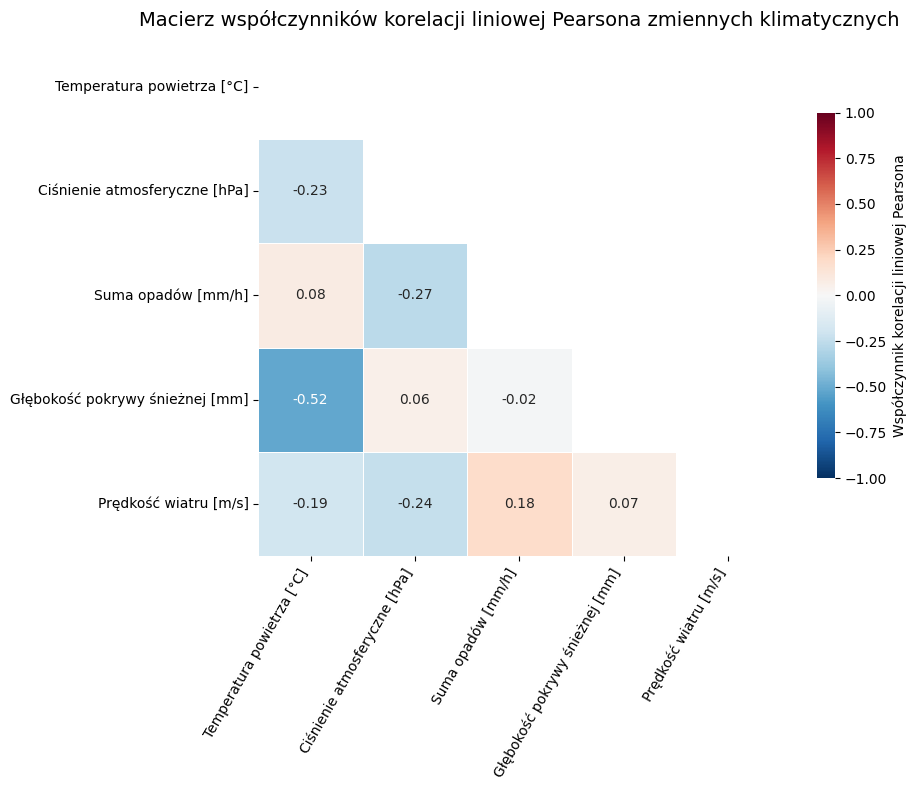

In [14]:
import numpy as np

# 1. Obliczenie macierzy współczynników korelacji
selected_columns = list(variables_info.keys())
corr_matrix = df_daily[selected_columns].corr()

# 2. Przygotowanie etykiet w formacie: Nazwa [Jednostka]
labels = [f"{info[0]} [{info[1]}]" for info in variables_info.values()]

# 3. Tworzenie maski dla górnego trójkąta
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)

# 4. Rysowanie macierzy
plt.figure(figsize=(10, 8))

heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,             # Wyświetla wartości współczynników
    fmt=".2f",              # Formatowanie do 2 miejsc po przecinku
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .7, "label": "Współczynnik korelacji liniowej Pearsona"},
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Macierz współczynników korelacji liniowej Pearsona zmiennych klimatycznych", fontsize=14)
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()



### Histogramy - rozkłady zmiennych

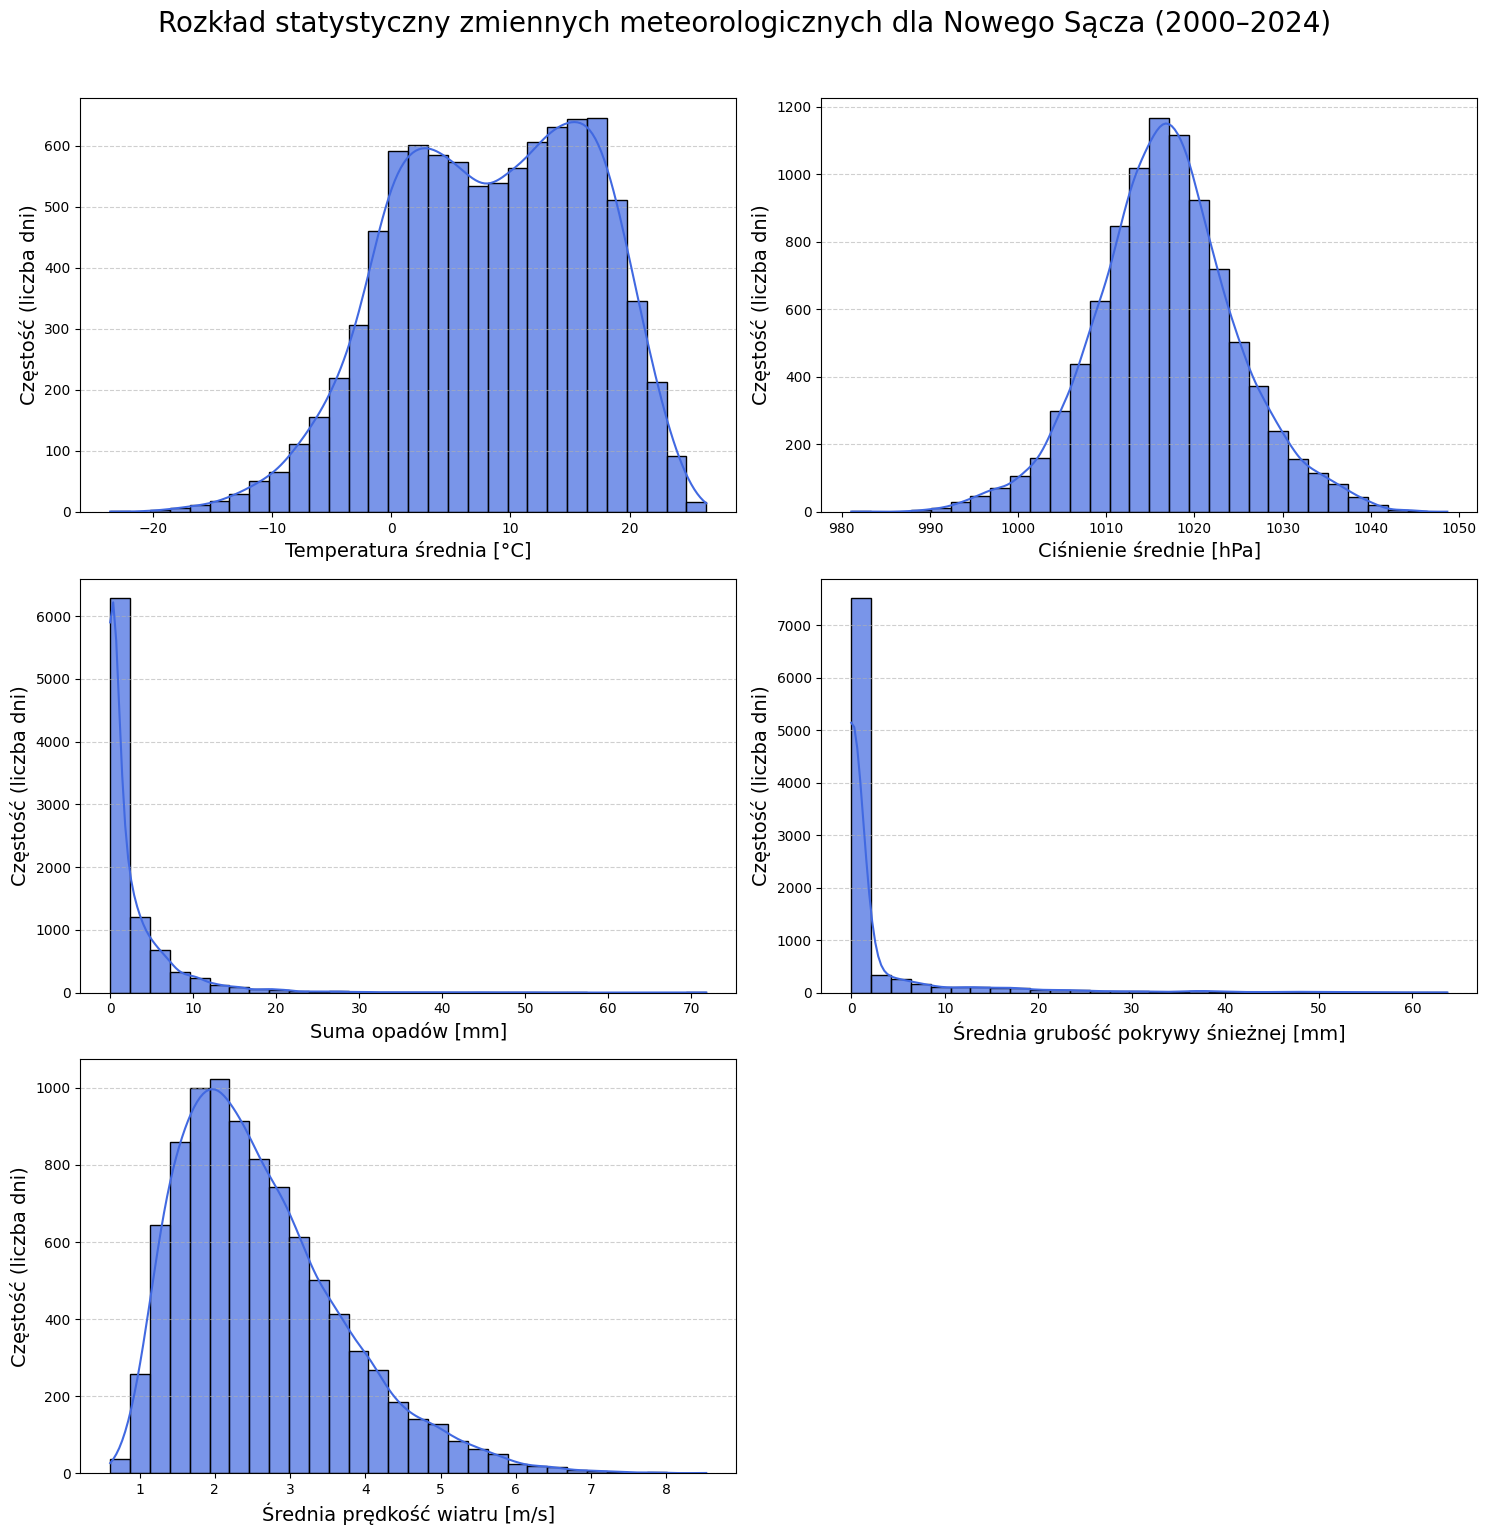

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Definicja zmiennych do wykresów
variables_to_plot = {
    "temp_mean": ("Temperatura średnia", "°C"),
    "pressure_mean": ("Ciśnienie średnie", "hPa"),
    "precip_sum": ("Suma opadów", "mm"),
    "snow_depth_mean": ("Średnia grubość pokrywy śnieżnej", "mm"),
    "wind_speed_mean": ("Średnia prędkość wiatru", "m/s"),
}

# 2. Parametry siatki (Grid)
n_vars = len(variables_to_plot)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

# 3. Tworzenie figury i osi
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# 4. Pętla generująca wykresy
for i, (var, (label, unit)) in enumerate(variables_to_plot.items()):
    ax = axes[i]
    sns.histplot(df_daily[var], kde=True, bins=30, color="royalblue", ax=ax, alpha=0.7)

    #ax.set_title(f"Rozkład: {label}", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"{label} [{unit}]", fontsize=14)
    ax.set_ylabel("Częstość (liczba dni)", fontsize=14)
    ax.grid(axis='y', linestyle="--", alpha=0.6)

fig.suptitle("Rozkład statystyczny zmiennych meteorologicznych dla Nowego Sącza (2000–2024)",
             fontsize=20, y=1.02)

# 6. Usunięcie pustych pól
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 7. Dopasowanie układu
plt.tight_layout()
plt.show()

Wykresy przedstawiają rozkłady zmiennych wraz z dopasowanym jądrowym estymatorem gęstości (KDE).



## Analiza trendów rocznych i sezonowych - zmienność czasowa


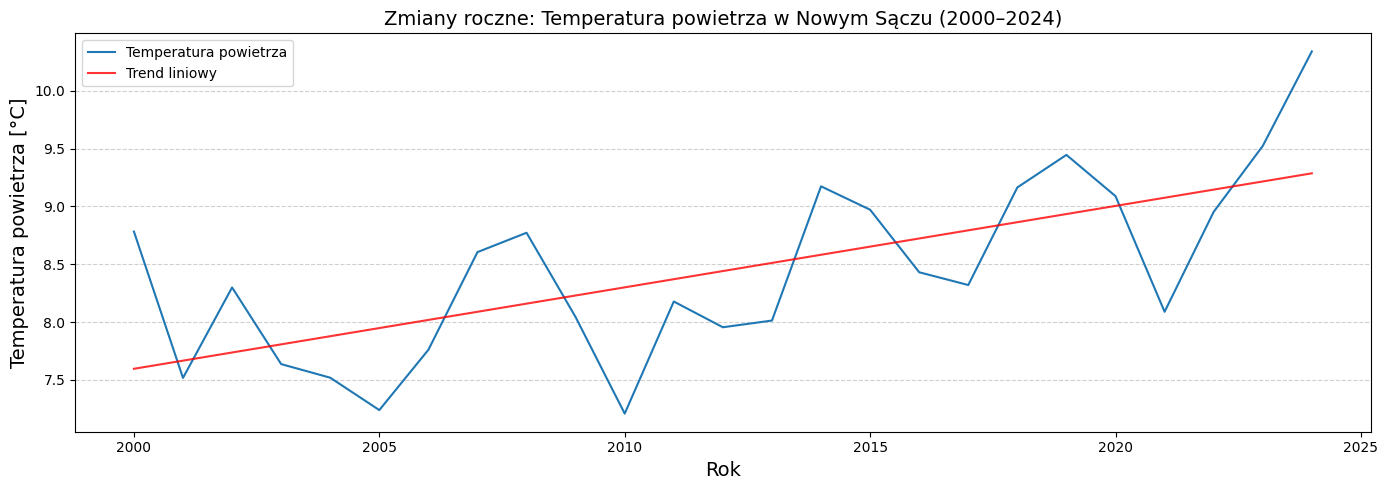

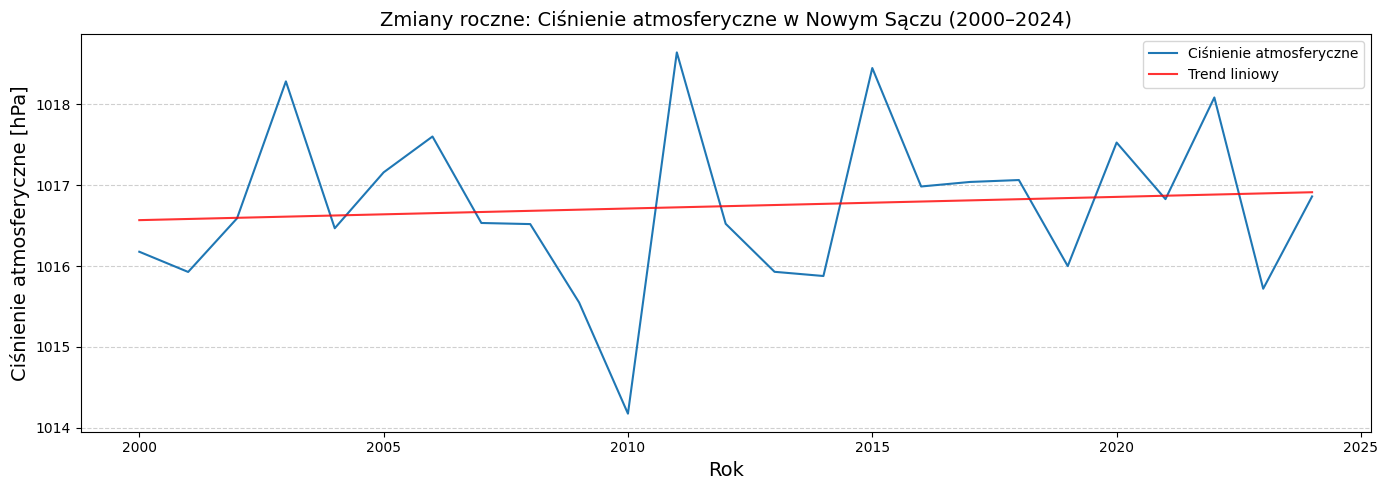

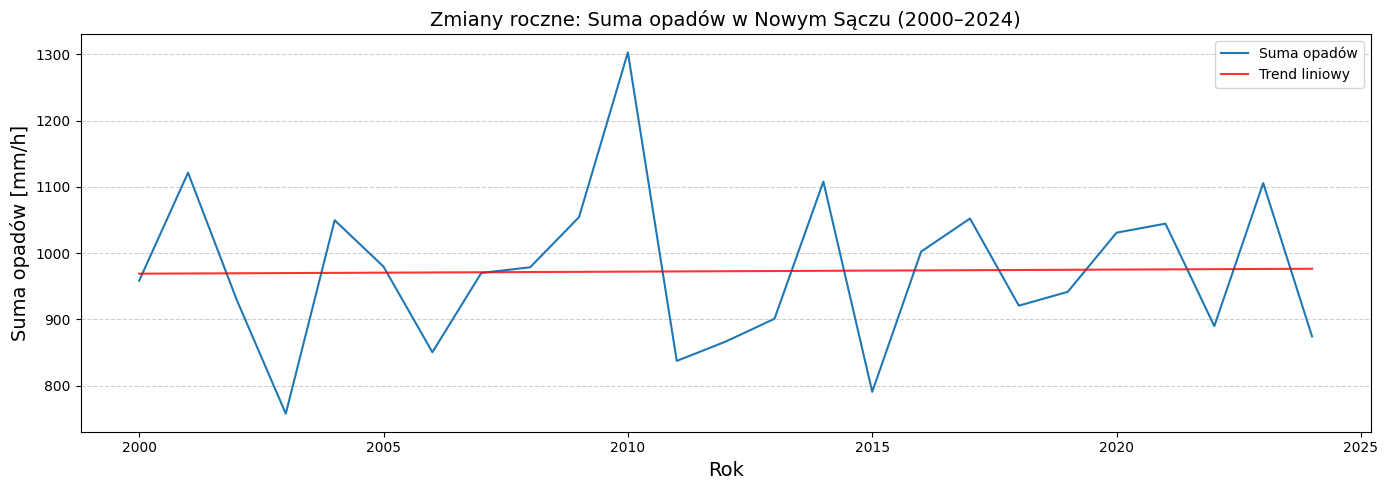

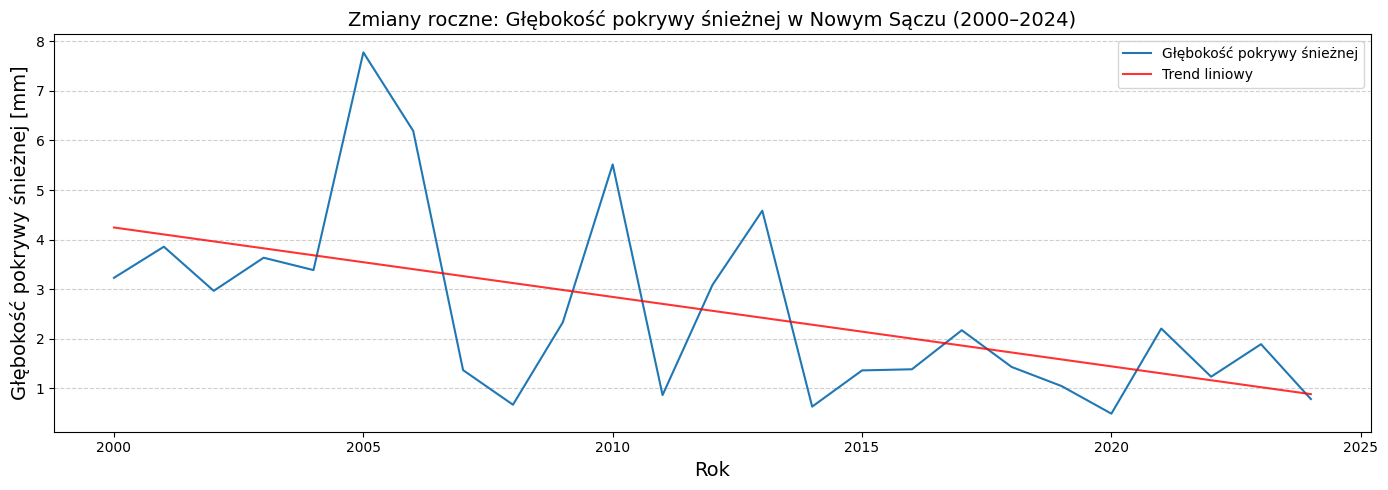

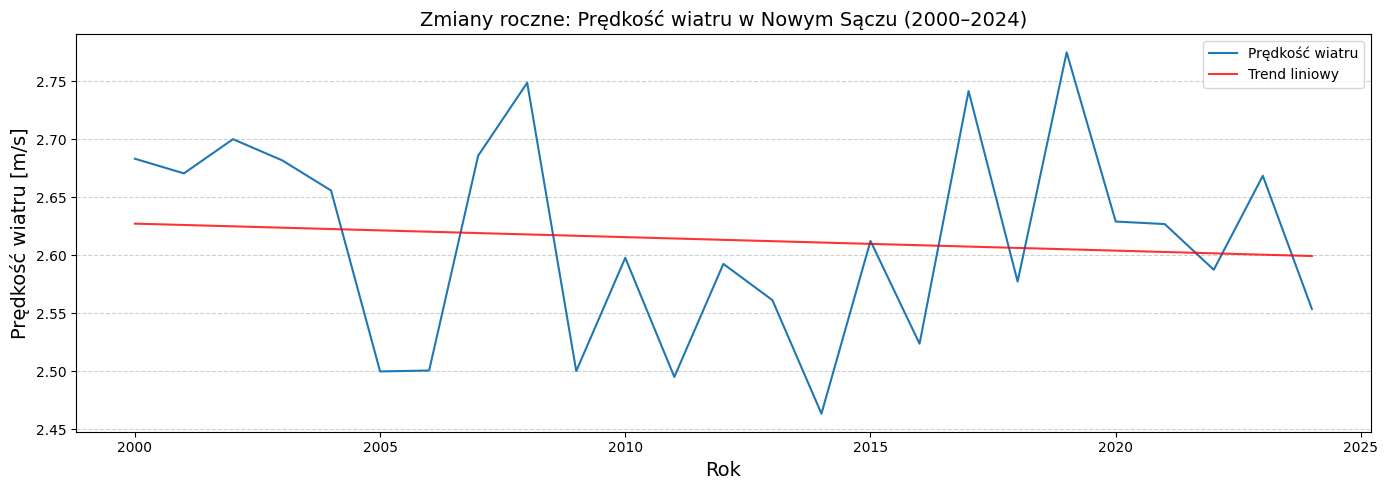

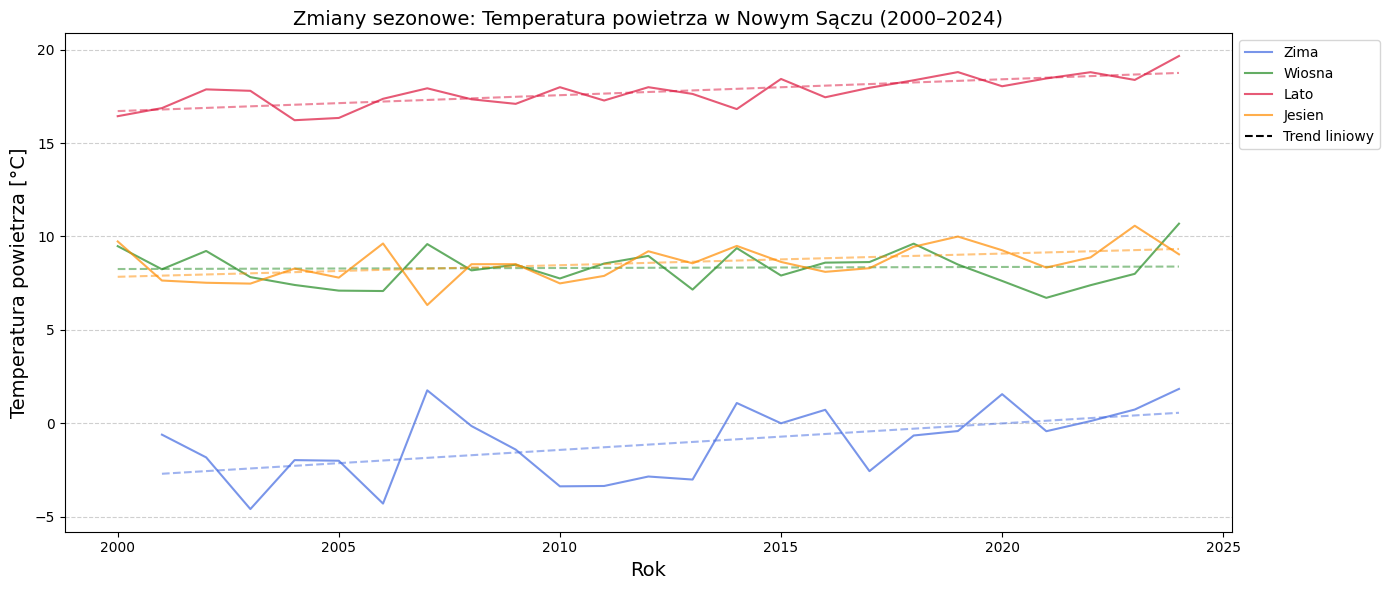

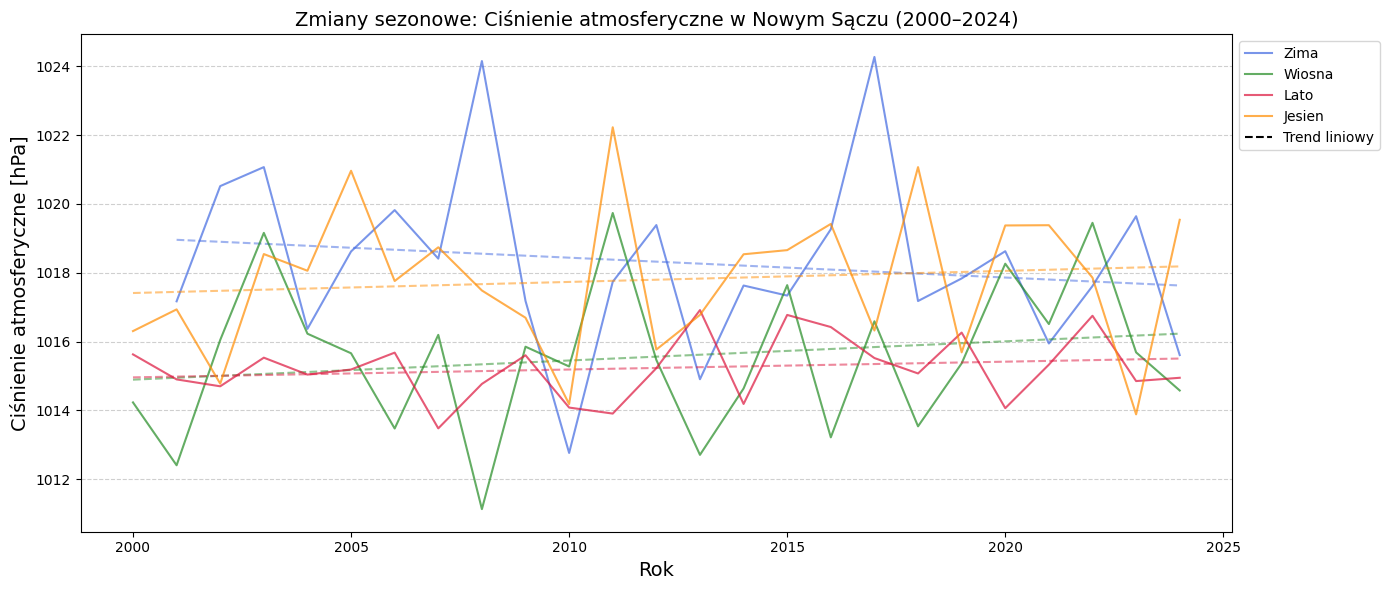

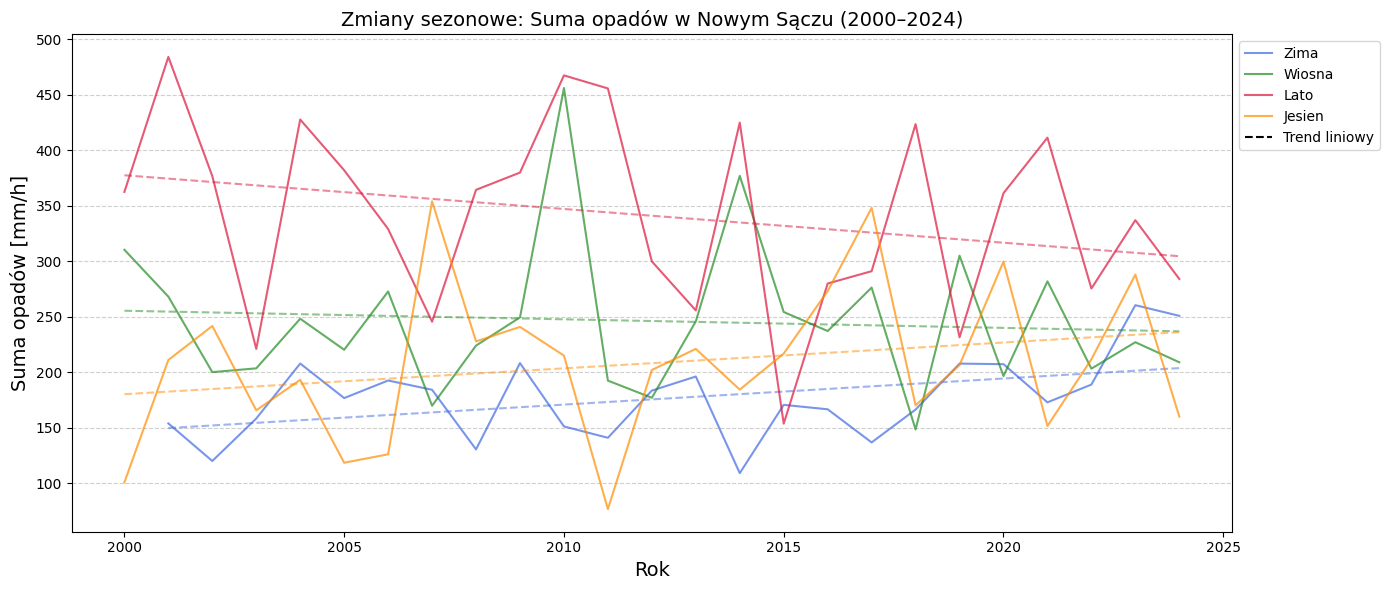

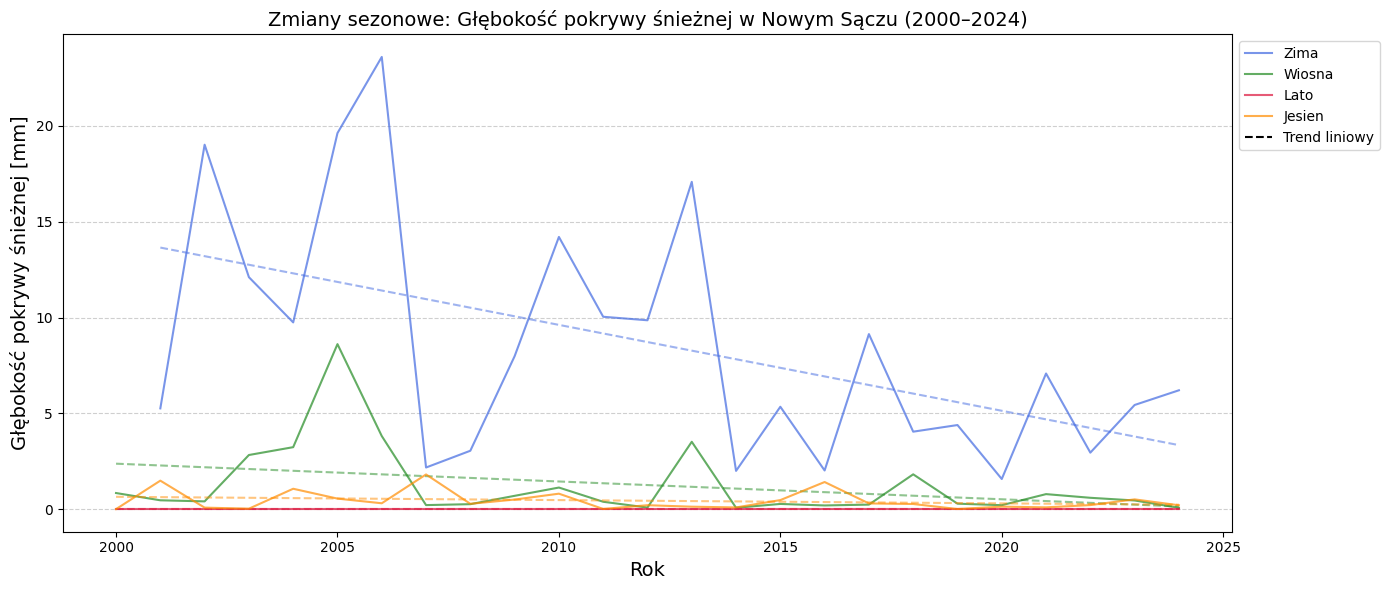

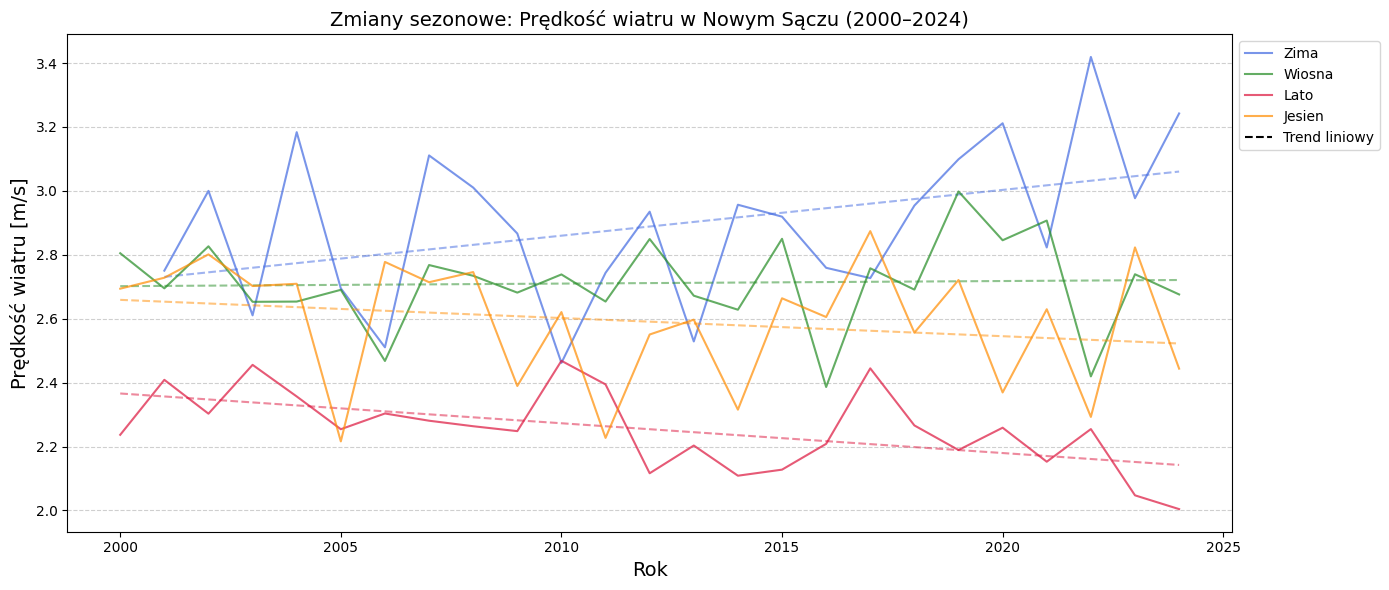

In [16]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.lines as mlines

# # Szeregi czasowe - zmiany miesięczne - średnia krocząca
# for var, (label, unit) in variables_info.items():
#     plt.figure(figsize=(14,5))

#     # Konwersja indeksu Period na Timestamp dla Matplotlib
#     x_axis = df_monthly.index.to_timestamp()

#     plt.plot(x_axis, df_monthly[var], label=label, color="tab:blue", linewidth=1.5)
#     plt.title(f"Zmiany miesięczne: {label} w Nowym Sączu (2000–2024)", fontsize=12)
#     plt.xlabel("Rok", fontsize=12)
#     plt.ylabel(f"{label} [{unit}]", fontsize=10)
#     plt.grid(axis='y', linestyle='--', alpha=0.6)

#     # Obliczenie średniej kroczącej (wygładzenie trendu)
#     rolling_mean = df_monthly[var].rolling(window=12, center=True).mean()
#     plt.plot(x_axis, rolling_mean, color="red", alpha=0.8, label="Średnia krocząca (12m)", linewidth=1.5)

#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# # Szeregi czasowe - zmiany miesięczne - trend
# for var, (label, unit) in variables_info.items():
#     plt.figure(figsize=(14,5))

#     # Konwersja indeksu Period na Timestamp dla Matplotlib
#     x_axis = df_monthly.index.to_timestamp()
#     y_values = df_monthly[var].values

#     plt.plot(x_axis, y_values, label=label, color="tab:blue", linewidth=1.5)
#     plt.title(f"Zmiany miesięczne: {label} w Nowym Sączu (2000–2024)", fontsize=12)
#     plt.xlabel("Rok", fontsize=12)
#     plt.ylabel(f"{label} [{unit}]", fontsize=10)
#     plt.grid(axis='y', linestyle='--', alpha=0.6)

#     x_numeric = np.arange(len(x_axis)).reshape(-1, 1)
#     model = LinearRegression().fit(x_numeric, y_values)
#     trend_line = model.predict(x_numeric)

#     # Rysowanie linii trendu
#     plt.plot(x_axis, trend_line, color="red", linewidth=2.5, label="Trend długookresowy")

#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#________________________________
# Szeregi czasowe - zmiany roczne - trend
for var, (label, unit) in variables_info.items():
    plt.figure(figsize=(14,5))
    x_axis = df_annual.index
    plt.plot(x_axis, df_annual[var], label=label, color="tab:blue", linewidth=1.5)

    # Dodanie linii trendu
    # Prosta regresja liniowa
    X = np.array(df_annual.index).reshape(-1, 1)
    y = df_annual[var].values
    model = LinearRegression().fit(X, y)
    trend = model.predict(X)
    plt.plot(x_axis, trend, color="red", alpha=0.8, label="Trend liniowy", linewidth=1.5)

    plt.title(f"Zmiany roczne: {label} w Nowym Sączu (2000–2024)", fontsize=14)
    plt.xlabel("Rok", fontsize=14)
    plt.ylabel(f"{label} [{unit}]", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.legend()
    plt.tight_layout()
    plt.show()

#_________________________________
# Szeregi czasowe - zmiany sezonowe
for var, (label, unit) in variables_info.items():
    plt.figure(figsize=(14, 6))

    # Definiujemy kolory dla poszczególnych pór roku
    season_colors = {
        "zima": "royalblue",
        "wiosna": "forestgreen",
        "lato": "crimson",
        "jesien": "darkorange"
    }

    # Resetujemy indeks, aby mieć dostęp do kolumn 'year' i 'season'
    df_plot = df_seasonal.reset_index()

    for s_name in seasons_order:
        # Filtrujemy dane dla konkretnego sezonu
        season_data = df_plot[df_plot['season'] == s_name]

        x_axis = season_data['year']
        y_values = season_data[var]

        # Rysowanie linii dla danego sezonu
        plt.plot(x_axis, y_values,
                 label=f"{s_name.capitalize()}", color=season_colors[s_name],
                 linewidth=1.5, alpha=0.7)

        # Opcjonalnie: Dodanie linii trendu dla każdego sezonu
        X = x_axis.values.reshape(-1, 1)
        model = LinearRegression().fit(X, y_values.values)
        trend = model.predict(X)
        plt.plot(x_axis, trend, color=season_colors[s_name],
                 linestyle='--', linewidth=1.5, alpha=0.5)

    plt.title(f"Zmiany sezonowe: {label} w Nowym Sączu (2000–2024)", fontsize=14)
    plt.xlabel("Rok", fontsize=14)
    plt.ylabel(f"{label} [{unit}]", fontsize=14)

    plt.grid(axis='y', linestyle='--', alpha=0.6)

    trend_line = mlines.Line2D([], [], color='black', linestyle='--',
                               linewidth=1.5, label='Trend liniowy')

    handles, labels_legend = plt.gca().get_legend_handles_labels()
    handles.append(trend_line)

    plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

### Analiza liczby dni z pokrywą śnieżną

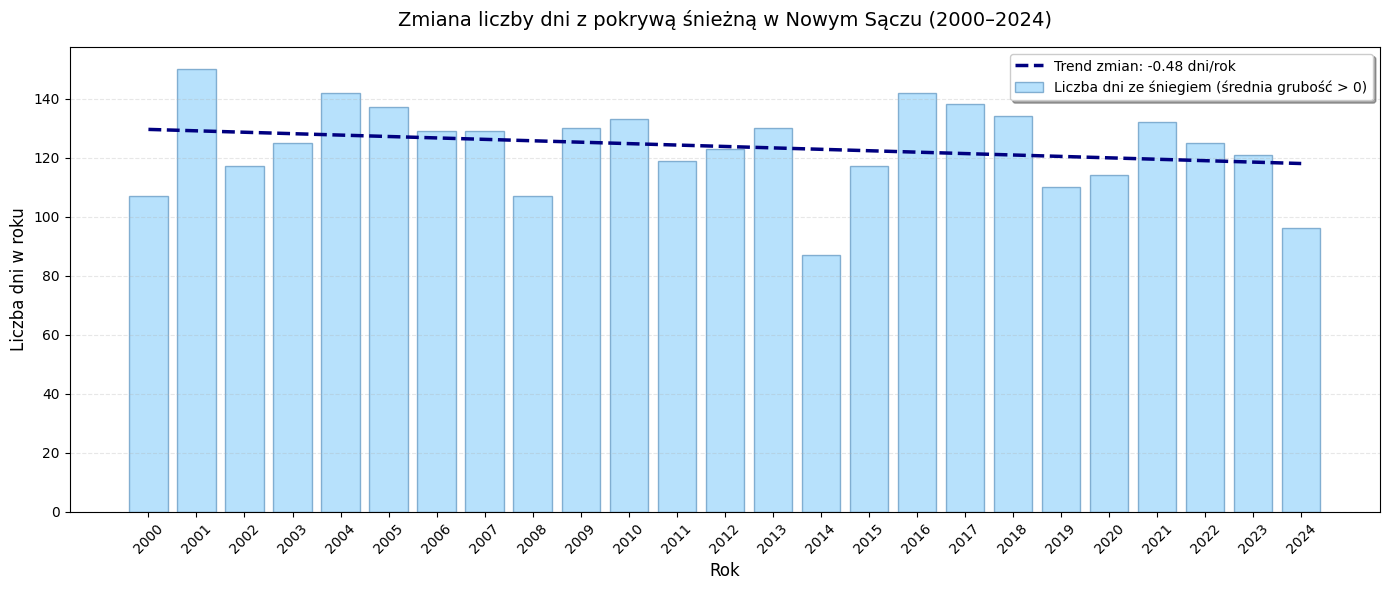

--- ANALIZA ŚNIEGU ---
Średnia roczna zmiana: -0.48 dni/rok
Szacunkowa zmiana w całym okresie (2000-2024): -11.6 dni


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

x = df_annual.index.values
y = df_annual['snow_days_count'].values

# 2. Tworzenie wykresu
plt.figure(figsize=(14, 6))

# Wykres słupkowy (liczba dni ze śniegiem)
plt.bar(x, y, color='lightskyblue', alpha=0.6, edgecolor='steelblue',
        label='Liczba dni ze śniegiem (średnia grubość > 0)')

# 3. Obliczanie trendu liniowego
X_reg = x.reshape(-1, 1)
model_snow = LinearRegression().fit(X_reg, y)
trend_snow = model_snow.predict(X_reg)
slope_snow = model_snow.coef_[0]

# Rysowanie linii trendu
plt.plot(x, trend_snow, color='navy', linestyle='--', linewidth=2.5,
         label=f'Trend zmian: {slope_snow:+.2f} dni/rok')

plt.title("Zmiana liczby dni z pokrywą śnieżną w Nowym Sączu (2000–2024)", fontsize=14, pad=15)
plt.xlabel("Rok", fontsize=12)
plt.ylabel("Liczba dni w roku", fontsize=12)

# Ustawienie osi X (wszystkie lata)
plt.xticks(x, rotation=45)

# Dodanie siatki poziomej dla lepszej czytelności skali dni
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(frameon=True, shadow=True)

plt.tight_layout()
plt.show()

total_change = slope_snow * (x.max() - x.min())
print(f"--- ANALIZA ŚNIEGU ---")
print(f"Średnia roczna zmiana: {slope_snow:+.2f} dni/rok")
print(f"Szacunkowa zmiana w całym okresie ({x.min()}-{x.max()}): {total_change:+.1f} dni")

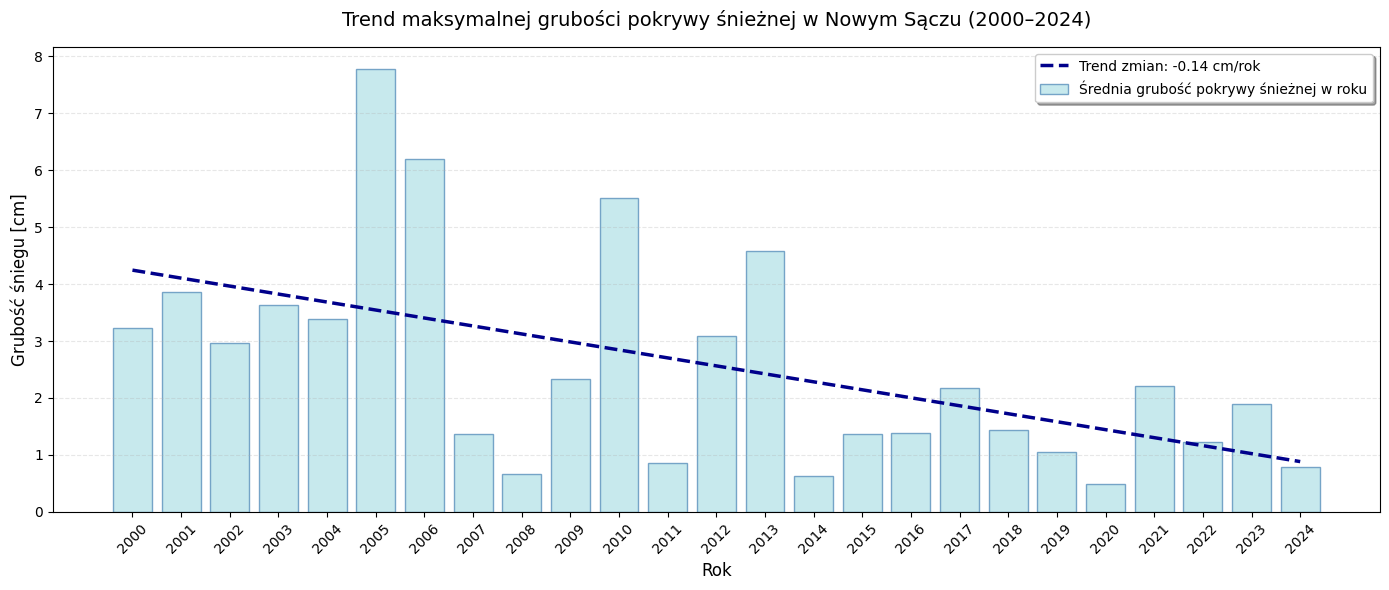

--- ANALIZA MAKSYMALNEJ GRUBOŚCI ŚNIEGU ---
Średnia roczna zmiana rekordu: -0.14 cm/rok


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

x = df_annual.index.values
y = df_annual['snow_depth_mean'].values

# 2. Tworzenie wykresu
plt.figure(figsize=(14, 6))

# Wykres słupkowy dla wartości maksymalnych
plt.bar(x, y, color='powderblue', alpha=0.7, edgecolor='steelblue',
        label='Średnia grubość pokrywy śnieżnej w roku')

# 3. Obliczanie trendu liniowego
X_reg = x.reshape(-1, 1)
model_max_snow = LinearRegression().fit(X_reg, y)
trend_max_snow = model_max_snow.predict(X_reg)
slope_max_snow = model_max_snow.coef_[0]

# Rysowanie linii trendu
plt.plot(x, trend_max_snow, color='darkblue', linestyle='--', linewidth=2.5,
         label=f'Trend zmian: {slope_max_snow:+.2f} cm/rok')

# 4. Stylizacja
plt.title("Trend maksymalnej grubości pokrywy śnieżnej w Nowym Sączu (2000–2024)", fontsize=14, pad=15)
plt.xlabel("Rok", fontsize=12)
plt.ylabel("Grubość śniegu [cm]", fontsize=12)

plt.xticks(x, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(frameon=True, shadow=True)

plt.tight_layout()
plt.show()

print(f"--- ANALIZA MAKSYMALNEJ GRUBOŚCI ŚNIEGU ---")
print(f"Średnia roczna zmiana rekordu: {slope_max_snow:+.2f} cm/rok")

### Opady

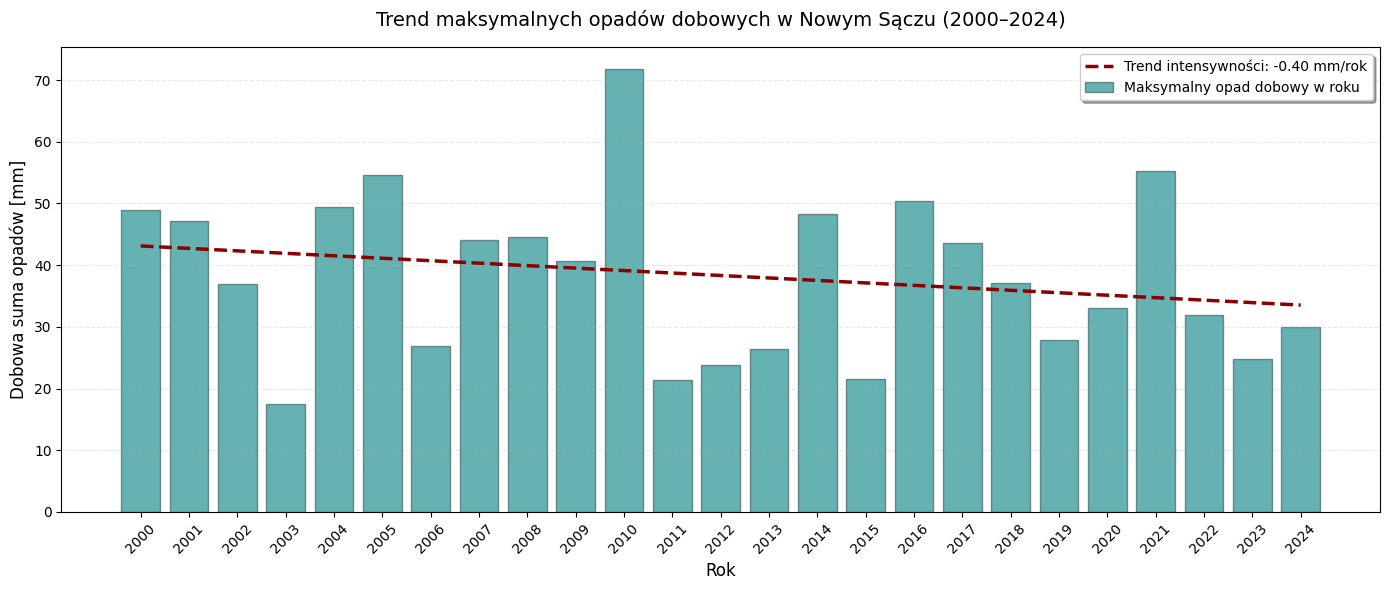

--- ANALIZA INTENSYWNOŚCI OPADÓW ---
Średnia zmiana rocznego rekordu dobowego: -0.40 mm/rok
Najwyższy odnotowany opad dobowy: 71.8 mm (rok 2010)


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression


max_daily_precip = df_daily.groupby(pd.to_datetime(df_daily.index).year)['precip_sum'].max()

# 2. Przygotowanie danych do wykresu
x = max_daily_precip.index.values
y = max_daily_precip.values

# 3. Tworzenie wykresu
plt.figure(figsize=(14, 6))

# Wykres słupkowy (rekordy opadowe)
plt.bar(x, y, color='teal', alpha=0.6, edgecolor='darkslategray',
        label='Maksymalny opad dobowy w roku')

# 4. Obliczanie trendu liniowego
X_reg = x.reshape(-1, 1)
model_precip_max = LinearRegression().fit(X_reg, y)
trend_precip_max = model_precip_max.predict(X_reg)
slope_precip_max = model_precip_max.coef_[0]

# Rysowanie linii trendu
plt.plot(x, trend_precip_max, color='darkred', linestyle='--', linewidth=2.5,
         label=f'Trend intensywności: {slope_precip_max:+.2f} mm/rok')

plt.title("Trend maksymalnych opadów dobowych w Nowym Sączu (2000–2024)", fontsize=14, pad=15)
plt.xlabel("Rok", fontsize=12)
plt.ylabel("Dobowa suma opadów [mm]", fontsize=12)

# Oś X (każdy rok)
plt.xticks(x, rotation=45)

# Dodanie siatki poziomej
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# Diagnostyka
print(f"--- ANALIZA INTENSYWNOŚCI OPADÓW ---")
print(f"Średnia zmiana rocznego rekordu dobowego: {slope_precip_max:+.2f} mm/rok")
print(f"Najwyższy odnotowany opad dobowy: {y.max():.1f} mm (rok {x[y.argmax()]})")

Wykresy wskazują na występowanie sezonowości w danych.

## Ocena liczby dni ekstremalnych

<>:26: SyntaxWarning: invalid escape sequence '\g'
<>:26: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipython-input-3455365333.py:26: SyntaxWarning: invalid escape sequence '\g'
  "heavy_rain_days": (f"Liczba dni z silnym opadem ($\geq {p95_precip:.1f}$ mm)", "seagreen")


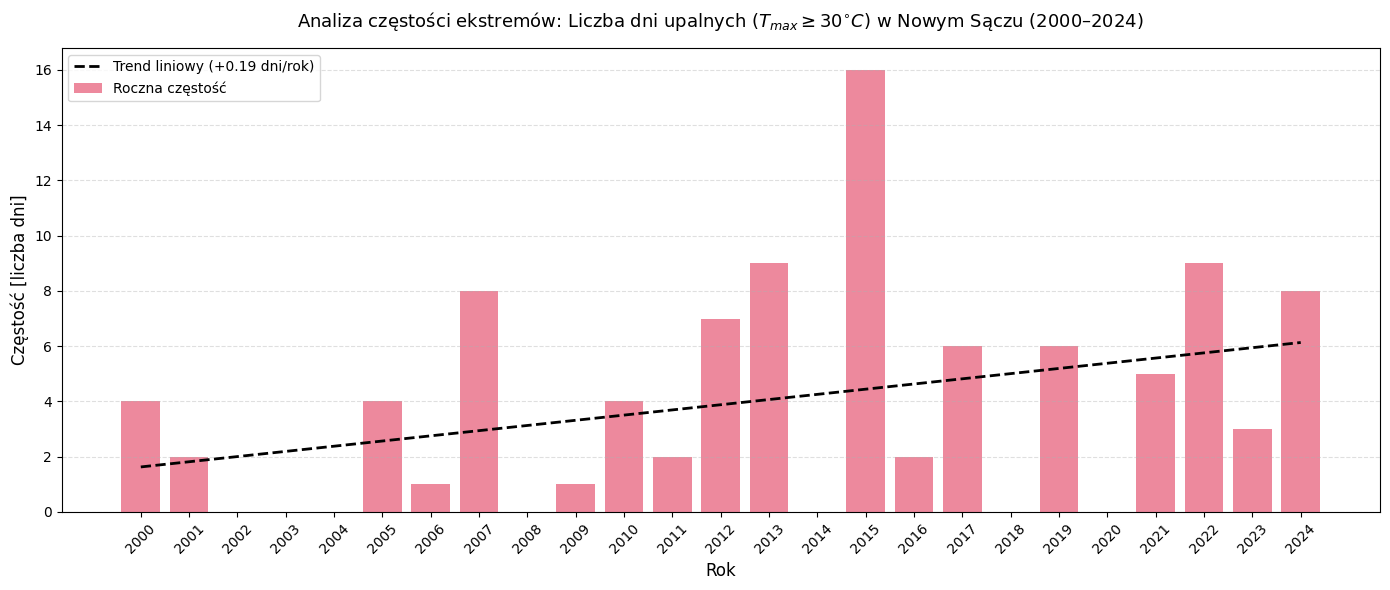

Wskaźnik hot_days wykazuje tendencję wzrostową (+0.188 dni na rok).


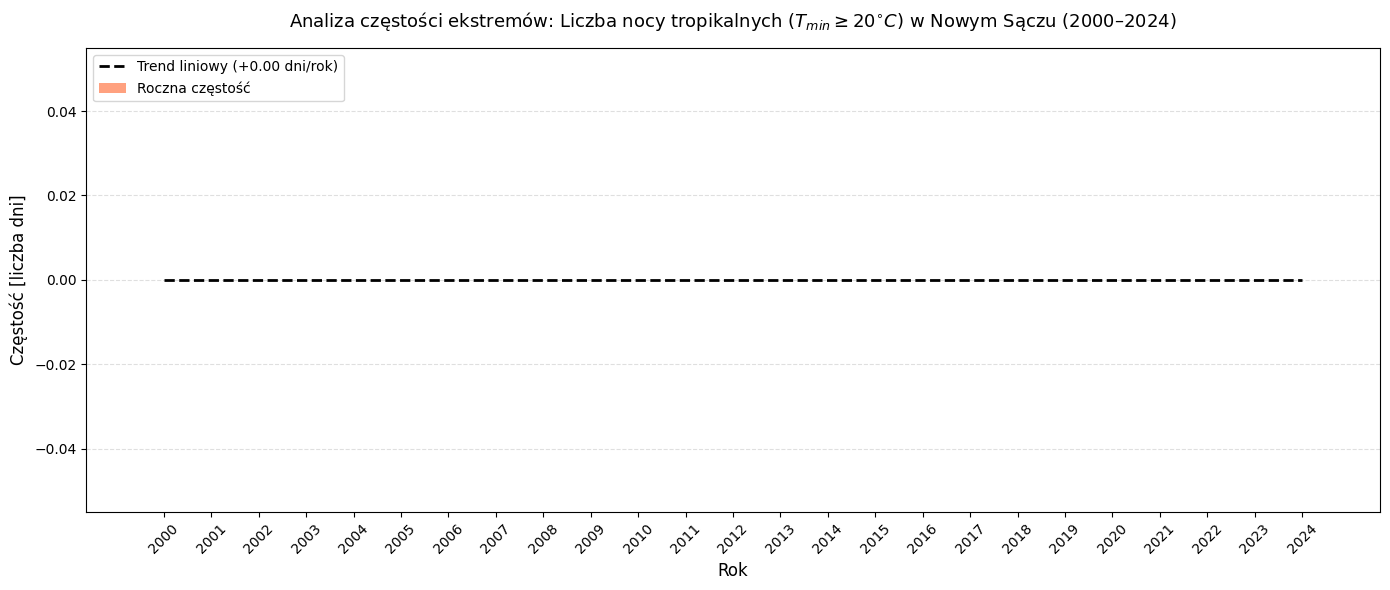

Wskaźnik tropical_nights wykazuje tendencję spadkową (+0.000 dni na rok).


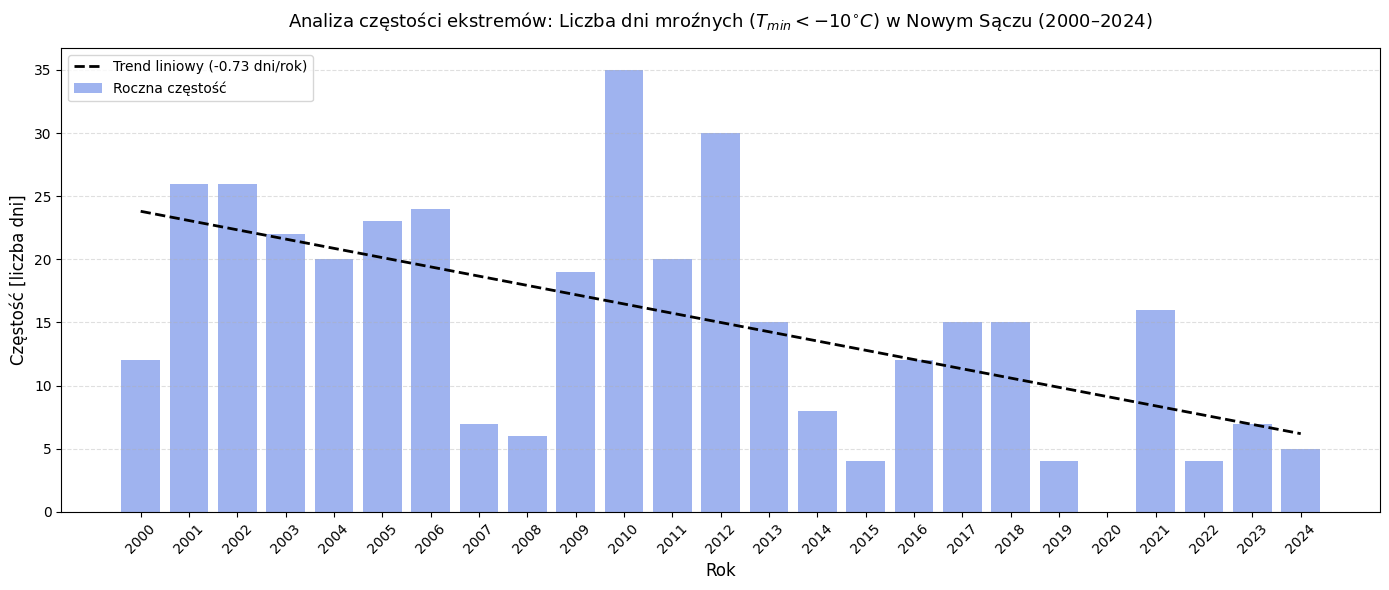

Wskaźnik frost_days wykazuje tendencję spadkową (-0.734 dni na rok).


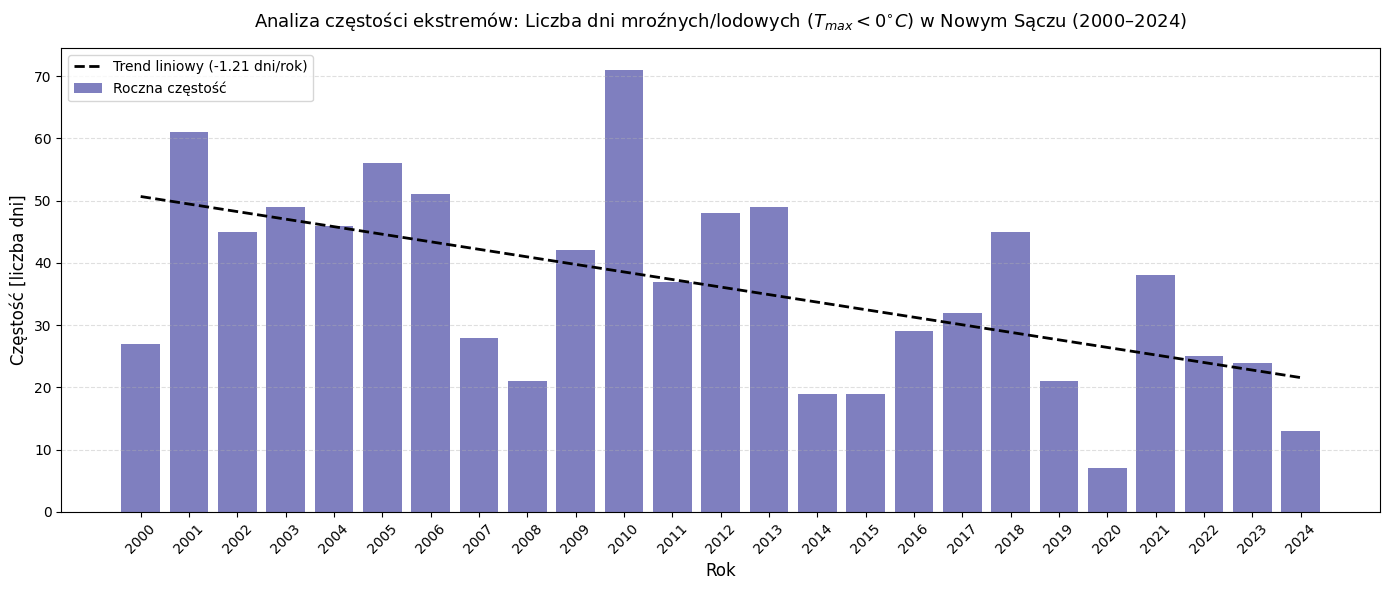

Wskaźnik ice_days wykazuje tendencję spadkową (-1.212 dni na rok).


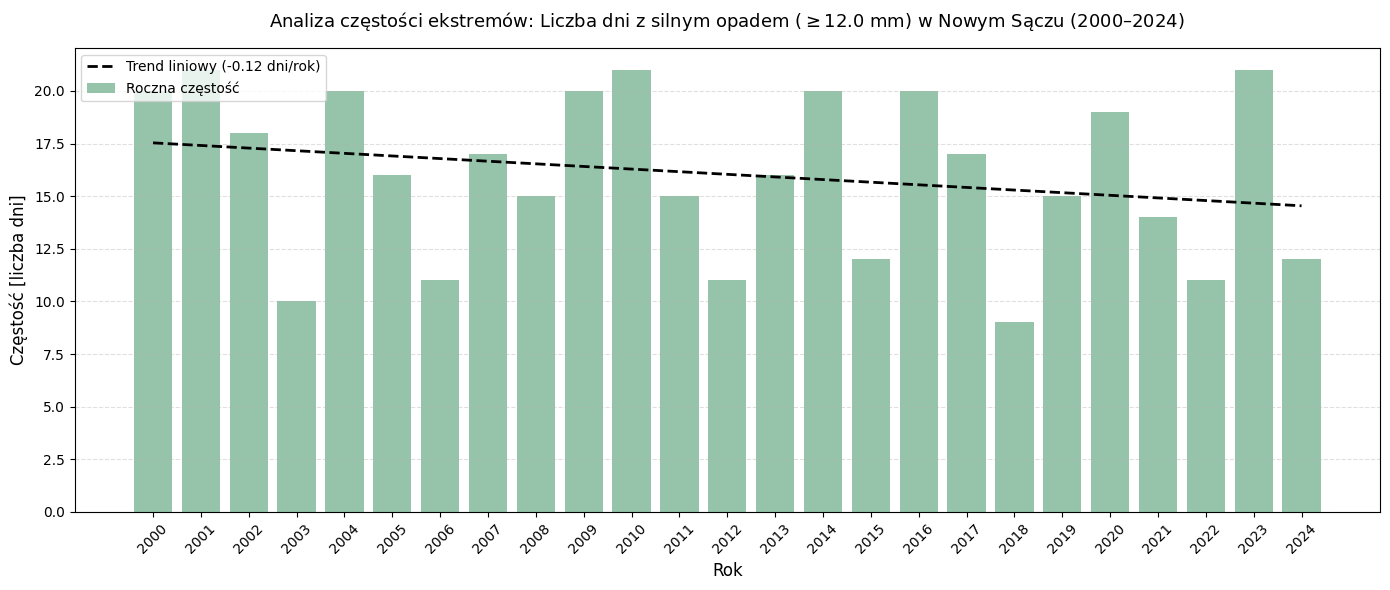

Wskaźnik heavy_rain_days wykazuje tendencję spadkową (-0.125 dni na rok).


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

years = pd.DatetimeIndex(df_daily.index).year

# 1. Obliczenie progu statystycznego dla opadów
p95_precip = round(df_daily[df_daily['precip_sum'] > 0]['precip_sum'].quantile(0.95), 0)

# 2. Agregacja roczna wskaźników ekstremalnych z użyciem wyciągniętych lat
df_extrema = df_daily.groupby(years).agg(
    hot_days=('temp_max', lambda x: (x >= 30).sum()),
    tropical_nights=('temp_min', lambda x: (x >= 20).sum()),
    frost_days=('temp_min', lambda x: (x < -10).sum()),
    ice_days=('temp_max', lambda x: (x < 0).sum()),
    heavy_rain_days=('precip_sum', lambda x: (x >= p95_precip).sum())
).rename_axis('year')

extrema_plots_info = {
    "hot_days": (r"Liczba dni upalnych ($T_{max} \geq 30^{\circ}C$)", "crimson"),
    "tropical_nights": (r"Liczba nocy tropikalnych ($T_{min} \geq 20^{\circ}C$)", "orangered"),
    "frost_days": (r"Liczba dni mroźnych ($T_{min} < -10^{\circ}C$)", "royalblue"),
    "ice_days": (r"Liczba dni mroźnych/lodowych ($T_{max} < 0^{\circ}C$)", "navy"),
    "heavy_rain_days": (f"Liczba dni z silnym opadem ($\geq {p95_precip:.1f}$ mm)", "seagreen")
}

for var, (label, color) in extrema_plots_info.items():
    plt.figure(figsize=(14, 6))
    x_axis = df_extrema.index
    y_values = df_extrema[var]

    plt.bar(x_axis, y_values, color=color, alpha=0.5, label=f"Roczna częstość")

    X = np.array(x_axis).reshape(-1, 1)
    model = LinearRegression().fit(X, y_values)
    trend = model.predict(X)
    slope = model.coef_[0]

    plt.plot(x_axis, trend, color="black", linestyle="--", linewidth=2,
             label=f"Trend liniowy ({slope:+.2f} dni/rok)")

    plt.xticks(x_axis, rotation=45)
    plt.title(f"Analiza częstości ekstremów: {label} w Nowym Sączu (2000–2024)", fontsize=13, pad=15)
    plt.xlabel("Rok", fontsize=12)
    plt.ylabel("Częstość [liczba dni]", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

    trend_desc = "wzrostową" if slope > 0 else "spadkową"
    print(f"Wskaźnik {var} wykazuje tendencję {trend_desc} ({slope:+.3f} dni na rok).")

<>:27: SyntaxWarning: invalid escape sequence '\g'
<>:27: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipython-input-1396071921.py:27: SyntaxWarning: invalid escape sequence '\g'
  label=f'Dni z przyrostem śniegu $\geq$ {p95_snow:.1f} cm')


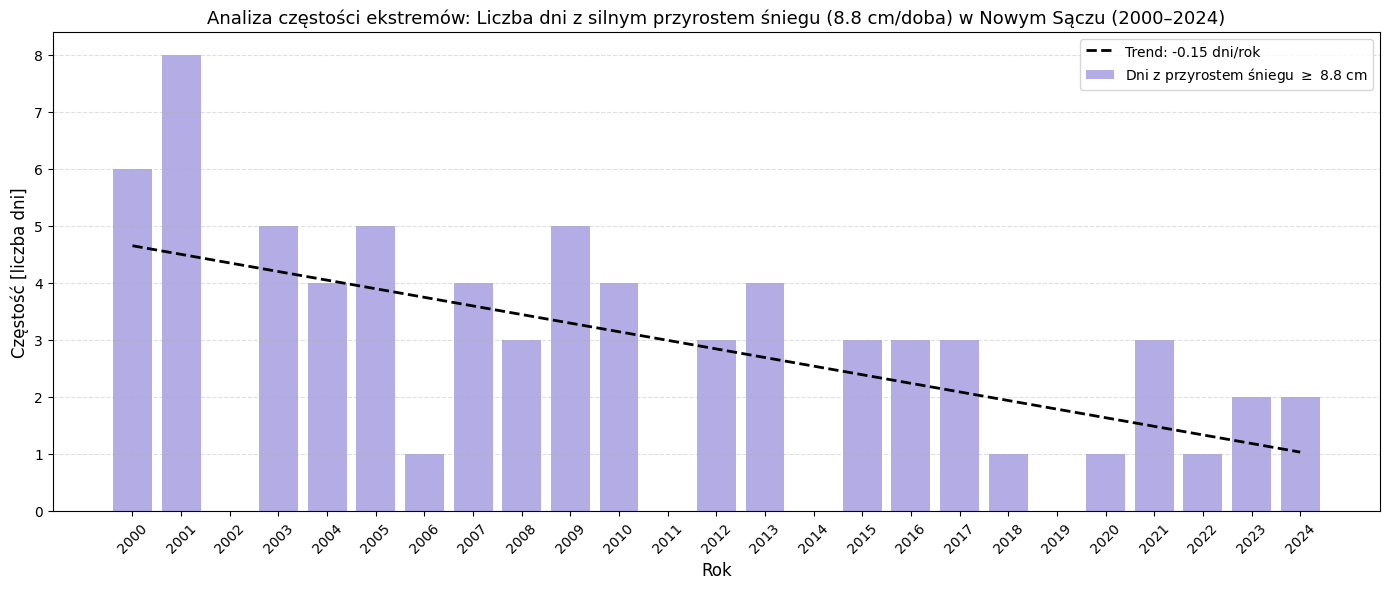

Trend ekstremalnych opadów śniegu: -0.151 dni na rok.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Obliczenie dobowego przyrostu pokrywy śnieżnej (nowy śnieg)
# Używamy diff(), aby zobaczyć o ile cm przybyło śniegu z dnia na dzień
df_daily['snow_fall'] = df_daily['snow_depth_max'].diff().fillna(0)
# Interesują nas tylko wartości dodatnie (kiedy śniegu przybyło, a nie stopniał)
df_daily['snow_fall'] = df_daily['snow_fall'].clip(lower=0)

# 2. Wyznaczenie progu ekstremalnego opadu śniegu (95. percentyl dla dni z przyrostem)
p95_snow = df_daily[df_daily['snow_fall'] > 0]['snow_fall'].quantile(0.95)

# 3. Agregacja roczna - liczba dni z ekstremalnym opadem śniegu
years = pd.DatetimeIndex(df_daily.index).year
extreme_snow_days = df_daily.groupby(years).agg(
    extreme_snow_count=('snow_fall', lambda x: (x >= p95_snow).sum())
)

# 4. Wykres
plt.figure(figsize=(14, 6))
x_axis = extreme_snow_days.index
y_values = extreme_snow_days['extreme_snow_count']

plt.bar(x_axis, y_values, color='slateblue', alpha=0.5,
        label=f'Dni z przyrostem śniegu $\geq$ {p95_snow:.1f} cm')

# Trend
X = np.array(x_axis).reshape(-1, 1)
model = LinearRegression().fit(X, y_values)
slope = model.coef_[0]

plt.plot(x_axis, model.predict(X), color="black", linestyle="--", linewidth=2,
         label=f"Trend: {slope:+.2f} dni/rok")

plt.title(f"Analiza częstości ekstremów: Liczba dni z silnym przyrostem śniegu ({p95_snow:.1f} cm/doba) w Nowym Sączu (2000–2024)", fontsize=13)
plt.xlabel("Rok", fontsize=12)
plt.ylabel("Częstość [liczba dni]", fontsize=12)
plt.xticks(x_axis, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Trend ekstremalnych opadów śniegu: {slope:+.3f} dni na rok.")

# # 1. Wyznaczenie progu silnego wiatru (95. percentyl z danych dziennych)
# p95_wind = round(df_daily['wind_speed_mean'].quantile(0.95), 1)

# # 2. Agregacja roczna - liczba dni z silnym wiatrem
# years = pd.DatetimeIndex(df_daily.index).year
# wind_extrema = df_daily.groupby(years).agg(
#     strong_wind_days=('wind_speed_mean', lambda x: (x >= p95_wind).sum())
# ).rename_axis('year')

# # 3. Wykres
# plt.figure(figsize=(14, 6))
# x_axis = wind_extrema.index
# y_values = wind_extrema['strong_wind_days']

# plt.bar(x_axis, y_values, color='lightgray', alpha=0.6, edgecolor='dimgray',
#         label=f'Dni z wiatrem $\geq$ {p95_wind} m/s')

# # Trend
# X = np.array(x_axis).reshape(-1, 1)
# model = LinearRegression().fit(X, y_values)
# slope = model.coef_[0]

# plt.plot(x_axis, model.predict(X), color="black", linestyle="--", linewidth=2,
#          label=f"Trend: {slope:+.2f} dni/rok")

# plt.title(f"Częstotliwość występowania silnego wiatru w Nowym Sączu (Próg P95: {p95_wind} m/s)", fontsize=13)
# plt.xlabel("Rok")
# plt.ylabel("Liczba dni w roku")
# plt.xticks(x_axis, rotation=45)
# plt.grid(axis='y', linestyle='--', alpha=0.4)
# plt.legend()
# plt.tight_layout()
# plt.show()

# print(f"Trend silnego wiatru: {slope:+.3f} dni na rok.")

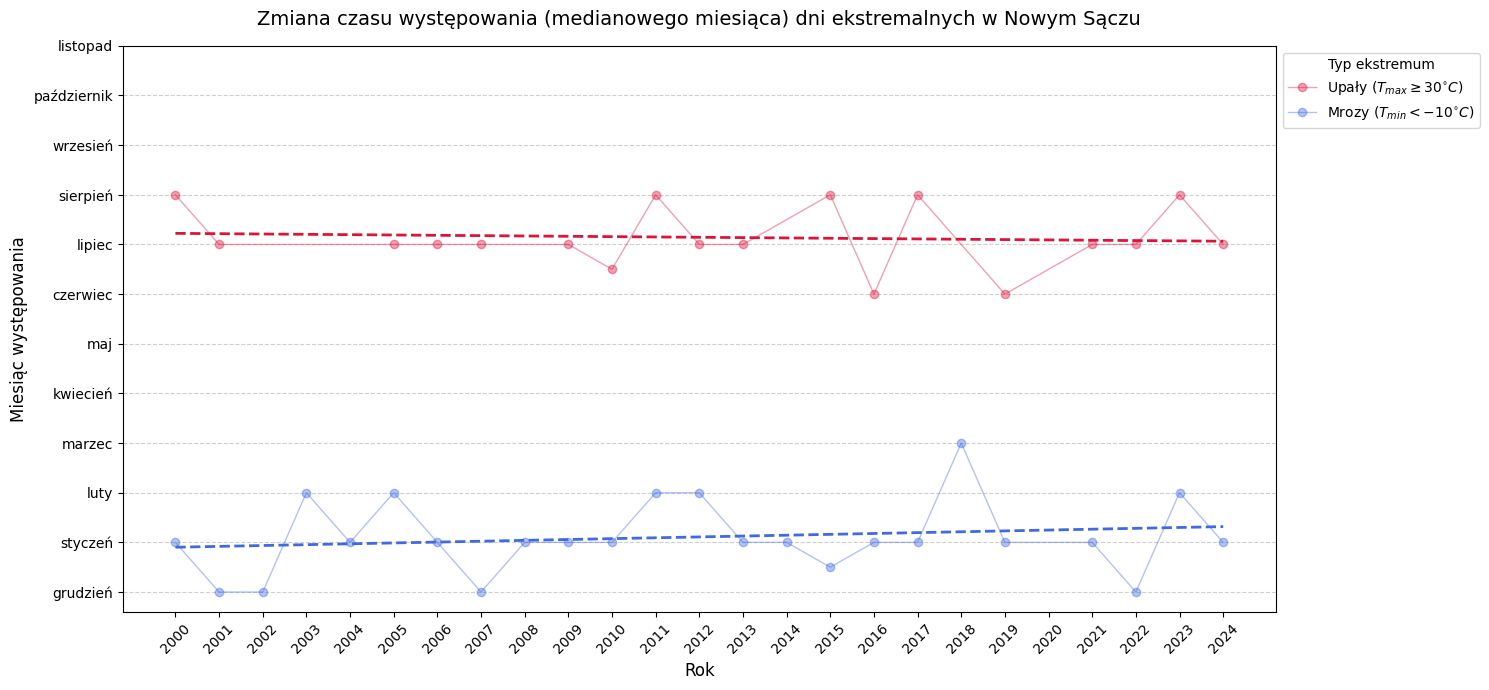

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

temp_index = pd.DatetimeIndex(df_daily.index)

df_daily['month_shift'] = temp_index.month
df_daily['month_shift'] = df_daily['month_shift'].replace(12, 0)

# Definiujemy ekstrema
df_daily['extreme_heat'] = (df_daily['temp_max'] >= 30).astype(int)
df_daily['extreme_cold'] = (df_daily['temp_min'] < -10).astype(int)

# Wyciągamy rok do grupowania
df_daily['year_val'] = temp_index.year

#Obliczanie centralnego miesiąca występowania ekstremów
monthly_extremes_trend = pd.DataFrame({
    'heat': df_daily[df_daily['extreme_heat'] == 1].groupby('year_val')['month_shift'].median(),
    'cold': df_daily[df_daily['extreme_cold'] == 1].groupby('year_val')['month_shift'].median()
})

#Generowanie wykresu
plt.figure(figsize=(15, 7))

plot_cfg = [
    ('heat', 'crimson', r'Upały ($T_{max} \geq 30^{\circ}C$)'),
    ('cold', 'royalblue', r'Mrozy ($T_{min} < -10^{\circ}C$)')
]

for col, color, label in plot_cfg:
    data_subset = monthly_extremes_trend[col].dropna()
    x_years = data_subset.index
    y_months = data_subset.values

    plt.plot(x_years, y_months, marker='o', markersize=6, linestyle='-',
             linewidth=1, alpha=0.4, color=color, label=label)

    if len(y_months) > 1:
        X = np.array(x_years).reshape(-1, 1)
        model = LinearRegression().fit(X, y_months)
        trend = model.predict(X)
        plt.plot(x_years, trend, color=color, linestyle='--', linewidth=2)

plt.title("Zmiana czasu występowania (medianowego miesiąca) dni ekstremalnych w Nowym Sączu", fontsize=14, pad=15)
plt.xlabel("Rok", fontsize=12)
plt.ylabel("Miesiąc występowania", fontsize=12)

all_years = sorted(df_daily['year_val'].unique())
plt.xticks(all_years, rotation=45)

plt.yticks(list(range(0, 12)),
           labels=['grudzień', 'styczeń', 'luty', 'marzec', 'kwiecień', 'maj',
                   'czerwiec', 'lipiec', 'sierpień', 'wrzesień', 'październik', 'listopad'])

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Typ ekstremum")
plt.tight_layout()
plt.show()

Trend dla "Heat" (Upały): Jeśli linia trendu opada, oznacza to, że medianowy dzień upalny przesuwa się z sierpnia na lipiec lub czerwiec. To sygnał wcześniejszego nadejścia lata termicznego.

Trend dla "Cold" (Mrozy): Jeśli linia trendu rośnie (np. z 1 na 2), oznacza to, że najsilniejsze mrozy przesuwają się ze stycznia na luty – co sugeruje opóźnienie zimy.

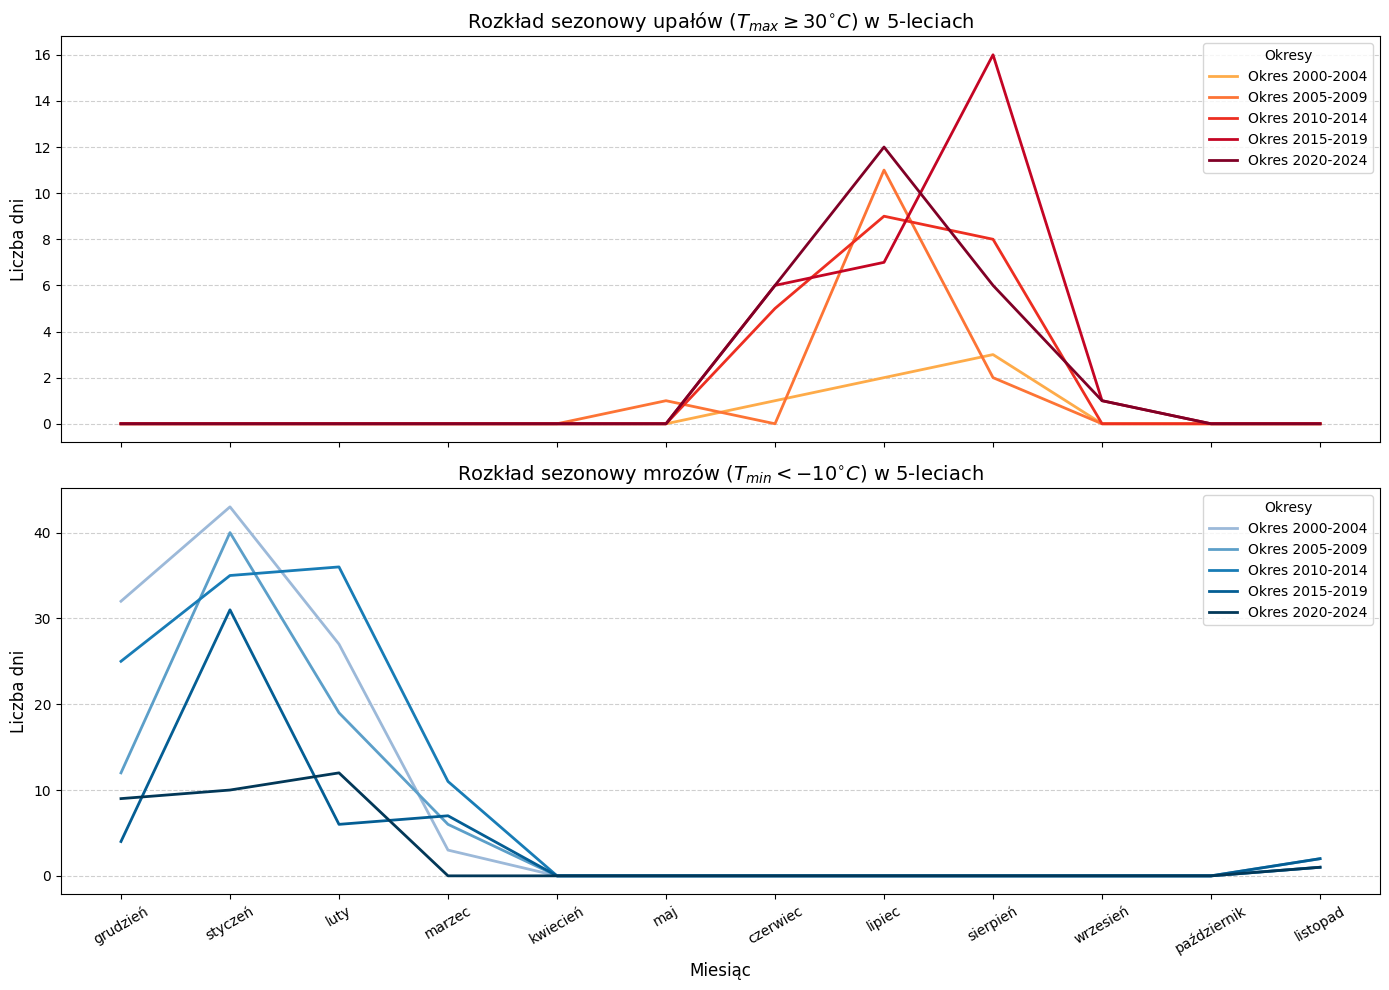

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

temp_index = pd.DatetimeIndex(df_daily.index)


df_daily['month_shift'] = temp_index.month
df_daily['month_shift'] = df_daily['month_shift'].replace(12, 0)


df_daily['extreme_heat'] = (df_daily['temp_max'] >= 30).astype(int)
df_daily['extreme_cold'] = (df_daily['temp_min'] < -10).astype(int)

# Definicja okresów 5-letnich
start_year = temp_index.year.min()
end_year = temp_index.year.max()
# Tworzymy przedziały co 5 lat
bins = list(range(start_year, end_year + 6, 5))
labels = [f"{b}-{b+4}" for b in bins[:-1]]
df_daily['5y_period'] = pd.cut(temp_index.year, bins=bins, labels=labels, right=False)

# Agregacja - sumujemy liczbę dni ekstremalnych w każdym miesiącu dla danego 5-lecia
monthly_extremes = df_daily.groupby(['5y_period','month_shift'], observed=False).agg({
    'extreme_heat': 'sum',
    'extreme_cold': 'sum'
}).reset_index()

# --- 2. Tworzenie wykresu z dwoma panelami (Subplots) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Palety kolorów (gradienty od jasnych do ciemnych kolorów wraz z upływem czasu)
colors_heat = plt.cm.YlOrRd(np.linspace(0.4, 1, len(labels)))
colors_cold = plt.cm.PuBu(np.linspace(0.4, 1, len(labels)))

month_labels = ['grudzień','styczeń','luty','marzec','kwiecień','maj',
                'czerwiec','lipiec','sierpień','wrzesień','październik','listopad']

for i, period in enumerate(labels):
    period_data = monthly_extremes[monthly_extremes['5y_period'] == period]

    # Sortujemy po month_shift, aby linie na wykresie były ciągłe i poprawne
    period_data = period_data.sort_values('month_shift')

    # Panel 1: Upały
    ax1.plot(period_data['month_shift'], period_data['extreme_heat'],
             color=colors_heat[i], linewidth=2, label=f"Okres {period}")

    # Panel 2: Mrozy
    ax2.plot(period_data['month_shift'], period_data['extreme_cold'],
             color=colors_cold[i], linewidth=2, label=f"Okres {period}")

# Stylizacja Panelu 1 (Upały)
ax1.set_title(r"Rozkład sezonowy upałów ($T_{max} \geq 30^{\circ}C$) w 5-leciach", fontsize=14)
ax1.set_ylabel("Liczba dni", fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.legend(title="Okresy", loc='upper right', bbox_to_anchor=(1, 1))

# Stylizacja Panelu 2 (Mrozy)
ax2.set_title(r"Rozkład sezonowy mrozów ($T_{min} < -10^{\circ}C$) w 5-leciach", fontsize=14)
ax2.set_ylabel("Liczba dni", fontsize=12)
ax2.set_xlabel("Miesiąc", fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.legend(title="Okresy", loc='upper right', bbox_to_anchor=(1, 1))

# Ustawienia osi X dla obu paneli
plt.xticks(range(0, 12), labels=month_labels, rotation=30)

plt.tight_layout()
plt.show()

1. Rozkład sezonowy upałów ($T_{max} \geq 30^{\circ}C$)Wzrost intensywności: Najciemniejsza linia (okres 2015–2019 oraz 2020–2024) znajduje się wyraźnie powyżej linii z początku wieku (jasnopomarańczowych). Wskazuje to na drastyczny wzrost liczby dni upalnych.Ekstremum w sierpniu: Wykres pokazuje, że szczyt upałów przesunął się lub zintensyfikował w sierpniu. Rekordowy wynik (ponad 16 dni w jednym 5-leciu dla sierpnia) sugeruje, że co trzeci dzień sierpnia w tym okresie był upalny.Rozszerzenie sezonu: Zauważ, że w ostatnich latach upały zaczęły pojawiać się już w czerwcu (widoczny "skok" ciemnej linii), co świadczy o wydłużaniu się termicznego lata.2. Rozkład sezonowy mrozów ($T_{min} < -10^{\circ}C$)Zanikanie ostrej zimy: Tutaj trend jest odwrotny i bardzo wyraźny. Najjaśniejsza linia (2000–2004) dominuje na wykresie, co oznacza, że kiedyś dni z silnym mrozem było znacznie więcej (nawet ponad 40 w styczniu w skali 5-lecia).Spadek o ponad 70%: Najciemniejsza linia (2020–2024) szoruje niemal po dnie wykresu. Liczba dni z mrozem poniżej $-10^{\circ}C$ spadła w styczniu z poziomu ok. 43 dni do zaledwie 10 dni (suma dla 5 lat). To potężny sygnał ocieplenia zim.Stabilizacja wczesnej wiosny: Marzec, który kiedyś regularnie przynosił silne mrozy (jasnoniebieskie linie), w ostatnim 5-leciu niemal całkowicie się ich pozbył (wartość bliska 0).

## Obliczanie anomalii względem okresu referencyjnego


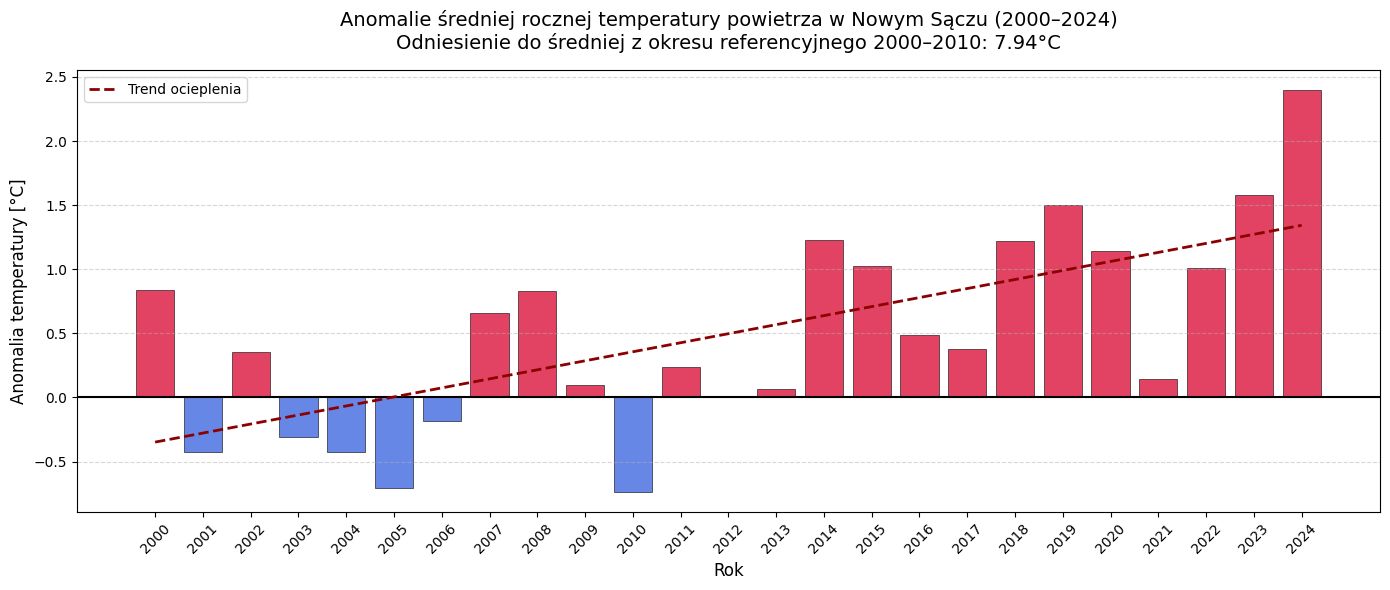

Najwyższa anomalia: +2.40°C w roku 2024


In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Obliczenie normy klimatycznej (średnia z lat 2000-2010)
norma_reference = df_annual.loc[2000:2010, 'temp_mean'].mean()

# 2. Obliczenie anomalii (różnica między rokiem a normą)
df_annual['anomaly'] = df_annual['temp_mean'] - norma_reference

# 3. Przygotowanie kolorów (czerwony dla dodatnich, niebieski dla ujemnych anomalii)
colors = ['crimson' if x > 0 else 'royalblue' for x in df_annual['anomaly']]

# 4. Generowanie wykresu
plt.figure(figsize=(14, 6))
bars = plt.bar(df_annual.index, df_annual['anomaly'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# Dodanie linii zerowej (normy)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')

# Używamy indeksu z df_annual, który już jest latami (int)
X = np.array(df_annual.index).reshape(-1, 1)
y = df_annual['anomaly'].values
model = LinearRegression().fit(X, y)
trend = model.predict(X)
plt.plot(df_annual.index, trend, color='darkred', linestyle='--', linewidth=2, label='Trend ocieplenia')

plt.title(f"Anomalie średniej rocznej temperatury powietrza w Nowym Sączu (2000–2024)\nOdniesienie do średniej z okresu referencyjnego 2000–2010: {norma_reference:.2f}°C", fontsize=14, pad=15)
plt.xlabel("Rok", fontsize=12)
plt.ylabel("Anomalia temperatury [°C]", fontsize=12)

# Każdy rok na osi X
plt.xticks(df_annual.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Najwyższa anomalia: {df_annual['anomaly'].max():+.2f}°C w roku {df_annual['anomaly'].idxmax()}")

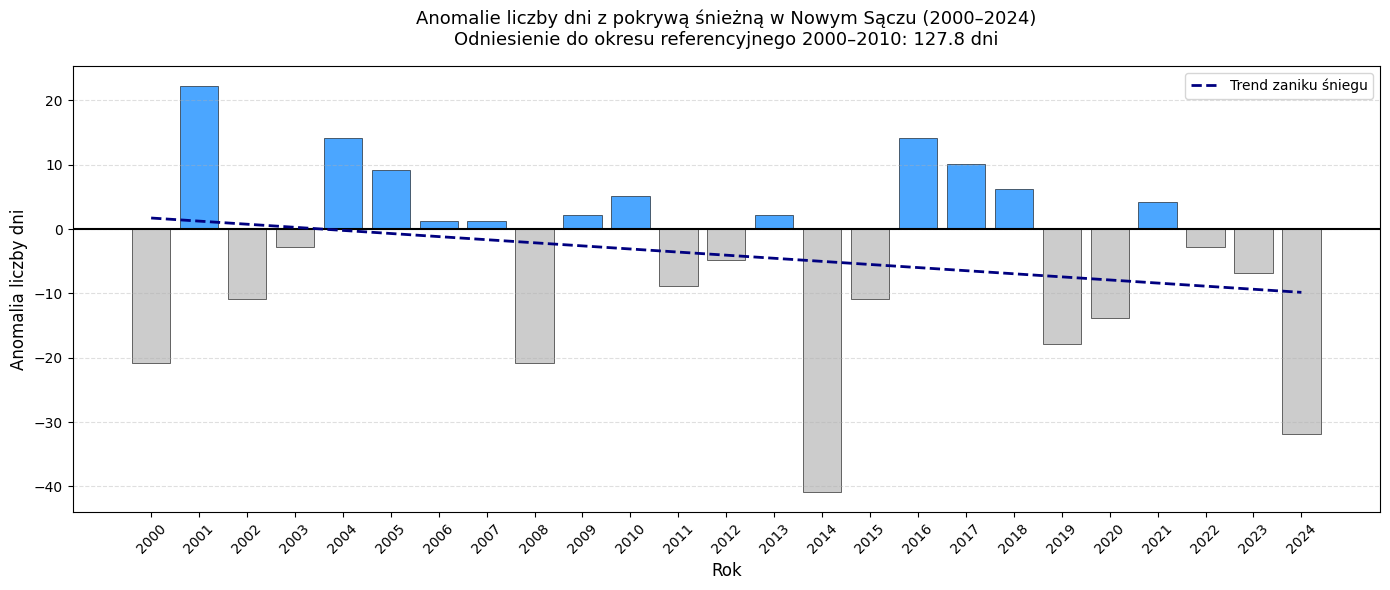

Średnia zmiana liczby dni ze śniegiem: -0.48 dni/rok


In [25]:
# 1. Obliczenie normy dni śnieżnych (2000-2010)
norma_snow = df_annual.loc[2000:2010, 'snow_days_count'].mean()
df_annual['snow_anomaly'] = df_annual['snow_days_count'] - norma_snow

# 2. Przygotowanie kolorów
colors_s = ['dodgerblue' if x > 0 else 'silver' for x in df_annual['snow_anomaly']]

# 3. Wykres
plt.figure(figsize=(14, 6))
plt.bar(df_annual.index, df_annual['snow_anomaly'], color=colors_s, alpha=0.8, edgecolor='black', linewidth=0.5)
plt.axhline(0, color='black', linewidth=1.5)

# Trend śniegu
y_s = df_annual['snow_anomaly'].values
model_s = LinearRegression().fit(X, y_s)
plt.plot(df_annual.index, model_s.predict(X), color='navy', linestyle='--', linewidth=2, label='Trend zaniku śniegu')

plt.title(f"Anomalie liczby dni z pokrywą śnieżną w Nowym Sączu (2000–2024)\nOdniesienie do okresu referencyjnego 2000–2010: {norma_snow:.1f} dni", fontsize=13, pad=15)
plt.ylabel("Anomalia liczby dni", fontsize=12)
plt.xlabel("Rok", fontsize=12)
plt.xticks(df_annual.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Średnia zmiana liczby dni ze śniegiem: {model_s.coef_[0]:+.2f} dni/rok")

## Sprawdzenie przesunięć sezonów

### Analiza długości termicznego lata i zimy

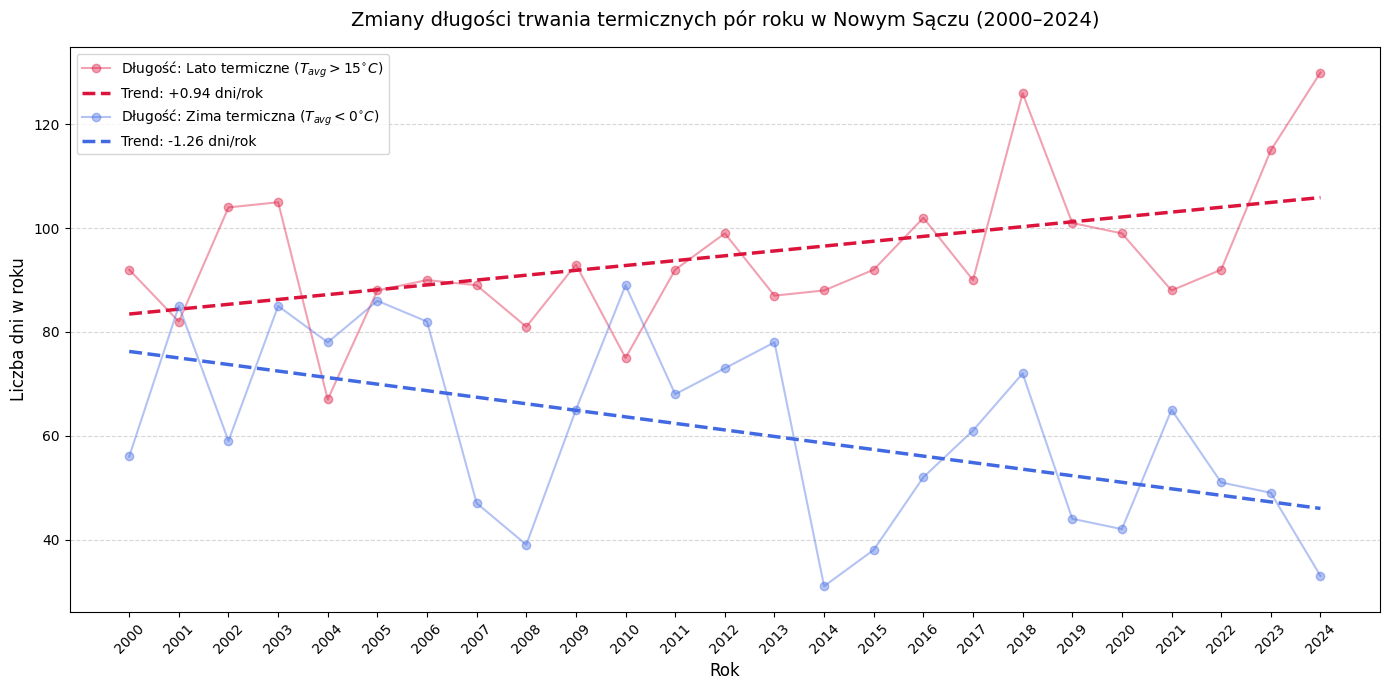

Średnia zmiana długości lata: +0.94 dni/rok


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

df_daily.index = pd.to_datetime(df_daily.index)

# 1. Definicja sezonów termicznych na podstawie temperatury średniej
df_daily['is_thermal_summer'] = df_daily['temp_mean'] > 15
df_daily['is_thermal_winter'] = df_daily['temp_mean'] < 0

# 2. Agregacja roczna - liczba dni trwania sezonu
season_duration = df_daily.groupby(df_daily.index.year).agg(
    summer_length=('is_thermal_summer', 'sum'),
    winter_length=('is_thermal_winter', 'sum')
)

# 3. Wizualizacja zmian długości sezonów
plt.figure(figsize=(14, 7))

# Konfiguracja danych do wykresu
seasons = [
    ('summer_length', 'crimson', r'Lato termiczne ($T_{avg} > 15^{\circ}C$)'),
    ('winter_length', 'royalblue', r'Zima termiczna ($T_{avg} < 0^{\circ}C$)')
]

for col, color, label in seasons:
    x = season_duration.index
    y = season_duration[col]

    # Wykres punktowy z linią
    plt.plot(x, y, marker='o', linestyle='-', color=color, alpha=0.4, label=f"Długość: {label}")

    # Obliczanie trendu liniowego
    X_reg = np.array(x).reshape(-1, 1)
    model = LinearRegression().fit(X_reg, y)
    trend = model.predict(X_reg)
    slope = model.coef_[0]

    plt.plot(x, trend, color=color, linestyle='--', linewidth=2.5,
             label=f"Trend: {slope:+.2f} dni/rok")

plt.title("Zmiany długości trwania termicznych pór roku w Nowym Sączu (2000–2024)", fontsize=14, pad=15)
plt.xlabel("Rok", fontsize=12)
plt.ylabel("Liczba dni w roku", fontsize=12)
plt.xticks(season_duration.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))

plt.tight_layout()
plt.show()

# Ponowne przeliczenie trendu lata do printa
model_summer = LinearRegression().fit(np.array(season_duration.index).reshape(-1, 1), season_duration['summer_length'])
print(f"Średnia zmiana długości lata: {model_summer.coef_[0]:+.2f} dni/rok")

### Analiza daty rozpoczęcia termicznego lata i zimy

<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-3539387369.py:32: SyntaxWarning: invalid escape sequence '\c'
  (start_summer, 'crimson', 'darkred', 'Start lata ($T_{avg} > 15^{\circ}C$)'),
/tmp/ipython-input-3539387369.py:33: SyntaxWarning: invalid escape sequence '\c'
  (start_winter, 'royalblue', 'navy', 'Start zimy ($T_{avg} < 0^{\circ}C$)')


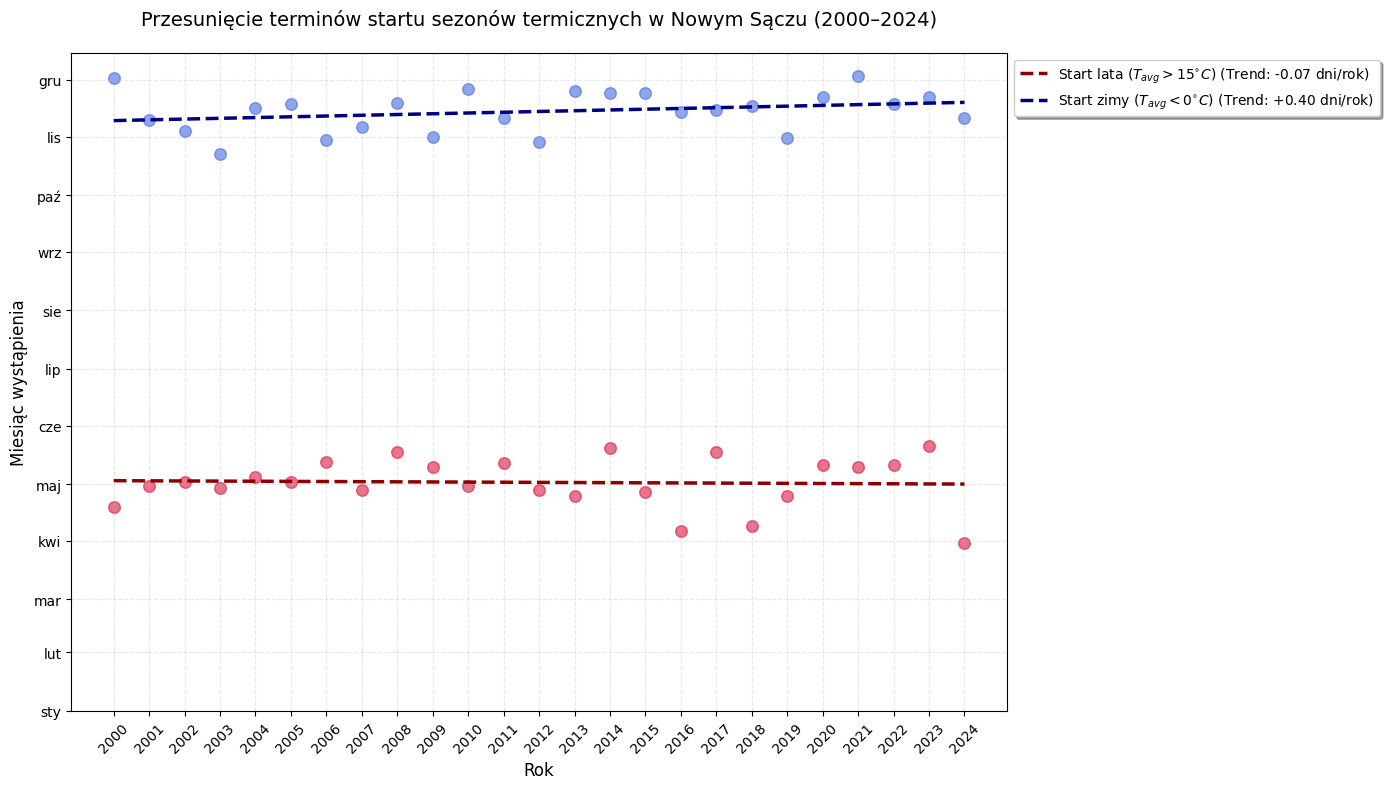

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- 1. Przygotowanie danych ---
temp_index = pd.DatetimeIndex(df_daily.index)

def get_first_day_doy(group, threshold, condition='above'):
    if condition == 'above':
        days = group[group['temp_mean'] > threshold]
    else:
        days = group[group['temp_mean'] < threshold]
    if not days.empty:
        return pd.to_datetime(days.index).dayofyear.min()
    return np.nan

# Obliczenia startów
start_summer = df_daily.groupby(temp_index.year).apply(get_first_day_doy, threshold=15, condition='above')
winter_data = df_daily[temp_index.month >= 7]
start_winter = winter_data.groupby(pd.DatetimeIndex(winter_data.index).year).apply(get_first_day_doy, threshold=0, condition='below')

# --- 2. Wizualizacja na jednym wykresie ---
plt.figure(figsize=(14, 8))

# Definicja osi Y (Miesiące)
month_days = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_names = ['sty', 'lut', 'mar', 'kwi', 'maj', 'cze', 'lip', 'sie', 'wrz', 'paź', 'lis', 'gru']

# Dane do pętli wizualizacyjnej
datasets = [
    (start_summer, 'crimson', 'darkred', 'Start lata ($T_{avg} > 15^{\circ}C$)'),
    (start_winter, 'royalblue', 'navy', 'Start zimy ($T_{avg} < 0^{\circ}C$)')
]

for data, dot_color, line_color, label in datasets:
    valid_data = data.dropna()
    x = valid_data.index
    y = valid_data.values

    # Punkty danych
    plt.scatter(x, y, color=dot_color, s=70, alpha=0.6)

    # Trend liniowy
    X_reg = np.array(x).reshape(-1, 1)
    model = LinearRegression().fit(X_reg, y)
    slope = model.coef_[0]
    plt.plot(x, model.predict(X_reg), color=line_color, linestyle='--', linewidth=2.5,
             label=f'{label} (Trend: {slope:+.2f} dni/rok)')

# Stylizacja
plt.title("Przesunięcie terminów startu sezonów termicznych w Nowym Sączu (2000–2024)", fontsize=14, pad=20)
plt.ylabel("Miesiąc wystąpienia", fontsize=12)
plt.xlabel("Rok", fontsize=12)

# Ustawienie osi Y na nazwy miesięcy
plt.yticks(month_days, labels=month_names)
plt.xticks(start_summer.index, rotation=45)

plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### Analiza najdłuższych ciągów dni mroźnych w roku

/tmp/ipython-input-505276913.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return series.groupby((series != series.shift()).cumsum()).sum().max()


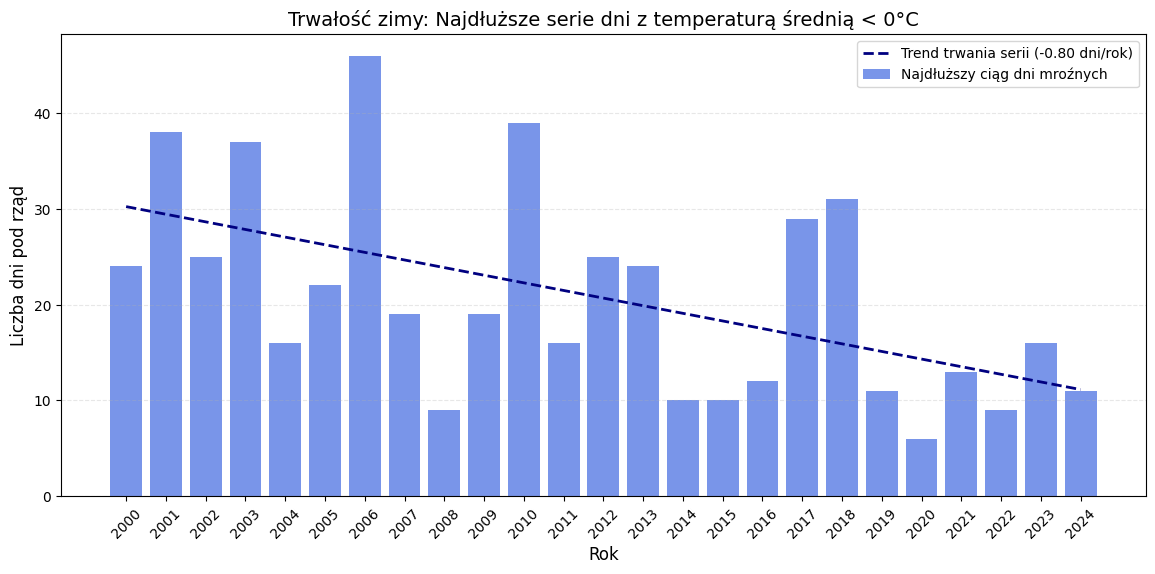

In [28]:
# 1. Funkcja pomocnicza do liczenia maksymalnego ciągu wystąpień
def max_consecutive(series):
    # Tworzymy grupy kolejnych dni o tej samej wartości
    return series.groupby((series != series.shift()).cumsum()).sum().max()

# 2. Obliczanie najdłuższego ciągu dni zimowych (Tavg < 0) w każdym roku
winter_streaks = df_daily.groupby(df_daily.index.year)['is_thermal_winter'].apply(max_consecutive)

# 3. Wizualizacja
plt.figure(figsize=(14, 6))
plt.bar(winter_streaks.index, winter_streaks.values, color='royalblue', alpha=0.7, label='Najdłuższy ciąg dni mroźnych')

# Linia trendu dla ciągłości zimy
X_streak = np.array(winter_streaks.index).reshape(-1, 1)
model_streak = LinearRegression().fit(X_streak, winter_streaks.values)
plt.plot(winter_streaks.index, model_streak.predict(X_streak), color='navy', linestyle='--', linewidth=2,
         label=f'Trend trwania serii ({model_streak.coef_[0]:+.2f} dni/rok)')

plt.title("Trwałość zimy: Najdłuższe serie dni z temperaturą średnią < 0°C", fontsize=14)
plt.xlabel("Rok", fontsize=12)
plt.ylabel("Liczba dni pod rząd", fontsize=12)
plt.xticks(winter_streaks.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()
plt.show()

Dlaczego ta analiza jest ważna dla przesunięć sezonów?
Defragmentacja zimy: Nawet jeśli całkowita liczba dni mroźnych w roku spadnie o 10, to jeśli najdłuższy ciąg spadnie z 30 dni do 10, oznacza to całkowitą zmianę charakteru pory roku. Zima z "trwałej" staje się "epizodyczna".

Wpływ na glebę: Długie ciągi mrozu powodują głębokie przemarzanie gruntu. Ich skracanie się wpływa na retencję wody i wegetację wiosenną (przesunięcie startu roślin).

Diagnostyka ML: Ten wskaźnik (najdłuższa seria) jest świetnym kandydatem na zmienną opisującą stabilność klimatu w Twoim modelu.

### Analiza najdłuższych serii upałów w roku

/tmp/ipython-input-2156790722.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  streaks = series.groupby((series != series.shift()).cumsum()).sum()


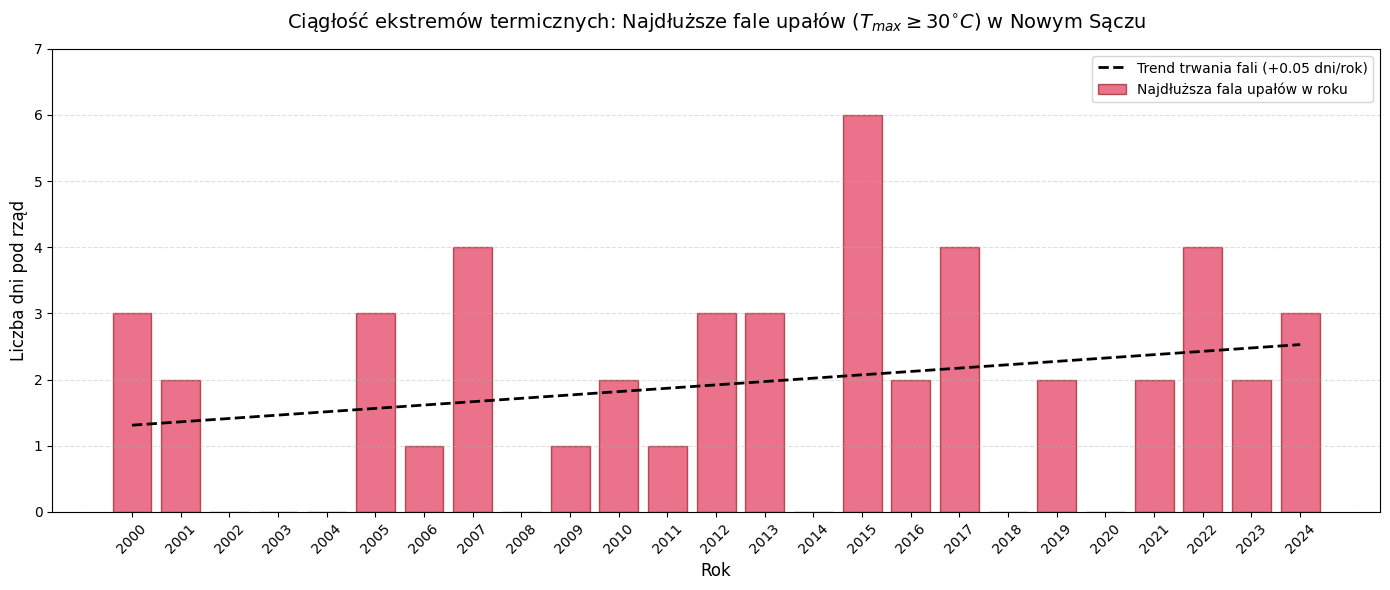

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Funkcja pomocnicza do liczenia maksymalnego ciągu (streak)
def get_max_heat_streak(series):
    # Grupowanie kolejnych dni, gdzie warunek (Tmax >= 30) jest spełniony
    # (series != series.shift()).cumsum() tworzy unikalny identyfikator dla każdego bloku
    streaks = series.groupby((series != series.shift()).cumsum()).sum()
    return streaks.max()

# 2. Przygotowanie flagi upału i obliczenie najdłuższych ciągów rocznych
df_daily['is_hot_day'] = df_daily['temp_max'] >= 30
heat_streaks = df_daily.groupby(df_daily.index.year)['is_hot_day'].apply(get_max_heat_streak)

# 3. Wizualizacja
plt.figure(figsize=(14, 6))

# Wykres słupkowy
plt.bar(heat_streaks.index, heat_streaks.values, color='crimson', alpha=0.6,
        edgecolor='darkred', label='Najdłuższa fala upałów w roku')

# Dodanie linii trendu
X_trend = np.array(heat_streaks.index).reshape(-1, 1)
y_trend = heat_streaks.values
model_heat = LinearRegression().fit(X_trend, y_trend)
plt.plot(heat_streaks.index, model_heat.predict(X_trend), color='black',
         linestyle='--', linewidth=2, label=f'Trend trwania fali ({model_heat.coef_[0]:+.2f} dni/rok)')

plt.title(r"Ciągłość ekstremów termicznych: Najdłuższe fale upałów ($T_{max} \geq 30^{\circ}C$) w Nowym Sączu",
          fontsize=14, pad=15)
plt.xlabel("Rok", fontsize=12)
plt.ylabel("Liczba dni pod rząd", fontsize=12)

plt.xticks(heat_streaks.index, rotation=45)
plt.yticks(range(0, int(heat_streaks.max()) + 2))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

Wydłużanie się fal: Jeśli nachylenie linii trendu (slope) jest dodatnie, oznacza to, że fale upałów w Nowym Sączu stają się nie tylko częstsze (co pokazały wcześniejsze wykresy), ale przede wszystkim bardziej trwałe.

Wpływ na miasto: Dłuższe fale upałów potęgują efekt miejskiej wyspy ciepła i prowadzą do suszy glebowej, ponieważ parowanie (ewapotranspiracja) zachodzi przez wiele dni bez przerwy.

Wnioski dla ML: Długość najdłuższej fali upałów to doskonała zmienna do analizy ryzyka klimatycznego. Model ML może na tej podstawie oceniać prawdopodobieństwo wystąpienia tzw. "lat ekstremalnych", które odbiegają od normy statystycznej.

Przyspieszenie lata (Start Lata):

Jeśli współczynnik trendu (slope) jest ujemny (np. -0.4 dni/rok), oznacza to, że lato zaczyna się coraz wcześniej. W skali 25 lat może to być przesunięcie o nawet 10 dni.

W sprawozdaniu napisz: "Obserwuje się wcześniejsze wchodzenie termicznego lata w fazę aktywną, co wydłuża okres wegetacyjny roślin, ale zwiększa ryzyko suszy wczesnoletniej."

Opóźnienie zimy (Start Zimy):

Jeśli współczynnik trendu jest dodatni (np. +0.5 dni/rok), oznacza to, że pierwszy mróz (zima termiczna) przychodzi do Nowego Sącza coraz później.

W sprawozdaniu napisz: "Pierwsze epizody termicznej zimy ulegają systematycznemu przesunięciu w stronę końca roku kalendarzowego, co skraca czas zalegania pokrywy śnieżnej."

### Analiza zmian okresu wegetacyjnego w Nowym Sączu

<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-3627904512.py:38: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_title("Zmiana długości okresu wegetacyjnego ($T_{mean} > 5^{\circ}C$)", fontsize=14)


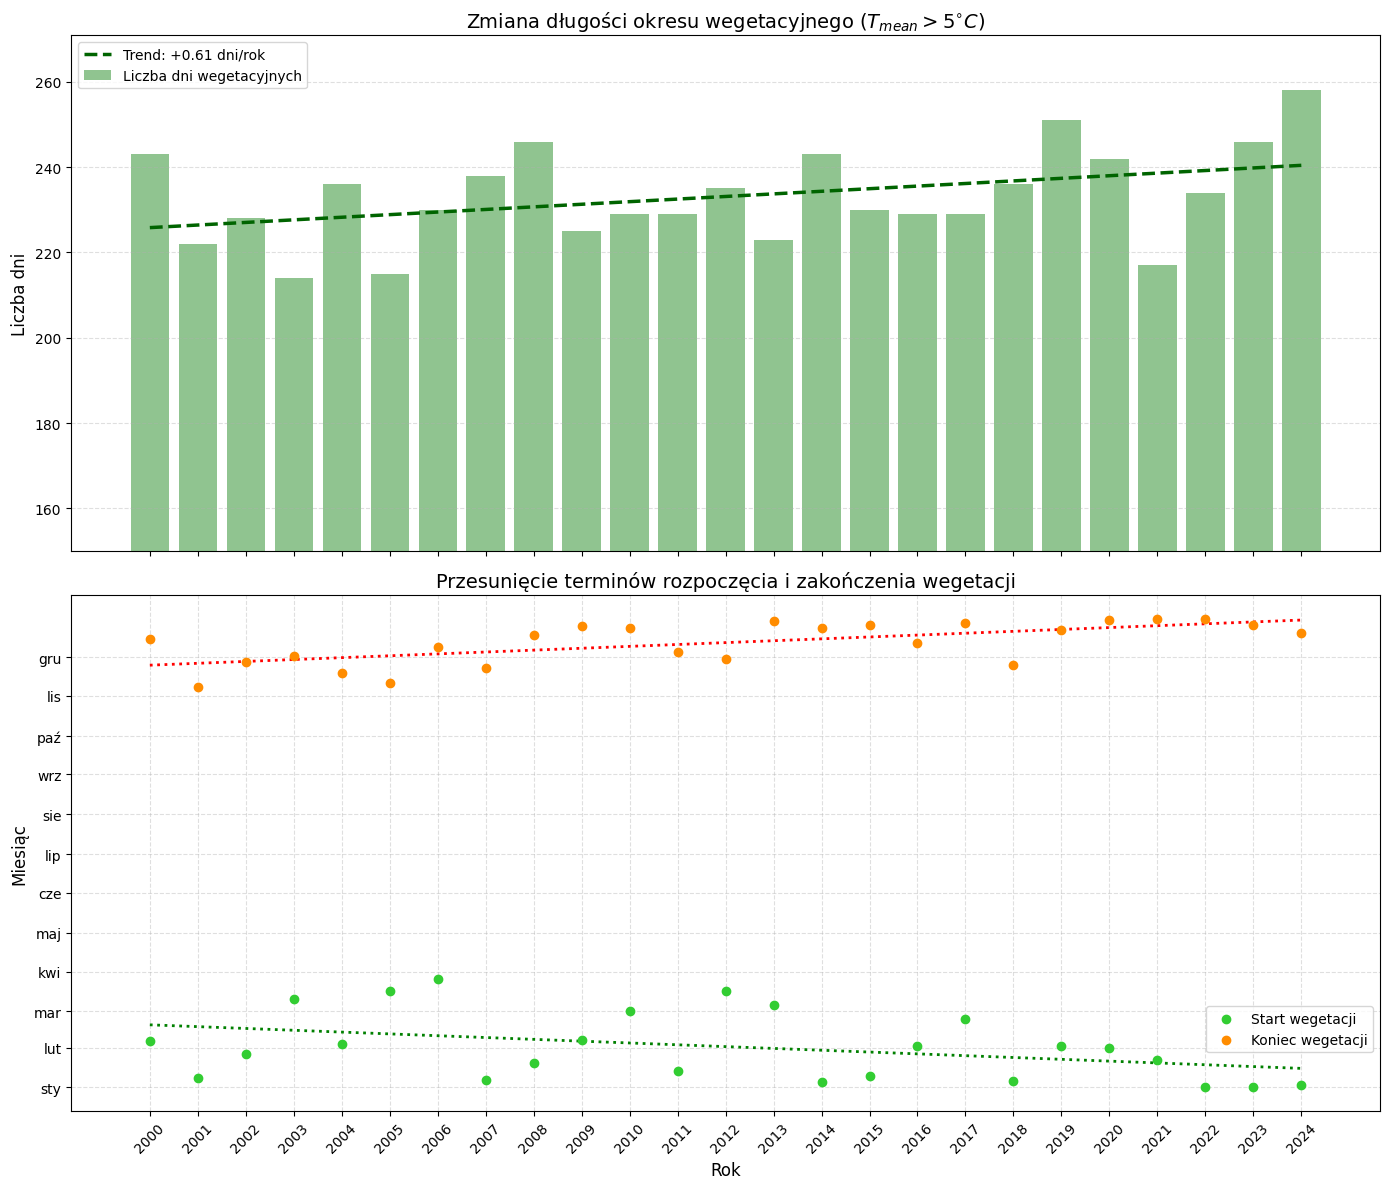

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Definicja okresu wegetacyjnego (Tmean > 5°C)
df_daily['is_veg_period'] = df_daily['temp_mean'] > 5

# 2. Obliczanie długości okresu (liczba dni w roku)
veg_duration = df_daily.groupby(df_daily.index.year)['is_veg_period'].sum()

# 3. Obliczanie daty startu i końca (dzień roku)
def get_veg_dates(group):
    veg_days = group[group['is_veg_period']]
    if not veg_days.empty:
        return pd.Series({
            'start': veg_days.index.dayofyear.min(),
            'end': veg_days.index.dayofyear.max()
        })
    return pd.Series({'start': np.nan, 'end': np.nan})

veg_dates = df_daily.groupby(df_daily.index.year).apply(get_veg_dates)

# 4. Wizualizacja
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# --- WYKRES 1: Długość okresu (liczba dni) ---
x = veg_duration.index
y = veg_duration.values
ax1.bar(x, y, color='forestgreen', alpha=0.5, label='Liczba dni wegetacyjnych')
ax1.set_ylim(bottom=150) # Oś Y zaczyna się od 150 dni

# Trend długości
model_dur = LinearRegression().fit(np.array(x).reshape(-1, 1), y)
ax1.plot(x, model_dur.predict(np.array(x).reshape(-1, 1)), color='darkgreen',
         linestyle='--', linewidth=2.5, label=f'Trend: {model_dur.coef_[0]:+.2f} dni/rok')

ax1.set_title("Zmiana długości okresu wegetacyjnego ($T_{mean} > 5^{\circ}C$)", fontsize=14)
ax1.set_ylabel("Liczba dni", fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1))

# --- WYKRES 2: Daty startu i końca (Miesiące na osi Y) ---
month_days = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_names = ['sty', 'lut', 'mar', 'kwi', 'maj', 'cze', 'lip', 'sie', 'wrz', 'paź', 'lis', 'gru']

# Start wegetacji
ax2.scatter(veg_dates.index, veg_dates['start'], color='limegreen', label='Start wegetacji', zorder=3)
# Koniec wegetacji
ax2.scatter(veg_dates.index, veg_dates['end'], color='darkorange', label='Koniec wegetacji', zorder=3)

# Trendy dla dat
for col, color in [('start', 'green'), ('end', 'red')]:
    data = veg_dates[col].dropna()
    model = LinearRegression().fit(np.array(data.index).reshape(-1, 1), data.values)
    ax2.plot(data.index, model.predict(np.array(data.index).reshape(-1, 1)),
             color=color, linestyle=':', linewidth=2)

ax2.set_title("Przesunięcie terminów rozpoczęcia i zakończenia wegetacji", fontsize=14)
ax2.set_yticks(month_days)
ax2.set_yticklabels(month_names)
ax2.set_ylabel("Miesiąc", fontsize=12)
ax2.grid(axis='both', linestyle='--', alpha=0.4)
ax2.legend(loc='lower right', bbox_to_anchor=(1, 0.1))

plt.xticks(veg_duration.index, rotation=45)
plt.xlabel("Rok", fontsize=12)
plt.tight_layout()
plt.show()

Wydłużenie sezonu: Trend wzrostowy na górnym wykresie pokazuje, o ile dni rocznie wydłuża się czas sprzyjający uprawom. Zmiana o $+0.5$ dnia/rok oznacza, że od 2000 roku okres wegetacyjny w Nowym Sączu wydłużył się o około 12 dni.Wcześniejszy start: Jeśli linia "Start wegetacji" opada w stronę marca/lutego, Twoje dane potwierdzają coraz wcześniejsze budzenie się przyrody, co przy jednoczesnym ryzyku przymrozków wiosennych jest niebezpieczne dla sadownictwa.Późniejszy koniec: Przesunięcie końca wegetacji na listopad/grudzień oznacza krótszy spoczynek zimowy roślin.

## Badanie zmian w zmienności lub intensywności zjawisk

### Rozkład (KDE) temperatury

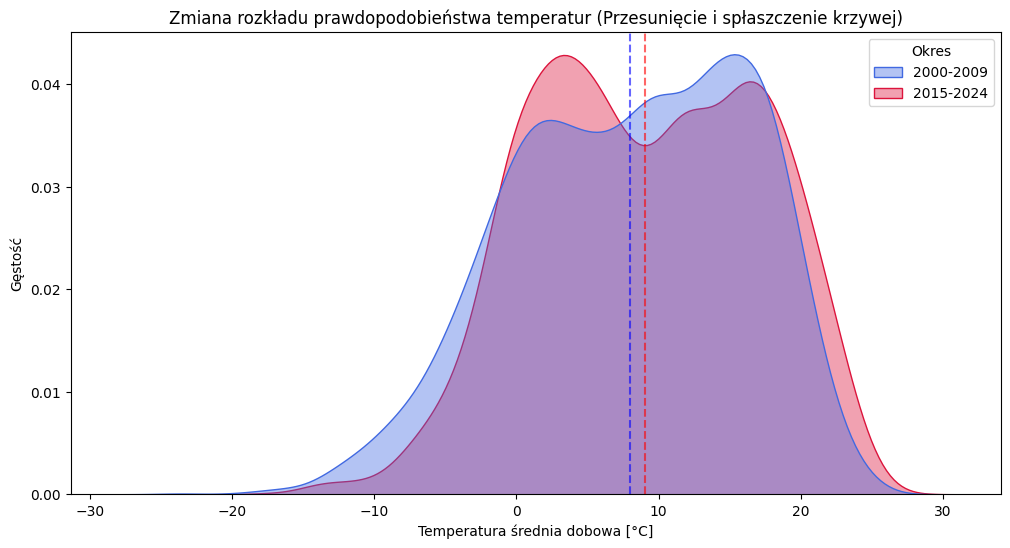

8.017843834701578
9.033346545415077


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df_daily.index = pd.to_datetime(df_daily.index)

# --- 1. WYKRES GĘSTOŚCI (Zmiana struktury temperatur) ---
df_daily['Okres'] = 'Inne'
df_daily.loc[df_daily.index.year.isin(range(2000, 2010)), 'Okres'] = '2000-2009'
df_daily.loc[df_daily.index.year.isin(range(2015, 2025)), 'Okres'] = '2015-2024'

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_daily[df_daily.Okres != 'Inne'], x='temp_mean', hue='Okres',
            fill=True, common_norm=False, palette=['royalblue', 'crimson'], alpha=0.4)
plt.axvline(df_daily[df_daily.Okres == '2000-2009']['temp_mean'].mean(), color='blue', linestyle='--', alpha=0.6)
plt.axvline(df_daily[df_daily.Okres == '2015-2024']['temp_mean'].mean(), color='red', linestyle='--', alpha=0.6)
plt.title("Zmiana rozkładu prawdopodobieństwa temperatur (Przesunięcie i spłaszczenie krzywej)")
plt.xlabel("Temperatura średnia dobowa [°C]")
plt.ylabel("Gęstość")
plt.show()
print(df_daily[df_daily.Okres == '2000-2009']['temp_mean'].mean())
print(df_daily[df_daily.Okres == '2015-2024']['temp_mean'].mean())

### Analiza amplitud dobowych i rocznych temperatury

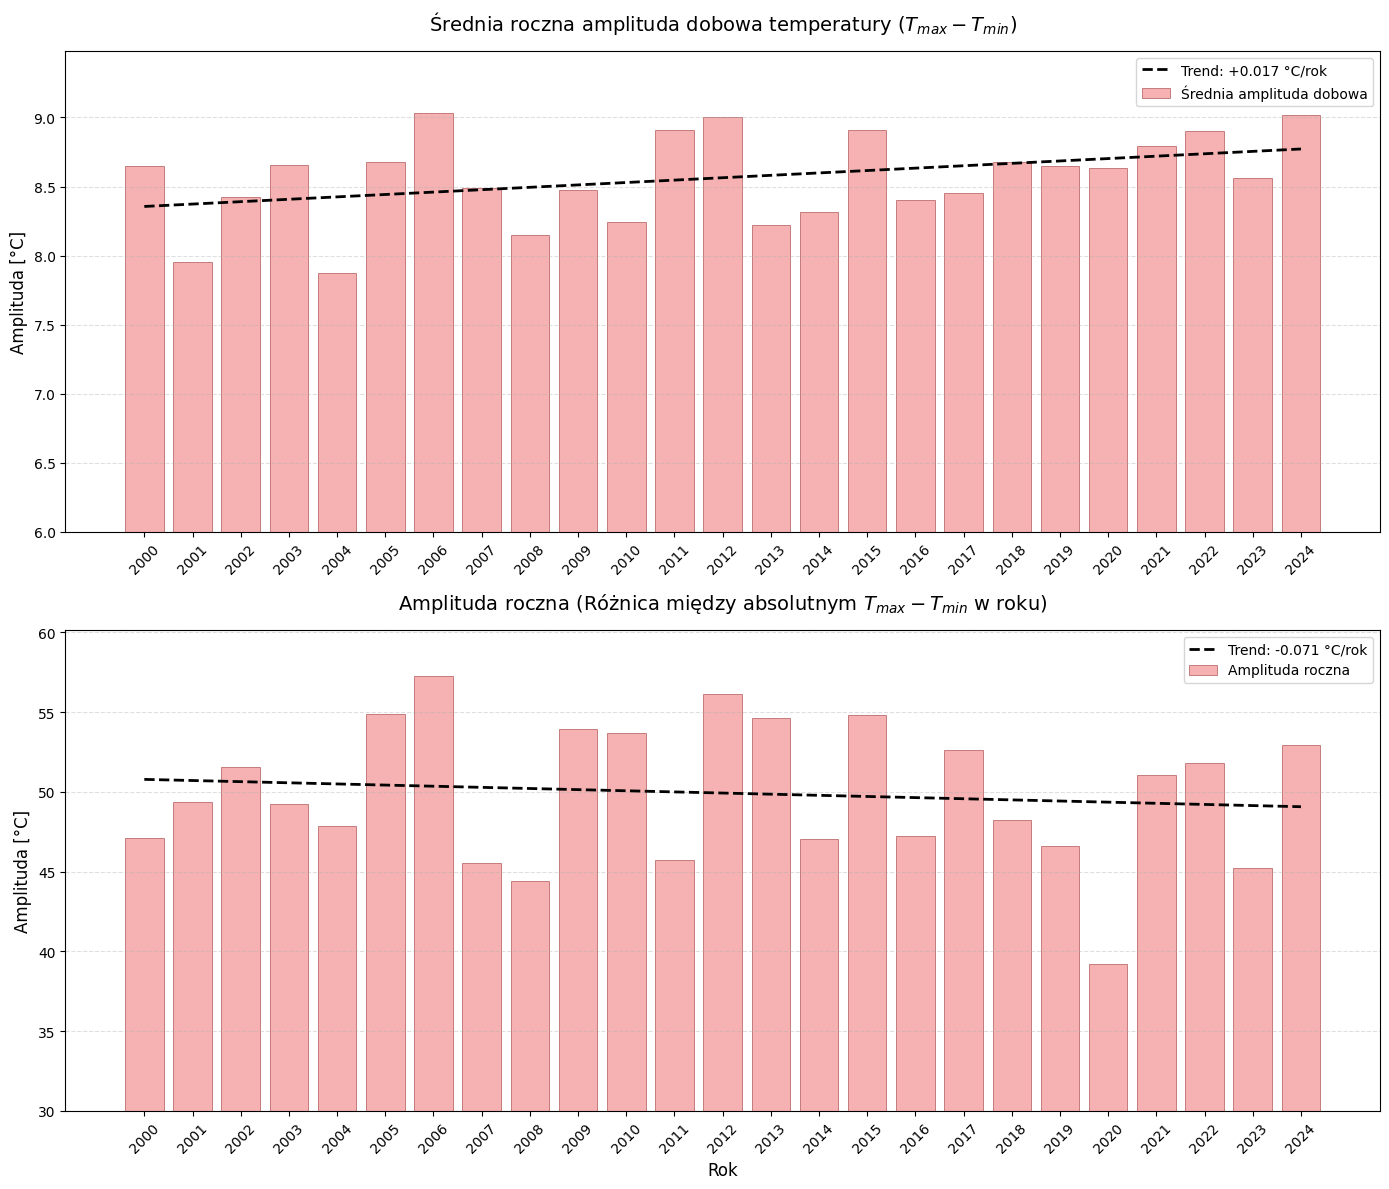

Trend zmiany amplitudy dobowej: +0.0173 °C/rok
Trend zmiany amplitudy rocznej: -0.0714 °C/rok


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Obliczenia
# Amplituda dobowa: Tmax - Tmin dla każdego dnia
df_daily['daily_amp'] = df_daily['temp_max'] - df_daily['temp_min']

# Agregacja roczna
annual_stats = df_daily.groupby(df_daily.index.year).agg(
    avg_daily_amp=('daily_amp', 'mean'),             # Średnia z amplitud dobowych
    annual_max_temp=('temp_max', 'max'),            # Najwyższa temp w roku
    annual_min_temp=('temp_min', 'min')             # Najniższa temp w roku
)

# Amplituda roczna: Max(Tmax) - Min(Tmin) w całym roku
annual_stats['annual_range'] = annual_stats['annual_max_temp'] - annual_stats['annual_min_temp']

# 2. Wizualizacja
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

def plot_with_trend_v2(ax, x, y, title, ylabel, color, label_text, y_bottom):
    # Słupki w kolorze jasnoczerwonym ('lightcoral')
    ax.bar(x, y, color=color, alpha=0.6, edgecolor='maroon', linewidth=0.5, label=label_text)

    # Ustawienie dolnego limitu osi Y
    ax.set_ylim(bottom=y_bottom)

    # Trend liniowy
    X_reg = np.array(x).reshape(-1, 1)
    model = LinearRegression().fit(X_reg, y)
    trend = model.predict(X_reg)
    slope = model.coef_[0]

    ax.plot(x, trend, color='black', linestyle='--', linewidth=2,
            label=f'Trend: {slope:+.3f} °C/rok')

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks(x)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend()

# Kolor spójny: lightcoral (jasnoczerwony)
main_color = 'lightcoral'

# Wykres 1: Średnia amplituda dobowa (od 6 stopni)
plot_with_trend_v2(ax1, annual_stats.index, annual_stats['avg_daily_amp'],
                "Średnia roczna amplituda dobowa temperatury ($T_{max} - T_{min}$)",
                "Amplituda [°C]", main_color, "Średnia amplituda dobowa", y_bottom=6)

# Wykres 2: Amplituda roczna (od 30 stopni)
plot_with_trend_v2(ax2, annual_stats.index, annual_stats['annual_range'],
                "Amplituda roczna (Różnica między absolutnym $T_{max} - T_{min}$ w roku)",
                "Amplituda [°C]", main_color, "Amplituda roczna", y_bottom=30)
plt.xlabel("Rok", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Trend zmiany amplitudy dobowej: {LinearRegression().fit(np.array(annual_stats.index).reshape(-1,1), annual_stats['avg_daily_amp']).coef_[0]:+.4f} °C/rok")
print(f"Trend zmiany amplitudy rocznej: {LinearRegression().fit(np.array(annual_stats.index).reshape(-1,1), annual_stats['annual_range']).coef_[0]:+.4f} °C/rok")

Amplituda Dobowa: Jeśli trend rośnie, oznacza to, że dni stają się coraz cieplejsze w stosunku do nocy (częste przy suchym powietrzu i falach upałów). Jeśli maleje – może to oznaczać wzrost zachmurzenia lub wilgotności, które "trzymają" ciepło w nocy.

Amplituda Roczna: To miara kontynentalizmu.

Wzrost amplitudy rocznej sugeruje, że ekstrema (bardzo gorące lato i bardzo mroźna zima) stają się coraz silniejsze.

Spadek sugeruje, że zimy łagodnieją znacznie szybciej, niż lata się nagrzewają (co jest typowe dla globalnego ocieplenia w Polsce).

### Zmiana zmienności temperatur

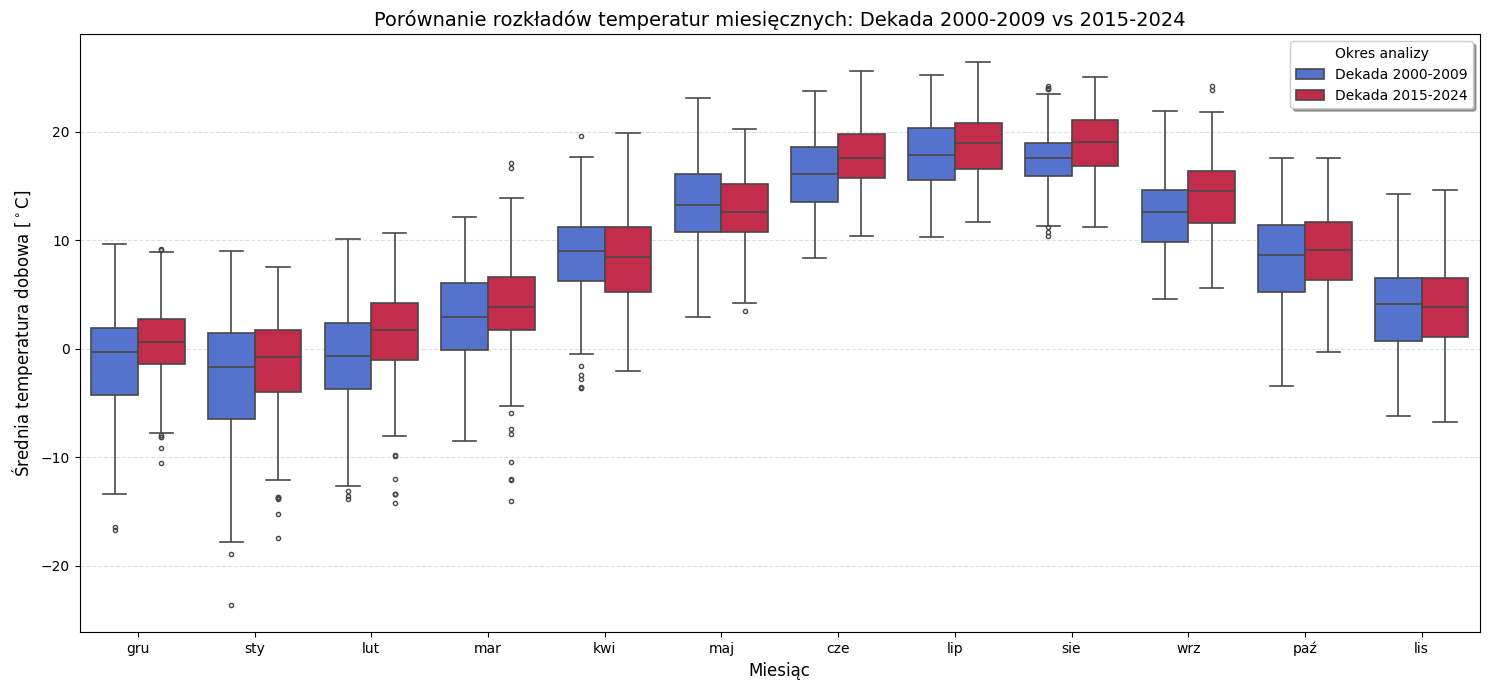

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Przygotowanie danych i naprawa brakującej kolumny ---
df_daily.index = pd.to_datetime(df_daily.index)
df_daily['year'] = df_daily.index.year

# Tworzymy month_shift (Grudzień = 0 dla zachowania ciągłości zimy)
df_daily['month_shift'] = df_daily.index.month
df_daily['month_shift'] = df_daily['month_shift'].replace(12, 0)

# Definicja okresów porównawczych (Dekady)
df_daily['period'] = 'Inne'
df_daily.loc[(df_daily['year'] >= 2000) & (df_daily['year'] <= 2009), 'period'] = 'Dekada 2000-2009'
df_daily.loc[(df_daily['year'] >= 2015) & (df_daily['year'] <= 2024), 'period'] = 'Dekada 2015-2024'

# --- 2. Wykres: BOXPLOT ZMIENNOŚCI TEMPERATURY ---
month_names = ['gru', 'sty', 'lut', 'mar', 'kwi', 'maj', 'cze', 'lip', 'sie', 'wrz', 'paź', 'lis']
df_plot = df_daily[df_daily['period'] != 'Inne'].copy()
my_palette = {"Dekada 2000-2009": "royalblue", "Dekada 2015-2024": "crimson"}

plt.figure(figsize=(15, 7))
sns.boxplot(x='month_shift', y='temp_mean', hue='period', data=df_plot,
            palette=my_palette, fliersize=3, linewidth=1.2)

plt.title("Porównanie rozkładów temperatur miesięcznych: Dekada 2000-2009 vs 2015-2024", fontsize=14)
plt.xlabel("Miesiąc", fontsize=12)
plt.ylabel(r"Średnia temperatura dobowa [$^\circ$C]", fontsize=12)
plt.xticks(range(0, 12), labels=month_names)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Okres analizy", frameon=True, shadow=True)
plt.tight_layout()
plt.show()

Boxplot (Zmienność rozkładu): Pozwala zauważyć, że w nowszej dekadzie nie tylko średnia poszła w górę, ale „pudełka” są często wyższe lub mają więcej punktów odstających. To dowód, że temperatury stały się mniej stabilne.


## Porównanie zależności w latach ekstremalnych

### Wybór lat ekstremalnych - metoda statystyczna z-score

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# 1. Obliczanie średniej i odchylenia standardowego
mean_t = df_annual['temp_mean'].mean()
std_t = df_annual['temp_mean'].std()

# 2. Obliczanie Z-Score (o ile odchyleń standardowych rok różni się od średniej)
df_annual['z_score_temp'] = (df_annual['temp_mean'] - mean_t) / std_t

# 3. Wybór lat ekstremalnie ciepłych i zimnych (próg 1.5 sigma)
prog = 1.5
lata_cieple = df_annual[df_annual['z_score_temp'] > prog].index.tolist()
lata_zimne = df_annual[df_annual['z_score_temp'] < -prog].index.tolist()

print(f"Lata ekstremalnie ciepłe (>{prog} sigma): {lata_cieple}")
print(f"Lata ekstremalnie zimne (< -{prog} sigma): {lata_zimne}")

# To samo dla opadów
mean_p = df_annual['precip_sum'].mean()
std_p = df_annual['precip_sum'].std()
df_annual['z_score_precip'] = (df_annual['precip_sum'] - mean_p) / std_p

lata_mokre = df_annual[df_annual['z_score_precip'] > prog].index.tolist()
lata_suche = df_annual[df_annual['z_score_precip'] < -prog].index.tolist()

print(f"Lata ekstremalnie mokre (>{prog} sigma): {lata_mokre}")
print(f"Lata ekstremalnie suche (< -{prog} sigma): {lata_suche}")

sns.set_style("whitegrid")

# okres referencyjny = wszystkie lata poza ekstremalnymi
lata_normalne = df_annual.index.difference(
    lata_cieple + lata_zimne + lata_mokre + lata_suche
)

Lata ekstremalnie ciepłe (>1.5 sigma): [2024]
Lata ekstremalnie zimne (< -1.5 sigma): [2005, 2010]
Lata ekstremalnie mokre (>1.5 sigma): [2010]
Lata ekstremalnie suche (< -1.5 sigma): [2003, 2015]


### Profile sezonowe – lata ekstremalne vs norma (temperatura)

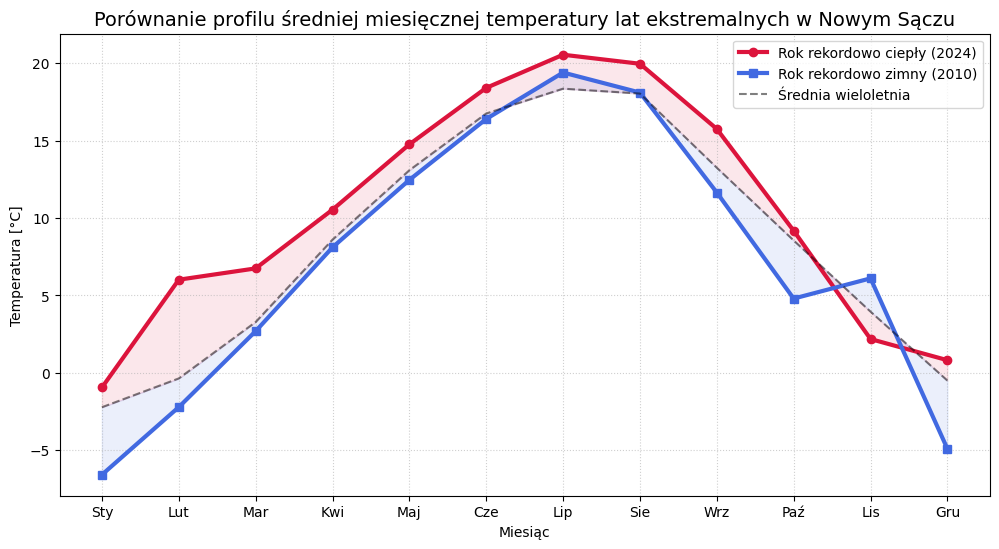

In [66]:
import matplotlib.pyplot as plt

# 1. Wybór lat do porównania (na podstawie wcześniejszego Z-Score)
rok_goracy = df_annual['temp_mean'].idxmax()
rok_zimny = df_annual['temp_mean'].idxmin()

# 2. Przygotowanie danych miesięcznych dla tych lat
data_goracy = df_daily[df_daily.index.year == rok_goracy].groupby(df_daily[df_daily.index.year == rok_goracy].index.month)['temp_mean'].mean()
data_zimny = df_daily[df_daily.index.year == rok_zimny].groupby(df_daily[df_daily.index.year == rok_zimny].index.month)['temp_mean'].mean()
norma = df_daily.groupby(df_daily.index.month)['temp_mean'].mean()

# 3. Wykres
plt.figure(figsize=(12, 6))
months = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru']

plt.plot(months, data_goracy, color='crimson', marker='o', linewidth=3, label=f'Rok rekordowo ciepły ({rok_goracy})')
plt.plot(months, data_zimny, color='royalblue', marker='s', linewidth=3, label=f'Rok rekordowo zimny ({rok_zimny})')
plt.plot(months, norma, color='black', linestyle='--', alpha=0.5, label='Średnia wieloletnia')

plt.fill_between(months, data_goracy, norma, color='crimson', alpha=0.1)
plt.fill_between(months, data_zimny, norma, color='royalblue', alpha=0.1)

plt.title(f"Porównanie profilu średniej miesięcznej temperatury lat ekstremalnych w Nowym Sączu", fontsize=14)
plt.ylabel("Temperatura [°C]")
plt.xlabel("Miesiąc")
plt.grid(linestyle=':', alpha=0.6)
plt.legend()
plt.show()

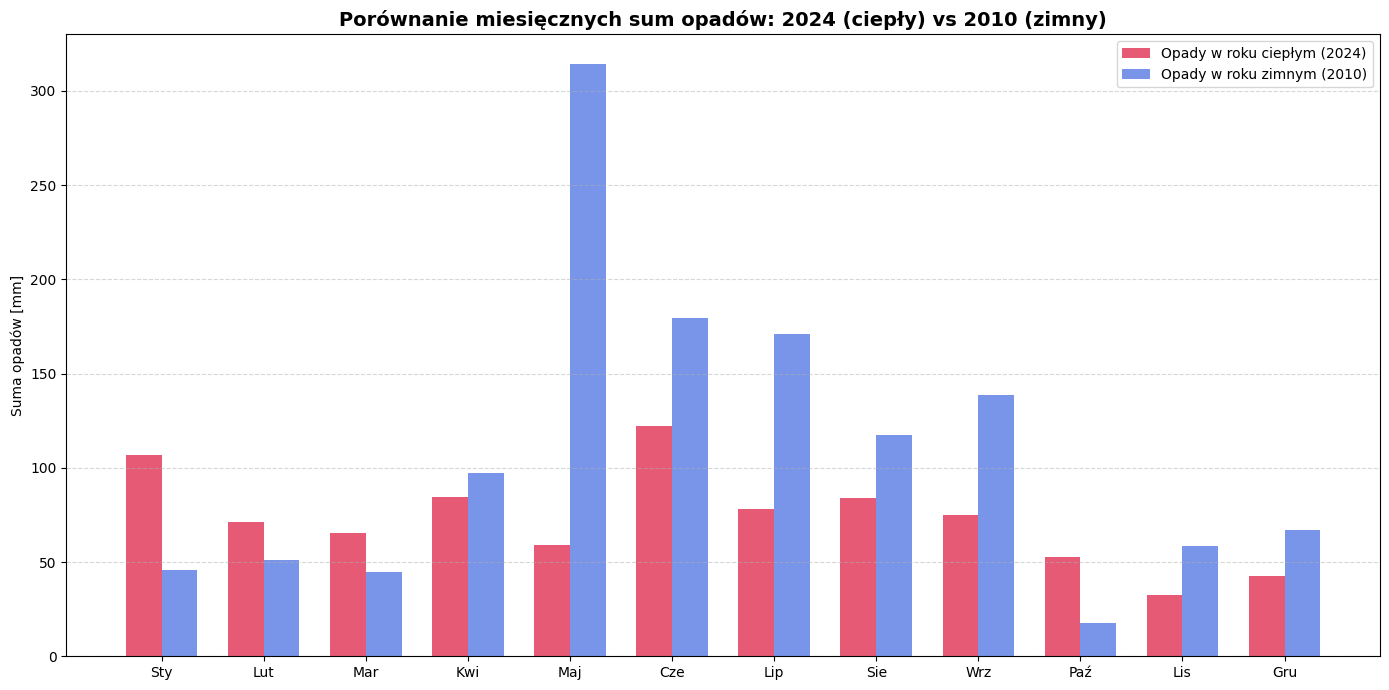

Różnica opadów w listopadzie (2024 - 2010): -26.14 mm


In [36]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Przygotowanie danych miesięcznych dla lat 2010 i 2024
# Zakładamy, że rok_zimny = 2010, a rok_ciepły = 2024 (zgodnie z Twoją obserwacją)
year_warm = 2024
year_cold = 2010

precip_warm = df_daily[df_daily.index.year == year_warm].groupby(df_daily[df_daily.index.year == year_warm].index.month)['precip_sum'].sum()
precip_cold = df_daily[df_daily.index.year == year_cold].groupby(df_daily[df_daily.index.year == year_cold].index.month)['precip_sum'].sum()

# 2. Tworzenie wykresu słupkowego
plt.figure(figsize=(14, 7))
months = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru']
x = np.arange(len(months))
width = 0.35

plt.bar(x - width/2, precip_warm, width, label=f'Opady w roku ciepłym ({year_warm})', color='crimson', alpha=0.7)
plt.bar(x + width/2, precip_cold, width, label=f'Opady w roku zimnym ({year_cold})', color='royalblue', alpha=0.7)

plt.title(f"Porównanie miesięcznych sum opadów: {year_warm} (ciepły) vs {year_cold} (zimny)", fontsize=14, fontweight='bold')
plt.xticks(x, months)
plt.ylabel("Suma opadów [mm]")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# Sprawdzenie różnicy w listopadzie
diff_nov = precip_warm[11] - precip_cold[11]
print(f"Różnica opadów w listopadzie ({year_warm} - {year_cold}): {diff_nov:.2f} mm")

### Profile sezonowe – lata ekstremalne vs norma (opad)

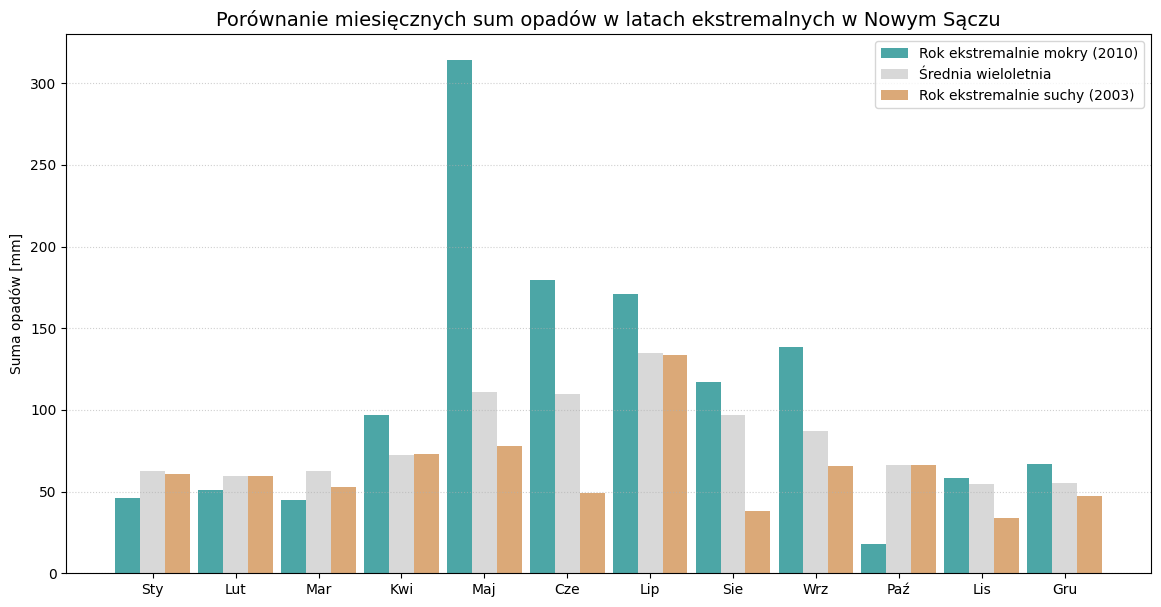

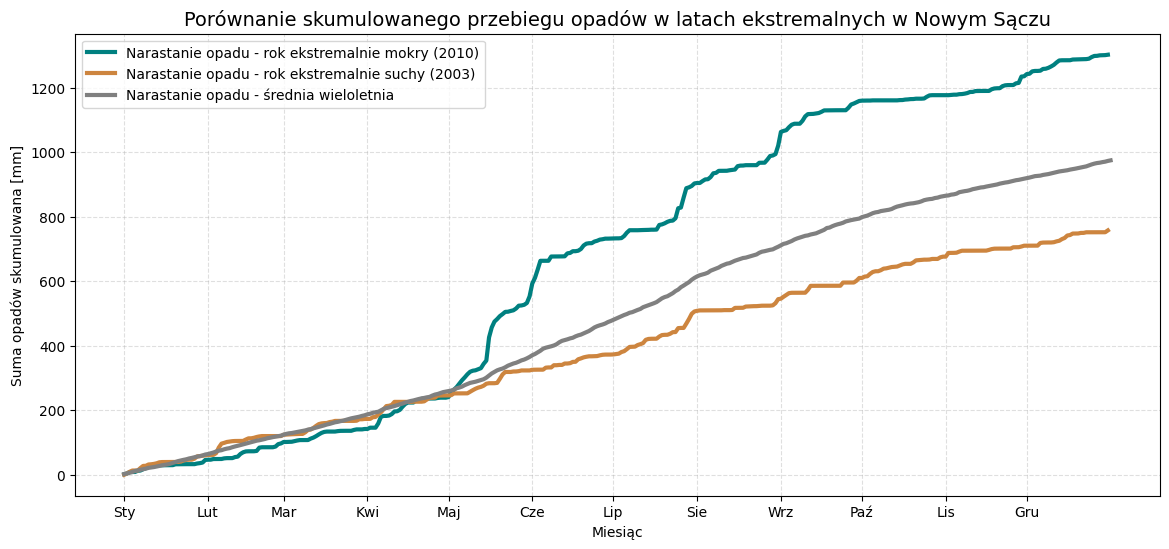

In [39]:
import matplotlib.pyplot as plt

# 1. Wybór lat ekstremalnych pod kątem opadów
rok_mokry = df_annual['precip_sum'].idxmax()
rok_suchy = df_annual['precip_sum'].idxmin()

# 2. Przygotowanie danych miesięcznych (sumy miesięczne)
data_mokry = df_daily[df_daily.index.year == rok_mokry].groupby(df_daily[df_daily.index.year == rok_mokry].index.month)['precip_sum'].sum()
data_suchy = df_daily[df_daily.index.year == rok_suchy].groupby(df_daily[df_daily.index.year == rok_suchy].index.month)['precip_sum'].sum()
norma_opad = df_daily.groupby(df_daily.index.month)['precip_sum'].sum() / (df_daily.index.year.max() - df_daily.index.year.min() + 1)

# 3. Wykres słupkowy porównawczy
plt.figure(figsize=(14, 7))
months = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru']
x = np.arange(len(months))
width = 0.3

plt.bar(x - width, data_mokry, width, label=f'Rok ekstremalnie mokry ({rok_mokry})', color='teal', alpha=0.7)
plt.bar(x, norma_opad, width, label='Średnia wieloletnia', color='gray', alpha=0.3)
plt.bar(x + width, data_suchy, width, label=f'Rok ekstremalnie suchy ({rok_suchy})', color='peru', alpha=0.7)

plt.title(f"Porównanie miesięcznych sum opadów w latach ekstremalnych w Nowym Sączu", fontsize=14)
plt.ylabel("Suma opadów [mm]")
plt.xticks(x, months)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# --- 4. WYKRES DODATKOWY: Suma skumulowana
plt.figure(figsize=(14, 6))

# Obliczamy sumę narastającą dzień po dniu
df_mokry_cum = df_daily[df_daily.index.year == rok_mokry]['precip_sum'].cumsum()
df_suchy_cum = df_daily[df_daily.index.year == rok_suchy]['precip_sum'].cumsum()

# Dla średniej tworzymy profil "typowego roku"
typowa_skumulowana = df_daily.groupby([df_daily.index.month, df_daily.index.day])['precip_sum'].mean().cumsum()

plt.plot(range(len(df_mokry_cum)), df_mokry_cum, color='teal', linewidth=3, label=f'Narastanie opadu - rok ekstremalnie mokry ({rok_mokry})')
plt.plot(range(len(df_suchy_cum)), df_suchy_cum, color='peru', linewidth=3, label=f'Narastanie opadu - rok ekstremalnie suchy ({rok_suchy})')
plt.plot(range(len(typowa_skumulowana)), typowa_skumulowana, color='gray', linewidth=3, label=f'Narastanie opadu - średnia wieloletnia')

# 3. DODANIE NAZW MIESIĘCY NA OSI X
# Przybliżone dni rozpoczęcia miesięcy (dla roku 365-dniowego)
month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_names = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru']

plt.xticks(month_starts, month_names)

plt.title("Porównanie skumulowanego przebiegu opadów w latach ekstremalnych w Nowym Sączu", fontsize=14)
plt.xlabel("Miesiąc")
plt.ylabel("Suma opadów skumulowana [mm]")
plt.grid(linestyle='--', alpha=0.4)
plt.legend()
plt.show()

### Wykresy rozrzutu

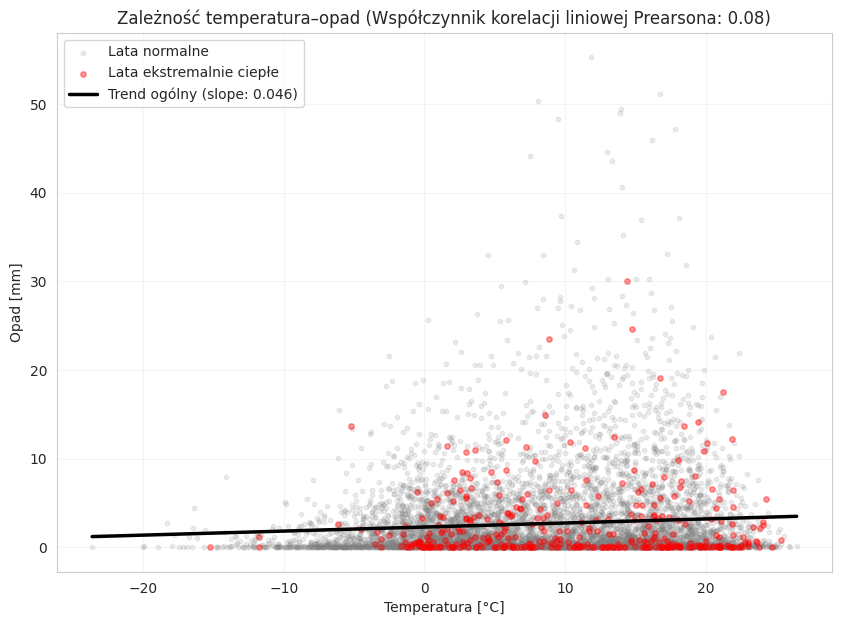

In [54]:
import numpy as np
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(10, 7))

# 1. Przygotowanie danych do trendu (usuwamy NaN, aby model zadziałał)
df_clean = df_daily[['temp_mean', 'precip_sum']].dropna()
X = df_clean['temp_mean'].values.reshape(-1, 1)
y = df_clean['precip_sum'].values

# 2. Lata normalne (tło)
normal = df_daily[df_daily.index.year.isin(lata_normalne)]
plt.scatter(normal['temp_mean'], normal['precip_sum'],
            alpha=0.15, s=10, color='gray', label='Lata normalne')

# 3. Lata ekstremalnie ciepłe (wyróżnienie)
hot = df_daily[df_daily.index.year.isin(lata_cieple)]
cold = df_daily[df_daily.index.year.isin(lata_zimne)]
plt.scatter(hot['temp_mean'], hot['precip_sum'],
            color='red', alpha=0.4, s=15, label='Lata ekstremalnie ciepłe')

# 4. DODANIE LINII TRENDU
model = LinearRegression().fit(X, y)
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = model.predict(X_range)

plt.plot(X_range, y_pred, color='black', linestyle='-', linewidth=2.5,
         label=f'Trend ogólny (slope: {model.coef_[0]:.3f})')

# 5. Statystyki do tytułu
correlation = np.corrcoef(df_clean['temp_mean'], y)[0, 1]

plt.xlabel("Temperatura [°C]")
plt.ylabel("Opad [mm]")
plt.title(f"Zależność temperatura–opad (Współczynnik korelacji liniowej Prearsona: {correlation:.2f})")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

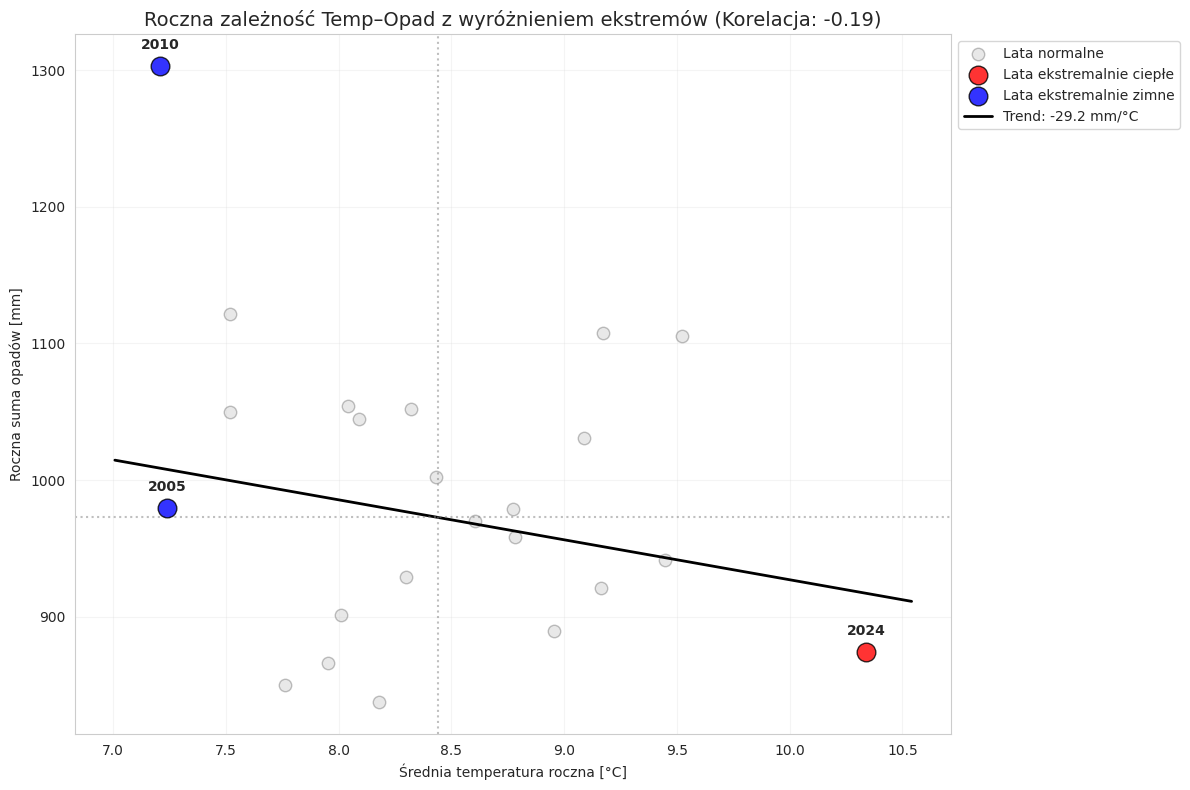

In [51]:
import numpy as np
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(12, 8))

# 1. Przygotowanie danych
df_clean_annual = df_annual[['temp_mean', 'precip_sum']].dropna()
X_ann = df_clean_annual['temp_mean'].values.reshape(-1, 1)
y_ann = df_clean_annual['precip_sum'].values

# 2. Lata normalne (tło - szare)
normal_ann = df_clean_annual[df_clean_annual.index.isin(lata_normalne)]
plt.scatter(normal_ann['temp_mean'], normal_ann['precip_sum'],
            s=80, color='lightgray', alpha=0.5, label='Lata normalne', edgecolors='gray')

# 3. Lata ekstremalnie ciepłe (czerwone)
hot_ann = df_clean_annual[df_clean_annual.index.isin(lata_cieple)]
plt.scatter(hot_ann['temp_mean'], hot_ann['precip_sum'],
            s=180, color='red', alpha=0.8, label='Lata ekstremalnie ciepłe', edgecolors='black', zorder=5)

# 4. Lata ekstremalnie zimne (niebieskie)
# Na podstawie Twoich wyliczeń: lata_zimne = [2005, 2010]
cold_ann = df_clean_annual[df_clean_annual.index.isin(lata_zimne)]
plt.scatter(cold_ann['temp_mean'], cold_ann['precip_sum'],
            s=180, color='blue', alpha=0.8, label='Lata ekstremalnie zimne', edgecolors='black', zorder=5)

# 5. Linia trendu rocznego (ciągła dla lepszej widoczności)
model_ann = LinearRegression().fit(X_ann, y_ann)
X_range_ann = np.linspace(X_ann.min() - 0.2, X_ann.max() + 0.2, 100).reshape(-1, 1)
plt.plot(X_range_ann, model_ann.predict(X_range_ann), color='black', linestyle='-', linewidth=2,
         label=f'Trend: {model_ann.coef_[0]:+.1f} mm/°C')

# 6. Adnotacje dla wszystkich ekstremów
for yr in list(hot_ann.index) + list(cold_ann.index):
    plt.annotate(yr, (df_clean_annual.loc[yr, 'temp_mean'], df_clean_annual.loc[yr, 'precip_sum']),
                 textcoords="offset points", xytext=(0,12), ha='center', fontweight='bold', fontsize=10)

# 7. Linie średnich (krzyż normy)
plt.axvline(df_clean_annual['temp_mean'].mean(), color='gray', linestyle=':', alpha=0.5)
plt.axhline(df_clean_annual['precip_sum'].mean(), color='gray', linestyle=':', alpha=0.5)

# Statystyki i stylizacja
correlation_ann = np.corrcoef(X_ann.flatten(), y_ann)[0, 1]
plt.title(f"Roczna zależność Temp–Opad z wyróżnieniem ekstremów (Korelacja: {correlation_ann:.2f})", fontsize=14)
plt.xlabel("Średnia temperatura roczna [°C]")
plt.ylabel("Roczna suma opadów [mm]")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

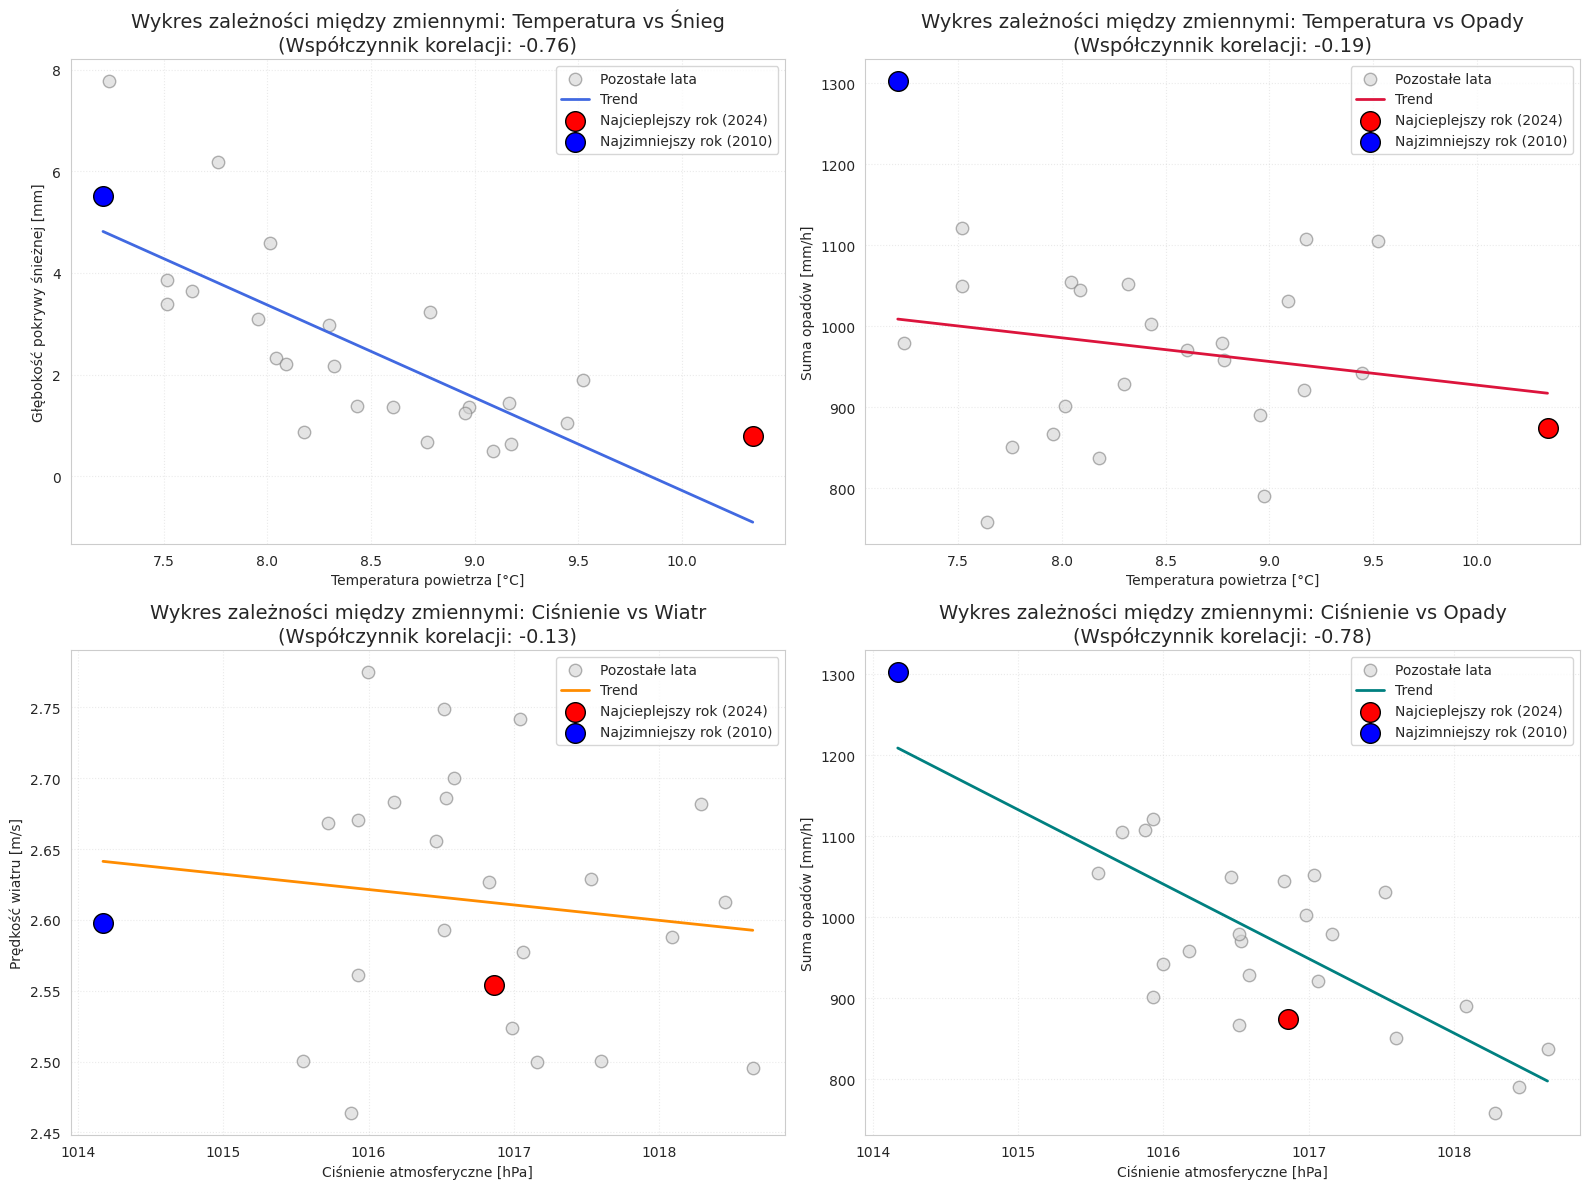

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

pairs = [
    ('temp_mean', 'snow_depth_mean', 'Temperatura vs Śnieg', 'royalblue'),
    ('temp_mean', 'precip_sum', 'Temperatura vs Opady', 'crimson'),
    ('pressure_mean', 'wind_speed_mean', 'Ciśnienie vs Wiatr', 'darkorange'),
    ('pressure_mean', 'precip_sum', 'Ciśnienie vs Opady', 'teal')
]

# 2. Identyfikacja lat ekstremalnych do wyróżnienia
warmest_yr = df_annual['temp_mean'].idxmax()
coldest_yr = df_annual['temp_mean'].idxmin()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (var_x, var_y, title, color) in enumerate(pairs):
    ax = axes[i]

    # Dane do wykresu
    x = df_annual[var_x].values.reshape(-1, 1)
    y = df_annual[var_y].values

    # Rysowanie tła (wszystkie lata)
    ax.scatter(x, y, color='lightgray', s=80, alpha=0.6, edgecolors='gray', label='Pozostałe lata')

    # Linia trendu (regresja liniowa)
    model = LinearRegression().fit(x, y)
    x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    ax.plot(x_range, model.predict(x_range), color=color, linestyle='-', linewidth=2, label='Trend')

    # Wyróżnienie Najcieplejszego Roku (2024)
    ax.scatter(df_annual.loc[warmest_yr, var_x], df_annual.loc[warmest_yr, var_y],
               color='red', s=200, edgecolor='black', zorder=5, label=f'Najcieplejszy rok ({warmest_yr})')

    # Wyróżnienie Najzimniejszego Roku (np. 2005/2010)
    ax.scatter(df_annual.loc[coldest_yr, var_x], df_annual.loc[coldest_yr, var_y],
               color='blue', s=200, edgecolor='black', zorder=5, label=f'Najzimniejszy rok ({coldest_yr})')

    # Obliczanie korelacji
    corr = np.corrcoef(df_annual[var_x], y)[0, 1]

    # Stylizacja
    ax.set_title(f"Wykres zależności między zmiennymi: {title}\n(Współczynnik korelacji: {corr:.2f})", fontsize=14)
    ax.set_xlabel(f"{variables_info[var_x][0]} [{variables_info[var_x][1]}]")
    ax.set_ylabel(f"{variables_info[var_y][0]} [{variables_info[var_y][1]}]")
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.show()

### Macierze współczynników korelacji liniowej Pearsona – lata ekstremalne

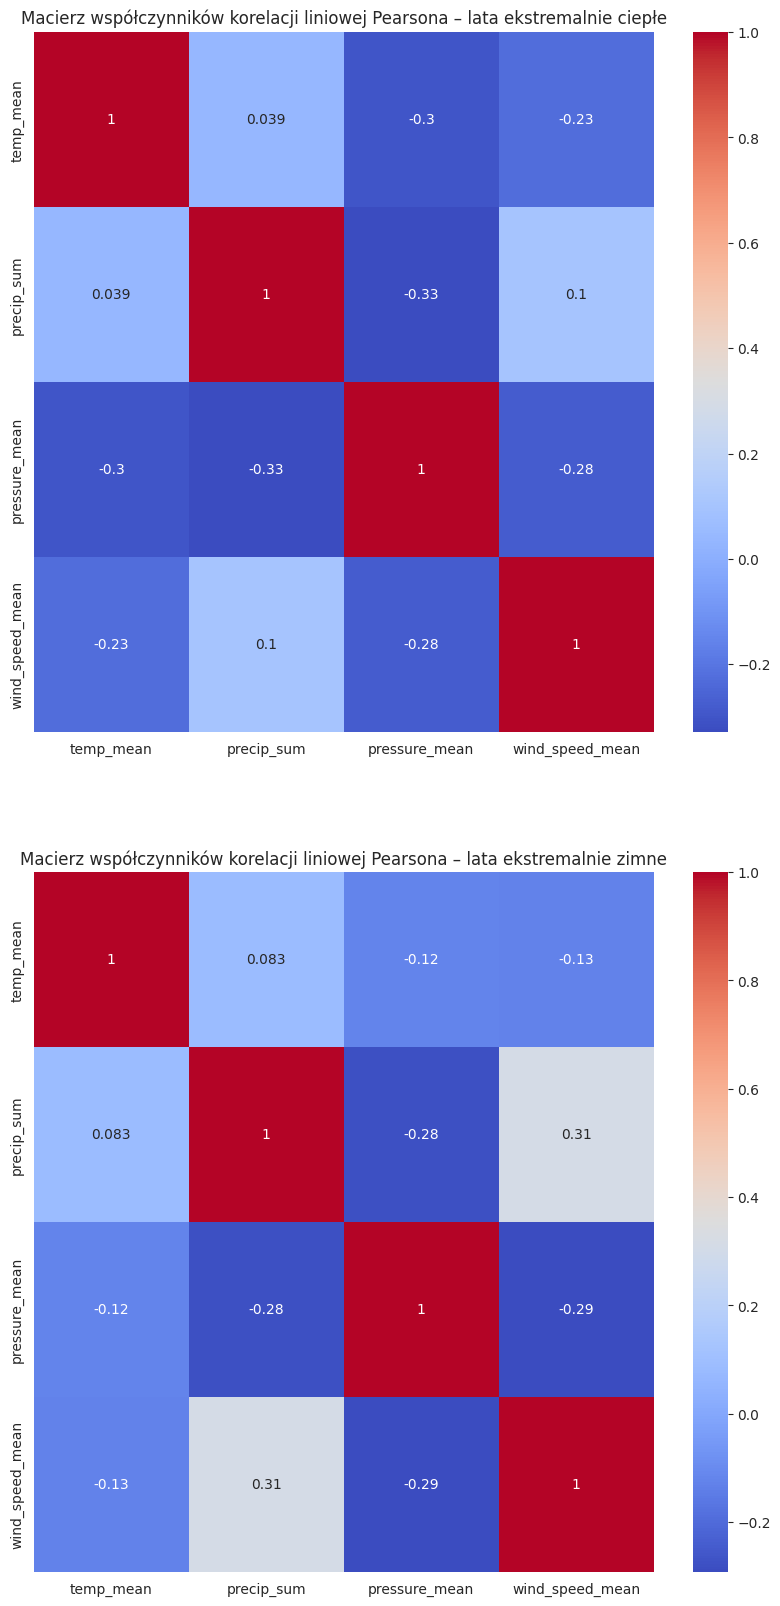

In [59]:
vars_corr = ['temp_mean', 'precip_sum', 'pressure_mean', 'wind_speed_mean']

fig, axes = plt.subplots(2,1, figsize=(10,20))

corr_hot = hot[vars_corr].corr()
corr_norm = cold[vars_corr].corr()

sns.heatmap(corr_hot, ax=axes[0], annot=True, cmap='coolwarm')
axes[0].set_title("Macierz współczynników korelacji liniowej Pearsona – lata ekstremalnie ciepłe")

sns.heatmap(corr_norm, ax=axes[1], annot=True, cmap='coolwarm')
axes[1].set_title("Macierz współczynników korelacji liniowej Pearsona – lata ekstremalnie zimne")

plt.show()


# Wnioski z EDA

## Jak zmienia się klimat w Nowym Sączu?

Gwałtowny wzrost temperatury: Analiza dekadowa i trend roczny (szczególnie rekordowy 2024) pokazują, że region przesuwa się w stronę klimatu znacznie cieplejszego. Średnie temperatury roczne rosną, a ekstrema ciepła stają się nową normą.

Zanik retencji śnieżnej: Wykresy zależności temperatura-śnieg udowodniły, że ocieplenie drastycznie skraca czas zalegania śniegu. To oznacza zmianę cyklu hydrologicznego – woda skumulowana w pokrywie śnieżnej nie zalega do wiosny, lecz natychmiast topnieje, co zwiększa ryzyko wiosennych susz.

Zmiana charakteru opadów: Choć suma roczna może drastycznie nie spadać, wykresy skumulowane pokazują okresy długotrwałych deficytów (rok 2003, 2015) przerywane gwałtownymi ulewami (rok 2010). Klimat staje się bardziej "skokowy".

## Jakie działania można rekomendować na podstawie dostępnych danych?

Adaptacja rolnictwa i zieleni miejskiej: Ze względu na trend wzrostu temperatury i okresowe susze (widoczne w skumulowanych opadach), należy rekomendować dobór gatunków roślin odpornych na brak wody i wysokie temperatury.

Gospodarka wodna: Skoro zanika naturalna retencja w postaci śniegu, konieczna jest budowa systemów małej retencji (zbiorniki, ogrody deszczowe), które "zatrzymają" gwałtowne opady deszczu widoczne na naszych wykresach dziennych.

Monitoring ciśnienia jako predyktora: Nasze wykresy rozrzutu pokazały, że spadek ciśnienia jest silnie skorelowany z gwałtownym opadem. Rekomenduje się wykorzystanie danych barometrycznych w lokalnych systemach wczesnego ostrzegania dla Nowego Sącza.

## Czy możemy użyć technik ML do przewidywania przyszłych zmian na podstawie wniosków z EDA?

Analiza EDA potwierdziła, że między zmiennymi istnieją silne korelacje fizyczne.

## Możliwe podejścia ML

Modele Regresyjne (np. XGBoost, Random Forest): Do przewidywania konkretnych wartości (np. jaka będzie suma opadów w przyszłym miesiącu).

Modele Szeregów Czasowych (np. LSTM, Prophet): Do prognozowania trendów długoterminowych na podstawie historycznych cykli sezonowych, które wykazaliśmy na wykresach miesięcznych.

Klasyfikacja: Do przewidywania wystąpienia zjawisk ekstremalnych (np. "czy dany miesiąc będzie ekstremalnie suchy/mokry").

## Co może być targetem dla modelu?

Wybór targetu zależy od tego, jaki problem biznesowy/społeczny chcemy rozwiązać:

Target: precip_sum (Suma opadów): * Cel: Przewidywanie suszy lub zagrożenia powodziowego.

Features (Cechy): pressure_mean, temp_mean, wind_speed_mean z poprzednich dni/miesięcy.

Target: snow_depth_mean (Pokrywa śnieżna): * Cel: Zarządzanie zasobami wodnymi i turystyką zimową.

Features: Skumulowana temperatura i opad z okresu zimowego.

Target: temp_mean > threshold (Klasyfikacja ekstremów):

Cel: System ostrzegania przed falami upałów.

Features: Średnie ciśnienie i wilgotność.